<a href="https://colab.research.google.com/github/Maneerat-Aechaiyaphum/DW_lab2_6630202670/blob/main/663020267-0_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

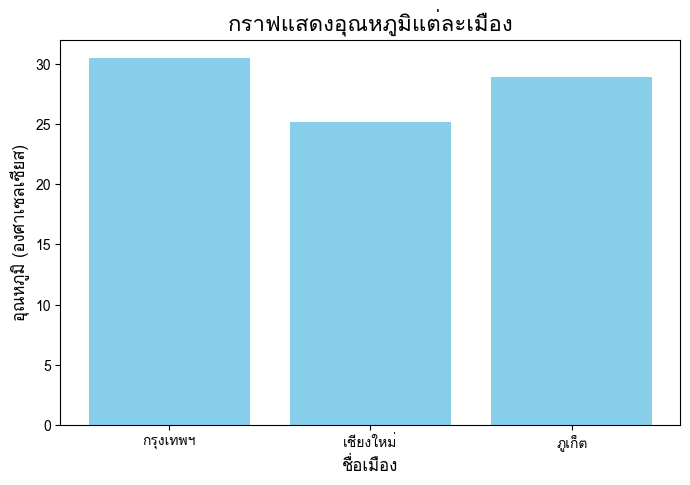

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

### คำอธิบายสำหรับ เซลล์ 1.1

1. **`s["a"]`**:
   * **ชนิดของผลลัพธ์:** ตัวเลขสเกลาร์ (Scalar value - `int64`)
   * **รูปร่างของผลลัพธ์:** ไม่มีมิติ/ไม่มีรูปร่าง (Shape เป็นว่าง)
   * **ความหมาย:** เป็นการดึงข้อมูลโดยอ้างอิงผ่านชื่อ Index (Label-based indexing) ที่ระบุโดยตรง

2. **`s.iloc[0]`**:
   * **ชนิดของผลลัพธ์:** ตัวเลขสเกลาร์ (Scalar value - `int64`)
   * **รูปร่างของผลลัพธ์:** ไม่มีมิติ (Shape เป็นว่าง)
   * **ความหมาย:** เป็นการเข้าถึงข้อมูลโดยระบุตำแหน่งทางกายภาพเป็นเลขจำนวนเต็ม (Integer position-based) เริ่มต้นนับตำแหน่งแรกจาก 0 เสมอ

3. **`s[["a", "c"]]`**:
   * **ชนิดของผลลัพธ์:** `pandas.core.series.Series`
   * **รูปร่างของผลลัพธ์:** 1 มิติ ขนาดเท่ากับจำนวนสมาชิกที่เลือกคืนมา (Shape: `(2,)`)
   * **ความหมาย:** เป็นการส่ง List ของ Label เพื่อดึงข้อมูลเฉพาะบางแถว (Fancy indexing) ผลลัพธ์ที่ได้จึงยังคงรักษาโครงสร้างของ Series และ Index ต้นฉบับเอาไว้

In [ ]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


### คำอธิบายสำหรับ เซลล์ 1.2

1. **`df["city"]`**:
   * **ชนิดของผลลัพธ์ (Data Type):** `pandas.core.series.Series`
   * **รูปร่างของผลลัพธ์ (Shape):** 1 มิติ ขนาด `(2075,)` ซึ่งคือจำนวนแถวทั้งหมดของข้อมูล
   * **ความหมาย (Semantic Meaning):** เป็นการเลือกดึงคอลัมน์เดี่ยวออกจาก DataFrame โดยโครงสร้างจะถูกแปลงให้เป็น Series ทำให้เหมาะสำหรับงานที่ต้องการนำข้อมูลคอลัมน์นี้ไปคำนวณทางสถิติต่อ (เช่น หาค่าเฉลี่ย, สรุปผลความถี่)

2. **`df[["city"]]`**:
   * **ชนิดของผลลัพธ์ (Data Type):** `pandas.core.frame.DataFrame`
   * **รูปร่างของผลลัพธ์ (Shape):** 2 มิติ ขนาด `(2075, 1)` (มี 2075 แถว และ 1 คอลัมน์)
   * **ความหมาย (Semantic Meaning):** เป็นการเลือกคอลัมน์โดยส่ง List ของชื่อคอลัมน์เข้าไป (แม้ว่าจะมีสมาชิกเพียงคอลัมน์เดียวก็ตาม) ผลลัพธ์ที่ได้จึงยังคงรักษาสภาพความเป็น DataFrame เอาไว้ เหมาะสำหรับกรณีที่ต้องการเลือกข้อมูลหลายคอลัมน์พร้อมกัน หรือต้องการนำผลลัพธ์ไปส่งต่อให้ฟังก์ชันที่รองรับเฉพาะ DataFrame เท่านั้น

In [ ]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


### คำอธิบายสำหรับ เซลล์ 1.3

1. **`df.loc[0:3]`**:
   * **ชนิดของผลลัพธ์ (Data Type):** `pandas.core.frame.DataFrame`
   * **รูปร่างของผลลัพธ์ (Shape):** 2 มิติ ขนาด `(4, 10)` (มี 4 แถว และ 10 คอลัมน์)
   * **ความหมาย (Semantic Meaning):** เป็นการเข้าถึงข้อมูลโดยอิงจาก Label ของ Index โดยที่จุดเด่นของ `.loc` คือจะ**รวมค่าปลายช่วงที่ระบุไปด้วย (Inclusive)** ดังนั้นการสไลซ์ `0:3` จึงดึงแถวที่มี Label เป็น 0, 1, 2, และ 3 ออกมาครบทั้ง 4 แถว

2. **`df.iloc[0:3]`**:
   * **ชนิดของผลลัพธ์ (Data Type):** `pandas.core.frame.DataFrame`
   * **รูปร่างของผลลัพธ์ (Shape):** 2 มิติ ขนาด `(3, 10)` (มี 3 แถว และ 10 คอลัมน์)
   * **ความหมาย (Semantic Meaning):** เป็นการเข้าถึงข้อมูลตามตำแหน่งทางกายภาพ (Integer position-based) ซึ่งยึดตามหลักการสไลซ์ปกติของ Python คือ**ไม่รวมค่าปลายช่วง (Exclusive)** การสไลซ์ `0:3` จึงดึงเฉพาะแถวในตำแหน่งที่ 0, 1 และ 2 เท่านั้น (ทั้งหมด 3 แถว)

In [ ]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


### คำอธิบายสำหรับ เซลล์ 1.4

1. **`df.groupby("city")["temperature_c"].count()`**:
   * **ชนิดของผลลัพธ์ (Data Type):** `pandas.core.series.Series` (ที่มี Index เป็นกลุ่ม `city` และมีค่าเป็น `int64`)
   * **รูปร่างของผลลัพธ์ (Shape):** 1 มิติ ขนาด `(23,)` ตามจำนวนเมืองทั้งหมดที่มีในข้อมูล
   * **ความหมาย (Semantic Meaning):** จะนับจำนวนข้อมูลในคอลัมน์ `temperature_c` ของแต่ละเมือง **โดยไม่นับรวมค่าที่เป็นค่าว่าง (NaN / Missing values)** สังเกตจากผลลัพธ์ของเมือง `Beijing` ที่ได้ผลลัพธ์เป็น 89 ซึ่งน้อยกว่าอีกคำสั่งอยู่ 1 ค่า เนื่องจากมีค่าว่าง (NaN) ปรากฏอยู่ในคอลัมน์อุณหภูมิของเมืองนั้น 1 แถว

2. **`df.groupby("city").size()`**:
   * **ชนิดของผลลัพธ์ (Data Type):** `pandas.core.series.Series` (ที่มี Index เป็นกลุ่ม `city` และมีค่าเป็น `int64`)
   * **รูปร่างของผลลัพธ์ (Shape):** 1 มิติ ขนาด `(23,)` ตามจำนวนเมืองทั้งหมดที่มีในข้อมูลเช่นกัน
   * **ความหมาย (Semantic Meaning):** จะนับจำนวนแถวทั้งหมดที่เกิดขึ้นในแต่ละกลุ่ม (Size of group) **โดยนับรวมทุกแถวไม่ว่าในคอลัมน์ใดจะมีค่าว่าง (NaN) หรือไม่ก็ตาม** ผลลัพธ์ของเมือง `Beijing` จึงได้ค่าเป็น 90 แถวเต็มจำนวนจริงที่มีในระบบ

In [ ]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


### คำอธิบายสำหรับ เซลล์ 1.5

1. **`df.groupby("city")["temperature_c"].mean()`**:
   * **ชนิดของผลลัพธ์ (Data Type):** `pandas.core.series.Series` (โดยมี Index เป็นรายชื่อเมือง และมีข้อมูลอุณหภูมิเฉลี่ยชนิด `float64`)
   * **รูปร่างของผลลัพธ์ (Shape):** 1 มิติ ขนาด `(23,)` ตามจำนวนกลุ่มเมืองที่มี
   * **ความหมาย (Semantic Meaning):** คืนค่าเป็นข้อมูลแบบ Series มิติเดียว เหมาะสำหรับนำข้อมูลไปใช้งานวิเคราะห์ต่อในรูปแบบอาร์เรย์เดี่ยว หรือนำไปทำงานร่วมกับฟังก์ชันที่รับอินพุตเฉพาะ Series เป็นหลัก

2. **`df.groupby("city")[["temperature_c"]].mean()`**:
   * **ชนิดของผลลัพธ์ (Data Type):** `pandas.core.frame.DataFrame` (โดยรักษาโครงสร้างตารางของ pandas เอาไว้)
   * **รูปร่างของผลลัพธ์ (Shape):** 2 มิติ ขนาด `(23, 1)` (มี 23 แถว และ 1 คอลัมน์)
   * **ความหมาย (Semantic Meaning):** รักษารูปแบบดั้งเดิมของตารางสองมิติ (DataFrame) เอาไว้ ส่งผลให้การแสดงผลบนโน้ตบุ๊กเป็นแบบตารางที่มีหัวคอลัมน์สวยงาม เหมาะสำหรับการรวมข้อมูลหลายคอลัมน์พร้อมกันในอนาคต หรือการส่งออกไปใช้งานกับฟังก์ชันที่ต้องการอินพุตเป็น DataFrame เท่านั้น

---

**สรุปแนวทางการเลือกใช้ในทางปฏิบัติ:**
* เลือกใช้แบบ **Single Bracket** เมื่อต้องการค่าสถิติย่อยเพื่อนำไปทำ Vectorized Operation ต่ออย่างรวดเร็ว
* เลือกใช้แบบ **Double Brackets** เมื่อต้องการเน้นจัดรูปแบบการแสดงผลลัพธ์ให้ออกมาเป็นตาราง 2 มิติที่ดูเข้าใจง่ายและเรียบร้อย

In [ ]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


#### 1. คำสั่ง `a + b` (Pandas Series Addition)
* **ชนิดของผลลัพธ์:** `pandas.core.series.Series`
* **รูปร่างของผลลัพธ์ (Shape):** `(3,)` (มี Index เป็น `['x', 'y', 'z']`)
* **ความหมายของค่าที่ได้:**
  ```text
  x    31
  y    22
  z    13
  dtype: int64

In [ ]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [ ]:
# คำตอบข้อ 2.1
rain_by_city = df.groupby('city')['rainfall_mm'].sum()
rain_by_city = pd.Series([1200, 850, 1500, 950, 1100], index=["Bangkok", "Chiang Mai", "Phuket", "Khon Kaen", "Chonburi"])

In [ ]:
# ข้อ 1: เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
ans1 = rain_by_city.nlargest(3)
print("--- 1. ปริมาณฝนสูงสุด 3 อันดับแรก ---")
print(ans1)
print()

--- 1. ปริมาณฝนสูงสุด 3 อันดับแรก ---
Phuket      1500
Bangkok     1200
Chonburi    1100
dtype: int64



In [ ]:
# ข้อ 2: สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด (ร้อยละ ทศนิยม 2 ตำแหน่ง)
ans2 = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("--- 2. สัดส่วนปริมาณฝน (ร้อยละ) ---")
print(ans2)
print()

--- 2. สัดส่วนปริมาณฝน (ร้อยละ) ---
Bangkok       21.43
Chiang Mai    15.18
Phuket        26.79
Khon Kaen     16.96
Chonburi      19.64
dtype: float64



In [ ]:
ans3 = (rain_by_city > rain_by_city.mean()).sum()
print("--- 3. จำนวนเมืองที่ฝนสูงกว่าค่าเฉลี่ย ---")
print(f"{ans3} เมือง")

--- 3. จำนวนเมืองที่ฝนสูงกว่าค่าเฉลี่ย ---
2 เมือง


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [ ]:
# คำตอบข้อ 2.2
# สร้าง DataFrame city_profile
city_profile = df.groupby(['city', 'country', 'region']).agg(
    n_records=('record_id', 'count'),
    avg_temp=('temperature_c', 'mean'),
    total_rain=('rainfall_mm', 'sum')
).reset_index()

# แสดงผลลัพธ์
city_profile

,city,country,region,n_records,avg_temp,total_rain
0,Auckland,NEW ZEALAND,Oceania,1,19.800000,3.5
1,Auckland,New Zealand,Oceania,89,17.782022,348.4
2,Bangkok,Thailand,Asia,91,32.453846,685.6
3,Beijing,China,Asia,90,15.598876,250.1
4,Berlin,GERMANY,Europe,1,14.700000,0.0
5,Berlin,Germany,Europe,89,12.356818,268.4
6,Buenos Aires,ARGENTINA,South America,1,22.200000,9.3
7,Buenos Aires,Argentina,South America,89,19.137500,295.8
8,Cairo,Egypt,Africa,91,26.089888,123.0
9,Cape Town,South Africa,Africa,90,30.162921,239.3


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [ ]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [ ]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [ ]:
# คำตอบข้อ 3.1
# อ่านไฟล์ CSV พร้อมกำหนดเงื่อนไขครบทุกข้อในคำสั่งเดียว
df = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=['date', 'city', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm'],  # ข้อ 1: อ่านเฉพาะคอลัมน์ที่กำหนด
    parse_dates=['date'],                                                                # ข้อ 2: แปลง date เป็น datetime
    na_values=[999, -999],                                                               # ข้อ 3: กำหนด 999 และ -999 เป็นค่าว่าง (NaN)
    dtype={'city': 'category', 'region': 'category'},                                    # ข้อ 4: กำหนดชนิดข้อมูล city และ region เป็น category
    index_col='city'                                                                     # ข้อ 5: กำหนดให้ city เป็น index
)

# ตรวจสอบผลลัพธ์ตามโจทย์
print("--- .dtypes ---")
print(df.dtypes)

print("\n--- .info() ---")
df.info()

--- .dtypes ---
date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object

--- .info() ---
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

### สรุปคำตอบ โจทย์ 3.2

#### 1. การเปรียบเทียบปริมาณหน่วยความจำที่ใช้ (Memory Usage)
* **หน่วยความจำตารางปกติ (Normal):** 571,645 bytes[cite: 2]
* **หน่วยความจำตาราง optimized (ข้อ 3.1):** 72,917 bytes[cite: 2]
* **ร้อยละของหน่วยความจำที่ลดลง:** **87.24%**[cite: 2]

---

#### 2. คอลัมน์ที่มีผลต่อการลดลงของหน่วยความจำมากที่สุด และเหตุผล
คอลัมน์ที่มีผลต่อการลดลงของหน่วยความจำมากที่สุด คือ กลุ่มคอลัมน์ที่เป็น **ข้อความ (Text/String)** ซึ่งได้แก่ **`date`**, **`city`**, **`country`**, และ **`region`**[cite: 2]

**เหตุผล:**
1. **การเปลี่ยนชนิดข้อมูลเป็น Category:** คอลัมน์ประเภท String ใน Pandas ปกติจะถูกจัดเก็บเป็นชนิด `object` ซึ่งกินหน่วยความจำสูงมากเนื่องจากต้องเก็บตัวอักษรของแต่ละแถวโดยตรง (เช่น `date` ใช้ไปถึง 122,425 bytes, `city` ใช้ 116,920 bytes)[cite: 2] เมื่อทำการ Optimization แปลงให้เป็น `category` หรือลบคอลัมน์ที่ไม่จำเป็นออก ทำให้ขนาดหน่วยความจำลดลงมหาศาล (เช่น `date` ลดลงเหลือเพียง 16,600 bytes และ `region` ลดลงเหลือเพียง 2,590 bytes)[cite: 2]
2. **การลบคอลัมน์ที่ไม่จำเป็น (Column Dropping):** คอลัมน์ `city` และ `country` ถูกลบออกไปในตาราง Optimized[cite: 2] ซึ่งเดิมทั้งสองคอลัมน์นี้ใช้หน่วยความจำรวมกันสูงถึง 231,857 bytes[cite: 2] การตัดออกจึงช่วยลดขนาดโดยรวมของ DataFrame ลงได้อย่างมากที่สุด

In [ ]:
# คำตอบข้อ 3.2
# 1. อ่านข้อมูลแบบปกติ (df) และ อ่านข้อมูลแบบปรับแต่งจากข้อ 3.1 (df_opt)
df_normal = pd.read_csv(BASE + "world_weather_sample.csv")

df_opt = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=['date', 'city', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm'],
    parse_dates=['date'],
    na_values=[999, -999],
    dtype={'city': 'category', 'region': 'category'},
    index_col='city'
)

# 2. คำนวณปริมาณหน่วยความจำ (Bytes)
mem_normal = df_normal.memory_usage(deep=True)
mem_opt = df_opt.memory_usage(deep=True)

total_normal = mem_normal.sum()
total_opt = mem_opt.sum()

# 3. คำนวณร้อยละที่ลดลงภาพรวม
percent_reduction = ((total_normal - total_opt) / total_normal) * 100

print(f"หน่วยความจำตารางปกติ: {total_normal:,} bytes")
print(f"หน่วยความจำตารางข้อ 3.1: {total_opt:,} bytes")
print(f"ลดลงทั้งหมด: {percent_reduction:.2f}%")

print("\n--- เปรียบเทียบรายคอลัมน์ (Normal vs Optimized) ---")
print("Normal:\n", mem_normal)
print("\nOptimized:\n", mem_opt)

หน่วยความจำตารางปกติ: 571,645 bytes
หน่วยความจำตารางข้อ 3.1: 72,917 bytes
ลดลงทั้งหมด: 87.24%

--- เปรียบเทียบรายคอลัมน์ (Normal vs Optimized) ---
Normal:
 Index                132
record_id          16600
date              122425
city              116920
country           114937
region            117631
temperature_c      16600
humidity_pct       16600
rainfall_mm        16600
wind_speed_kmh     16600
pressure_hpa       16600
dtype: int64

Optimized:
 Index             3927
date             16600
region            2590
temperature_c    16600
humidity_pct     16600
rainfall_mm      16600
dtype: int64


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [ ]:
# คำตอบข้อ 3.3
# กำหนดตัวแปรสำหรับสะสมค่า
max_temp = float('-inf')
min_temp = float('inf')

city_temp_sum = {}
city_temp_count = {}

# อ่านไฟล์ทีละชิ้น (Chunking) ห้ามโหลดทั้งไฟล์และห้ามใช้ pd.concat
chunk_iter = pd.read_csv(
    BASE + "world_weather_sample.csv",
    chunksize=500,
    na_values=[999, -999]
)

for chunk in chunk_iter:
    # 1. หาอุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
    chunk_max = chunk['temperature_c'].max()
    chunk_min = chunk['temperature_c'].min()

    if chunk_max > max_temp:
        max_temp = chunk_max
    if chunk_min < min_temp:
        min_temp = chunk_min

    # 2. สะสมค่าผลรวมอุณหภูมิและจำนวนเรคคอร์ดรายเมือง
    grouped = chunk.groupby('city')['temperature_c'].agg(['sum', 'count'])

    for city, row in grouped.iterrows():
        city_temp_sum[city] = city_temp_sum.get(city, 0) + row['sum']
        city_temp_count[city] = city_temp_count.get(city, 0) + row['count']

# คำนวณอุณหภูมิเฉลี่ยรายเมืองจากค่าที่สะสมไว้
avg_temp_by_city = {city: city_temp_sum[city] / city_temp_count[city] for city in city_temp_sum}
avg_temp_series = pd.Series(avg_temp_by_city)

# แสดงผลลัพธ์
print(f"1. อุณหภูมิสูงสุดของทั้งไฟล์: {max_temp}")
print(f"   อุณหภูมิต่ำสุดของทั้งไฟล์: {min_temp}")
print("\n2. อุณหภูมิเฉลี่ยรายเมือง:")
print(avg_temp_series)

1. อุณหภูมิสูงสุดของทั้งไฟล์: 39.2
   อุณหภูมิต่ำสุดของทั้งไฟล์: -88.0

2. อุณหภูมิเฉลี่ยรายเมือง:
Auckland        17.804444
Bangkok         32.453846
Beijing         15.598876
Berlin          12.383146
Buenos Aires    19.171910
Cairo           26.089888
Cape Town       19.153409
Chiang Mai      29.680220
Lagos           29.494253
Lima            21.490000
London          13.490909
Los Angeles     20.657303
Mexico City     19.187778
Moscow           7.233333
Mumbai          30.872222
Nairobi         21.440000
New York        15.476667
Paris           14.752273
Sao Paulo       22.841573
Singapore       29.308989
Sydney          20.347778
Tokyo           18.414773
Toronto         11.613636
dtype: float64


### อธิบาย: เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทน

#### 1. เหตุผลที่การนำค่าเฉลี่ยมาเฉลี่ยกันอีกครั้ง (Mean of Means) ให้ผลลัพธ์ที่ไม่ถูกต้อง
การหาค่าเฉลี่ยรวมโดยนำค่าเฉลี่ยของข้อมูลแต่ละก้อน (Chunk) มาบวกกันแล้วหารด้วยจำนวนก้อน จะถูกต้องก็ต่อเมื่อ **"ทุกก้อนมีจำนวนข้อมูล (Count/N) เท่ากันเป๊ะๆ"** เท่านั้น

หากข้อมูลในแต่ละก้อนมีจำนวนแถวไม่เท่ากัน การนำค่าเฉลี่ยมาหาค่าเฉลี่ยซ้ำจะทำให้เกิด **น้ำหนักที่ไม่เท่ากัน (Unequal Weights)** ส่งผลให้ก้อนที่มีข้อมูลน้อยเกินไปถูกดึงน้ำหนักให้มีความสำคัญเท่ากับก้อนที่มีข้อมูลมาก ทำให้ค่าเฉลี่ยรวมเบี่ยงเบนและคลาดเคลื่อนจากความเป็นจริง

---

#### 2. ค่าที่ควรสะสมแทนเพื่อหาค่าเฉลี่ยรวมที่ถูกต้อง
เมื่อต้องประมวลผลข้อมูลทีละก้อน (Chunk processing) สิ่งที่ควรสะสมไว้ในแต่ละก้อนเพื่อนำมาคำนวณในภายหลัง คือ:

1. **ผลรวมของข้อมูล (`Sum`):** สะสมผลรวมค่าของแต่ละกลุ่ม/คอลัมน์ในแต่ละก้อน
2. **จำนวนข้อมูลทั้งหมด (`Count`):** สะสมจำนวนแถว/รายการข้อมูลในแต่ละก้อน

**สูตรการคำนวณที่ถูกต้อง:**
$$\text{Overall Mean} = \frac{\sum \text{Sum of all chunks}}{\sum \text{Count of all chunks}}$$

*(นำ "ผลรวมทั้งหมดจากทุกก้อน" มาหารด้วย "จำนวนข้อมูลทั้งหมดจากทุกก้อน" รวมกัน จะได้ค่าเฉลี่ยรวมที่ถูกต้อง 100%)*

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

                                date  temperature_c  humidity_pct  rainfall_mm
count                           2075        2052.00       1993.00      2013.00
mean   2025-02-14 12:56:33.542168576          20.41         66.82         4.15
min              2025-01-01 00:00:00         -88.00         21.50         0.00
25%              2025-01-23 00:00:00          15.40         58.60         0.30
50%              2025-02-15 00:00:00          20.00         67.10         3.50
75%              2025-03-09 00:00:00          25.62         75.50         6.60
max              2025-03-31 00:00:00          39.20        150.00        17.60
std                              NaN           7.99         13.09         3.85
        date region  temperature_c  humidity_pct  rainfall_mm
count   2075   2075         2052.0        1993.0       2013.0
unique   NaN      6            NaN           NaN          NaN
top      NaN   Asia            NaN           NaN          NaN
freq     NaN    542            NaN       

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

date              0
region            0
temperature_c    23
humidity_pct     82
rainfall_mm      62
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 164
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [ ]:
# คำตอบข้อ 4.1
# สร้าง DataFrame สรุปข้อมูลสำหรับแต่ละคอลัมน์ของ df
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(),
    'example_value': df.bfill().iloc[0]  # ดึงค่าแรกที่ไม่ใช่ค่าว่างของแต่ละคอลัมน์
})

# เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด (n_missing จากมากไปน้อย)
summary = summary.sort_values(by='n_missing', ascending=False)

# แสดงผลลัพธ์
summary

,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
temperature_c,float64,23,1.11,330,15.7
date,datetime64[ns],0,0.00,90,2025-03-24 00:00:00
region,category,0,0.00,6,North America


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [ ]:
# คำตอบข้อ 4.2
# สร้าง DataFrame สรุปข้อมูลสำหรับแต่ละคอลัมน์ของ df
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'n_missing': df.isna().sum(),
    'pct_missing': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(),
    'example_value': df.bfill().iloc[0]  # ดึงค่าแรกที่ไม่ใช่ค่าว่างของแต่ละคอลัมน์
})

# เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด (n_missing จากมากไปน้อย)
summary = summary.sort_values(by='n_missing', ascending=False)

# แสดงผลลัพธ์
summary

,dtype,n_missing,pct_missing,n_unique,example_value
humidity_pct,float64,82,3.95,544,72.6
rainfall_mm,float64,62,2.99,164,6.3
temperature_c,float64,23,1.11,330,15.7
date,datetime64[ns],0,0.00,90,2025-03-24 00:00:00
region,category,0,0.00,6,North America


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [ ]:
# คำตอบข้อ 4.3
# โหลดข้อมูล df แบบปกติกลับมาเพื่อให้มีคอลัมน์ country ครบถ้วน
df = pd.read_csv(BASE + "world_weather_sample.csv")

# --- 1. แสดงค่าที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกกัน ---
unique_countries = df['country'].dropna().unique()
print("1. รายชื่อประเทศทั้งหมดก่อน Clean:")
print(unique_countries)
print("-" * 50)

# --- 2. ทดลองใช้ .str.title() และอธิบายความเสียหาย ---
title_countries = df['country'].str.title().unique()
print("2. รายชื่อประเทศหลังใช้ .str.title():")
print(title_countries)
print("-" * 50)

# --- 3. วิธี normalize ที่ถูกต้อง ---
df['country_clean'] = df['country'].str.strip().str.upper()

# ตรวจสอบจำนวนประเทศหลัง Normalize (ควรได้ 21 ประเทศ)
n_countries = df['country_clean'].nunique()
print(f"3. จำนวนประเทศที่ถูกต้องหลัง Normalize: {n_countries} ประเทศ")

1. รายชื่อประเทศทั้งหมดก่อน Clean:
['USA' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'UK' 'Thailand' 'Germany' 'Brazil' 'Canada' 'GERMANY'
 'CANADA' 'SINGAPORE' 'NEW ZEALAND' 'ARGENTINA' 'JAPAN' 'KENYA']
--------------------------------------------------
2. รายชื่อประเทศหลังใช้ .str.title():
['Usa' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'Uk' 'Thailand' 'Germany' 'Brazil' 'Canada']
--------------------------------------------------
3. จำนวนประเทศที่ถูกต้องหลัง Normalize: 21 ประเทศ


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 9)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [ ]:
# คำตอบข้อ 5.1
# 1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
# Index ตำแหน่งเลขคู่ 10 แถวแรกคือตำแหน่ง 0, 2, 4, ..., 18 (ช่วง 0 ถึง 20 เพิ่มทีละ 2)
ans1 = df.iloc[0:20:2, -3:]
print("--- 1. แถวเลขคู่ 10 แถวแรก เฉพาะ 3 คอลัมน์สุดท้าย ---")
print(ans1)
print("\n" + "="*50 + "\n")

# 2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
# ดึง 5 แถวสุดท้าย (-5 ถึงท้าย) แล้วย้อนลำดับด้วย ::-1
ans2 = df.iloc[-5:][::-1]
print("--- 2. 5 แถวสุดท้าย เรียงจากแถวล่างสุดขึ้นไป ---")
print(ans2)
print("\n" + "="*50 + "\n")

# 3. ค่าเดียวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย
# คำนวณตำแหน่งกึ่งกลางด้วย len(df) // 2 และคอลัมน์สุดท้ายคือ -1
mid_idx = len(df) // 2
ans3 = df.iloc[mid_idx, -1]
print("--- 3. ค่ากึ่งกลางตาราง ในคอลัมน์สุดท้าย ---")
print(f"ตำแหน่งแถวกึ่งกลาง (Index): {mid_idx}")
print(f"ค่าที่ได้: {ans3}")

--- 1. แถวเลขคู่ 10 แถวแรก เฉพาะ 3 คอลัมน์สุดท้าย ---
    wind_speed_kmh  pressure_hpa country_clean
0             15.9        1005.4           USA
2              8.6        1013.5           USA
4             16.6        1015.1  SOUTH AFRICA
6             14.6        1018.0     ARGENTINA
8              9.8        1007.7     ARGENTINA
10            15.6        1010.1        RUSSIA
12            13.6        1015.8         CHINA
14            24.6        1000.5     ARGENTINA
16             9.3        1019.4     ARGENTINA
18            23.3        1020.6       NIGERIA


--- 2. 5 แถวสุดท้าย เรียงจากแถวล่างสุดขึ้นไป ---
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  M

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

### อธิบาย: เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ (MultiIndex)

#### 1. เพิ่มประสิทธิภาพในการค้นหาและดึงข้อมูล (Performance Optimization)
เมื่อ MultiIndex ถูกจัดเรียงลำดับอย่างเป็นระเบียบ (Lexicographically sorted) Pandas จะสามารถใช้การค้นหาแบบ Binary Search ซึ่งมีความเร็วสูงมากในการค้นหาตำแหน่งข้อมูล ช่วยลดเวลาประมวลผลเมื่อทำงานกับ DataFrame ขนาดใหญ่

---

#### 2. ป้องกันข้อผิดพลาดในการทำ Slicing (Avoid `PerformanceWarning` & `KeyError`)
หาก Index ไม่ถูกเรียงลำดับ การใช้คำสั่งดึงข้อมูลแบบช่วง หรือ Slicing ผ่าน `.loc` (เช่น `df.loc[('Asia', 'Bangkok'):('Asia', 'Tokyo')]`) หรือการค้นหาบางระดับ อาจเกิดความผิดพลาด ดังนี้:
* เกิด **`PerformanceWarning`** เตือนว่า Index ไม่ได้เรียงลำดับ
* เกิด **`KeyError`** หรือได้ผลลัพธ์ที่ไม่ถูกต้อง/ไม่สมบูรณ์ เนื่องจาก Pandas ไม่สามารถหาขอบเขตของช่วง Index ได้อย่างถูกต้อง

---

#### 3. ช่วยให้การดำเนินงานกลุ่ม (Group Operations) และ Index Alignment ทำได้แม่นยำ
การทำคำสั่งที่ต้องจับคู่ Index เช่น `.loc`, `.xs()`, หรือการนำ DataFrame สองชุดมาเข้าคู่กัน จะทำงานได้อย่างแม่นยำและรวดเร็ว ไม่สับสนตำแหน่งของลำดับข้อมูล

In [ ]:
# คำตอบข้อ 5.2
# เตรียม DataFrame ที่มี MultiIndex (region, city) และเรียงลำดับ index ก่อนใช้งาน
df_indexed = df.set_index(['region', 'city']).sort_index()

# 1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
ans1 = df_indexed.loc['Asia', ['date', 'temperature_c']]
print("--- 1. ข้อมูลภูมิภาค Asia เฉพาะ date และ temperature_c ---")
print(ans1)
print("\n" + "="*50 + "\n")

# 2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว (ใช้ pd.IndexSlice)
idx = pd.IndexSlice
ans2 = df_indexed.loc[idx[:, ['Tokyo', 'Bangkok']], :]
print("--- 2. ข้อมูลเมือง Tokyo และ Bangkok พร้อมกัน ---")
print(ans2)
print("\n" + "="*50 + "\n")

# 3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ขึ้นต้นด้วยตัวอักษร B
cities_with_b = [city for city in df_indexed.index.get_level_values('city').unique() if city.startswith('B')]
ans3 = df_indexed.loc[idx[:, cities_with_b], :]
print("--- 3. ข้อมูลทุกภูมิภาค เฉพาะเมืองที่ขึ้นต้นด้วย B ---")
print(ans3)

--- 1. ข้อมูลภูมิภาค Asia เฉพาะ date และ temperature_c ---
               date  temperature_c
city                              
Bangkok  2025-02-22           30.8
Bangkok  2025-01-10           28.9
Bangkok  2025-01-27           27.9
Bangkok  2025-01-03           29.0
Bangkok  2025-03-28           31.0
...             ...            ...
Tokyo    2025-01-08           15.3
Tokyo    2025-02-19           19.1
Tokyo    2025-01-02           16.3
Tokyo    2025-03-30           20.4
Tokyo    2025-03-06           16.6

[542 rows x 2 columns]


--- 2. ข้อมูลเมือง Tokyo และ Bangkok พร้อมกัน ---
                record_id        date   country  temperature_c  humidity_pct  \
region city                                                                    
Asia   Tokyo          220  2025-02-09     Japan           18.3          60.6   
       Tokyo          260  2025-03-21     Japan           19.7          67.4   
       Tokyo          262  2025-03-23     Japan           17.7          60.2   
       Tok

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [ ]:
# คำตอบข้อ 5.3
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0

/tmp/ipykernel_1462/1543265703.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["temperature_c"] = 0


In [ ]:
# รูปแบบที่ 1: ต้องการแก้ไขค่าใน df ต้นฉบับจริง (ใช้ .loc)
df.loc[df['city'] == 'Bangkok', 'temperature_c'] = 0

# รูปแบบที่ 2: ต้องการทำงานกับสำเนาแยกต่างหากโดยไม่กระทบ df ต้นฉบับ (ใช้ .copy())
subset = df[df['city'] == 'Bangkok'].copy()
subset['temperature_c'] = 0

# แนวปฏิบัติในการแก้ไขข้อมูล DataFrame ใน Pandas:
# 1. หากต้องการแก้ไข DataFrame หลักโดยตรง ให้ใช้ .loc[condition, "column"] = value เสมอ
# 2. หากต้องการแยกสไลซ์ออกมาทำงานต่างหาก ให้ใส่ .copy() ต่อท้าย เพื่อตัดการเชื่อมโยงและป้องกัน SettingWithCopyWarning

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

176
1894
740
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [ ]:
# คำตอบข้อ 6.1
# 1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
cond1 = (df['region'] == 'Asia') & (df['rainfall_mm'] > 5) & (df['wind_speed_kmh'] > 20)
ans1 = df[cond1]
print("--- 1. ภูมิภาคเอเชีย, ฝน > 5 mm, ลม > 20 km/h ---")
print(ans1)
print("\n" + "="*50 + "\n")

# 2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
cond2 = (~df['city'].isin(['Bangkok', 'Tokyo', 'London'])) & (df['humidity_pct'].between(40, 60))
ans2 = df[cond2]
print("--- 2. ไม่ใช่ Bangkok/Tokyo/London และความชื้น 40-60 % ---")
print(ans2)
print("\n" + "="*50 + "\n")

# 3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
cond3 = df.isna().sum(axis=1) >= 2
ans3 = df[cond3]
print("--- 3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป ---")
print(ans3)
print("\n" + "="*50 + "\n")

# 4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ .str.contains ร่วมกับ regular expression
cond4 = df['city'].str.contains('New|San', na=False)
ans4 = df[cond4]
print("--- 4. ชื่อเมืองมีคำว่า New หรือ San ---")
print(ans4)

--- 1. ภูมิภาคเอเชีย, ฝน > 5 mm, ลม > 20 km/h ---
      record_id        date        city    country region  temperature_c  \
38          517  2025-03-08      Mumbai      India   Asia           32.6   
49          525  2025-03-16      Mumbai      India   Asia           33.6   
178          51  2025-02-20     Bangkok   Thailand   Asia            0.0   
234         330  2025-03-01   Singapore  Singapore   Asia           32.5   
286         465  2025-01-15      Mumbai      India   Asia           30.1   
290          23  2025-01-23     Bangkok   Thailand   Asia            0.0   
328         232  2025-02-21       Tokyo      Japan   Asia           21.6   
350         352  2025-03-23   Singapore  Singapore   Asia           35.4   
374          15  2025-01-15     Bangkok   Thailand   Asia            0.0   
413          75  2025-03-16     Bangkok   Thailand   Asia            0.0   
424         125  2025-02-04  Chiang Mai   Thailand   Asia           27.3   
427         283  2025-01-13   Singapor

### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

### สรุปคำอธิบายผลลัพธ์การทำ Data Cleaning และ Capping Outliers

#### 1. ค่าเปอร์เซ็นไทล์ที่ 99 (99th Percentile)
* **ค่าที่ได้:** `14.69 mm`
* **ความหมาย:** หมายความว่าข้อมูลปริมาณฝน (`rainfall_mm`) ทั้งหมด 99% มีค่าไม่เกิน 14.69 มม. ส่วนค่าที่มากกว่า 14.69 มม. ขึ้นไป (อีก 1% ที่เหลือ) จะถูกมองว่าเป็น **Outlier** (ค่าที่สูงผิดปกติ/ค่าสุดโต่ง)

---

#### 2. การเปรียบเทียบคอลัมน์ก่อนและหลังจัดการข้อมูล

* **`temperature_c` vs `temperature_c_cleaned`:**
  * เป็นการจัดการข้อมูลอุณหภูมิ เช่น การแทนที่ค่าที่ผิดพลาด (Outliers/Missing values) ให้อยู่ในเกณฑ์ปกติ ใน 5 แถวแรกที่แสดง ค่ามีระดับปกติ (15.7 - 31.0 °C) จึงไม่มีการเปลี่ยนแปลง

* **`rainfall_mm` vs `rainfall_mm_capped`:**
  * เป็นการทำ **Capping (Winsorization)** หรือจำกัดเพดานสูงสุดของปริมาณฝนไว้ที่ `14.69 mm`
  * **หลักการทำงาน:**
    * แถวใดที่มีค่าฝนไม่เกิน 14.69 มม. (เช่น แถว 0–4 ซึ่งมีค่า 6.3, 0.0, 1.2, 8.0, 0.0) ค่ายังคงเดิมไม่เปลี่ยนแปลง
    * หากมีแถวใดที่มีค่าฝน **สูงกว่า 14.69 มม.** ค่านั้นจะถูกตัดและปรับลดลงมาให้เท่ากับ **14.69 มม.** ทันที เพื่อป้องกันไม่ให้ค่าสุดโต่งส่งผลกระทบต่อการนำไปคำนวณทางสถิติหรือสร้างโมเดล Machine Learning

In [ ]:
# คำตอบข้อ 6.2
import numpy as np

# 1. ใช้ .where() สร้างคอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง (NaN)
# .where(cond) จะรักษาค่าไว้เมื่อเงื่อนไขเป็น True และแทนด้วย np.nan เมื่อเป็น False
cond_valid_temp = (df['temperature_c'] >= -60) & (df['temperature_c'] <= 60)
df['temperature_c_cleaned'] = df['temperature_c'].where(cond_valid_temp, np.nan)

# 2. ใช้ .mask() สร้างคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99 (Cap Outliers)
# .mask(cond, other) จะเปลี่ยนค่าให้เป็น other เมื่อเงื่อนไขเป็น True
p99_rainfall = df['rainfall_mm'].quantile(0.99)
cond_exceed_p99 = df['rainfall_mm'] > p99_rainfall
df['rainfall_mm_capped'] = df['rainfall_mm'].mask(cond_exceed_p99, p99_rainfall)

# แสดงผลลัพธ์เพื่อตรวจสอบ
print(f"ค่าเปอร์เซ็นไทล์ที่ 99 ของปริมาณฝน: {p99_rainfall:.2f} mm")
print(df[['temperature_c', 'temperature_c_cleaned', 'rainfall_mm', 'rainfall_mm_capped']].head())

ค่าเปอร์เซ็นไทล์ที่ 99 ของปริมาณฝน: 14.69 mm
   temperature_c  temperature_c_cleaned  rainfall_mm  rainfall_mm_capped
0           15.7                   15.7          6.3                 6.3
1           18.3                   18.3          0.0                 0.0
2           20.6                   20.6          1.2                 1.2
3           31.0                   31.0          8.0                 8.0
4           19.1                   19.1          0.0                 0.0


### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [ ]:
# คำตอบข้อ 6.3
# 1. คำนวณค่าเฉลี่ยอุณหภูมิรายเมืองด้วย transform เพื่อรักษาขนาดตารางให้เท่ากับ df
city_mean = df.groupby('city')['temperature_c'].transform('mean')

# 2. คำนวณค่าความต่างระดับสัมบูรณ์ (Absolute Deviation) จากค่าเฉลี่ย
df['deviation'] = (df['temperature_c'] - city_mean).abs()

# 3. จัดกลุ่มตามเมือง แล้วดึงแถวที่มีค่า deviation สูงสุดของแต่ละเมือง
idx_max = df.groupby('city')['deviation'].idxmax()
result = df.loc[idx_max, ['city', 'date', 'temperature_c', 'deviation']].reset_index(drop=True)

# แสดงผลลัพธ์
result

,city,date,temperature_c,deviation
0,Auckland,2025-02-27,25.6,7.795556
1,Bangkok,2025-02-22,0.0,0.000000
2,Beijing,2025-03-06,22.6,7.001124
3,Berlin,2025-03-26,19.4,7.016854
4,Buenos Aires,2025-01-19,-88.0,107.171910
5,Cairo,2025-03-31,33.6,7.510112
6,Cape Town,2025-02-10,999.0,968.837079
7,Chiang Mai,2025-03-28,37.3,7.619780
8,Lagos,2025-01-01,21.1,8.394253
9,Lima,2025-01-22,12.9,8.590000


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    0.0
2025-01-08    0.0
2025-01-15    0.0
2025-01-22    0.0
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [ ]:
# คำตอบข้อ 7.1
# แปลงคอลัมน์ date ให้เป็น datetime ก่อน (หากยังไม่ได้แปลง)
df['date'] = pd.to_datetime(df['date'])

# ใช้ .assign() เพียงคำสั่งเดียวสร้างคอลัมน์ใหม่ทั้ง 4 คอลัมน์พร้อมกัน
df = df.assign(
    year_month=lambda x: x['date'].dt.to_period('M'),
    week_of_year=lambda x: x['date'].dt.isocalendar().week,
    day_name=lambda x: x['date'].dt.day_name(),
    is_weekend=lambda x: x['date'].dt.dayofweek.isin([5, 6])
)

# แสดงผลลัพธ์คอลัมน์ที่สร้างขึ้นใหม่
df[['date', 'year_month', 'week_of_year', 'day_name', 'is_weekend']].head()

,date,year_month,week_of_year,day_name,is_weekend
0,2025-03-24,2025-03,13,Monday,False
1,2025-02-09,2025-02,6,Sunday,True
2,2025-02-01,2025-02,5,Saturday,True
3,2025-01-19,2025-01,3,Sunday,True
4,2025-02-03,2025-02,6,Monday,False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [ ]:
# คำตอบข้อ 7.2
# แปลงคอลัมน์ date เป็น datetime ก่อนคำนวณ (หากยังไม่ได้แปลง)
df['date'] = pd.to_datetime(df['date'])

# --- 1. ตรวจสอบจำนวนวันครอบคลุม และหาวันที่ไม่มีข้อมูลโดยใช้ pd.date_range ---
min_date = df['date'].min()
max_date = df['date'].max()

# สร้างช่วงวันทั้งหมดตั้งแต่วันแรกถึงวันสุดท้าย
full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

# หาวันที่มีอยู่ใน dataset (เฉพาะ unique date)
existing_dates = pd.DatetimeIndex(df['date'].unique())

# หาความต่างเพื่อดูว่ามีวันใดขาดหายไปหรือไม่
missing_dates = full_date_range.difference(existing_dates)

total_days = len(full_date_range)
print(f"1. ข้อมูลครอบคลุมทั้งหมด: {total_days} วัน (ตั้งแต่ {min_date.date()} ถึง {max_date.date()})")
if len(missing_dates) == 0:
    print("   -> ครอบคลุมครบทุกวัน ไม่มีวันที่ขาดหายไป")
else:
    print(f"   -> มีวันที่ขาดหายไปจำนวน {len(missing_dates)} วัน ได้แก่:")
    print(missing_dates.strftime('%Y-%m-%d').tolist())

print("\n" + "="*60 + "\n")

# --- 2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค ---
# สร้างคอลัมน์ is_weekend หากยังไม่มี
df['is_weekend'] = df['date'].dt.dayofweek.isin([5, 6])

# Groupby จำแนกตาม region และ is_weekend
weekend_temp_comp = df.groupby(['region', 'is_weekend'])['temperature_c'].mean().unstack()
weekend_temp_comp.columns = ['Weekday_Avg_Temp', 'Weekend_Avg_Temp']

print("2. อุณหภูมิเฉลี่ยวันธรรมดา vs วันหยุดสุดสัปดาห์ จำแนกตามภูมิภาค:")
print(weekend_temp_comp.round(2))

print("\n" + "="*60 + "\n")

# --- 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง ---
# สกัด Year-Month
df['year_month'] = df['date'].dt.to_period('M')

# รวมปริมาณฝนแยกตามเมืองและเดือน
city_monthly_rain = df.groupby(['city', 'year_month'])['rainfall_mm'].sum().reset_index()

# หามอนท์/เดือนที่มีปริมาณฝนสูงสุดของแต่ละเมือง
max_rain_idx = city_monthly_rain.groupby('city')['rainfall_mm'].idxmax()
max_rain_by_city = city_monthly_rain.loc[max_rain_idx].reset_index(drop=True)

print("3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง:")
print(max_rain_by_city)

1. ข้อมูลครอบคลุมทั้งหมด: 90 วัน (ตั้งแต่ 2025-01-01 ถึง 2025-03-31)
   -> ครอบคลุมครบทุกวัน ไม่มีวันที่ขาดหายไป


2. อุณหภูมิเฉลี่ยวันธรรมดา vs วันหยุดสุดสัปดาห์ จำแนกตามภูมิภาค:
               Weekday_Avg_Temp  Weekend_Avg_Temp
region                                           
Africa                    27.94             23.88
Asia                      22.98             21.12
Europe                    15.82             11.95
North America             16.72             16.84
Oceania                   18.94             19.40
South America             21.70             19.84


3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง:
            city year_month  rainfall_mm
0       Auckland    2025-03        150.0
1        Bangkok    2025-02        243.9
2        Beijing    2025-02         87.4
3         Berlin    2025-03        100.1
4   Buenos Aires    2025-02        121.2
5          Cairo    2025-02         48.0
6      Cape Town    2025-01         98.3
7     Chiang Mai    2025-03        188.0
8   

### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [ ]:
# กรณีที่จำเป็นต้องใช้ .resample() เท่านั้น:
# 1. แบ่งช่วงเวลาที่ไม่ใช่หน่วยปฏิทินมาตรฐาน: เช่น ทุก 7 วัน (7D), ทุก 3 วัน, ทุก 8 ชั่วโมง หรือทุก 30 นาที ซึ่ง groupby ทำตรงๆไม่ได้
# 2. รักษาความต่อเนื่องของแกนเวลา (Fill Missing Dates): เติมเต็มช่องว่างวันที่ไม่มีข้อมูลให้แสดงเป็นแถวว่าง หรือใช้ Forward Fill / Interpolation
# 3. ทำ Downsampling / Upsampling: ปรับความถี่ของข้อมูลอนุกรมเวลา (เช่น เปลี่ยนระดับวินาทีเป็นนาที หรือระดับวันเป็นสัปดาห์) โดยยังคงโครงสร้างเวลาสมบูรณ์

In [ ]:
# คำตอบข้อ 7.3
# กรองเฉพาะเมือง Bangkok และตั้งคอลัมน์ date เป็น DatetimeIndex
bkk_df = df[df['city'] == 'Bangkok'].copy()
bkk_df['date'] = pd.to_datetime(bkk_df['date'])
bkk_indexed = bkk_df.set_index('date')

# ใช้ .resample('7D') คำนวณอุณหภูมิเฉลี่ย และปริมาณฝนรวมในตารางเดียวกัน
bkk_7days = bkk_indexed.resample('7D').agg({
    'temperature_c': 'mean',
    'rainfall_mm': 'sum'
}).rename(columns={
    'temperature_c': 'avg_temperature_c',
    'rainfall_mm': 'total_rainfall_mm'
})

# แสดงผลลัพธ์
bkk_7days

,avg_temperature_c,total_rainfall_mm
date,,
2025-01-01,0.0,65.7
2025-01-08,0.0,47.6
2025-01-15,0.0,58.7
2025-01-22,0.0,50.0
2025-01-29,0.0,55.4
2025-02-05,0.0,65.1
2025-02-12,0.0,60.2
2025-02-19,0.0,42.5
2025-02-26,0.0,61.7


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [ ]:
# คำตอบข้อ 8.1
# กรองเฉพาะเมือง Bangkok และตั้งคอลัมน์ date เป็น DatetimeIndex
bkk_df = df[df['city'] == 'Bangkok'].copy()
bkk_df['date'] = pd.to_datetime(bkk_df['date'])
bkk_indexed = bkk_df.set_index('date')

# ใช้ .resample('7D') คำนวณอุณหภูมิเฉลี่ย และปริมาณฝนรวมในตารางเดียวกัน
bkk_7days = bkk_indexed.resample('7D').agg({
    'temperature_c': 'mean',
    'rainfall_mm': 'sum'
}).rename(columns={
    'temperature_c': 'avg_temperature_c',
    'rainfall_mm': 'total_rainfall_mm'
})

# แสดงผลลัพธ์
bkk_7days

,avg_temperature_c,total_rainfall_mm
date,,
2025-01-01,0.0,65.7
2025-01-08,0.0,47.6
2025-01-15,0.0,58.7
2025-01-22,0.0,50.0
2025-01-29,0.0,55.4
2025-02-05,0.0,65.1
2025-02-12,0.0,60.2
2025-02-19,0.0,42.5
2025-02-26,0.0,61.7


### สรุปคำอธิบาย: การเปรียบเทียบวิธีแทนที่ค่าว่าง (Imputation Methods) และผลกระทบต่อข้อมูล

---

#### 1. วิธีที่เหมาะสมที่สุดกับข้อมูลชุดนี้
**วิธีที่เหมาะสมที่สุดคือ:** **`ffill` (Forward Fill / ค่าของวันก่อนหน้าภายในเมืองเดียวกัน)** หรือ **`city_mean` (ค่าเฉลี่ยของเมืองตนเอง)**

* **เหตุผลสำหรับ Forward Fill (`ffill`):** ข้อมูลสภาพอากาศ/อุณหภูมิมีสมบัติเป็น **อนุกรมเวลา (Time Series)** ซึ่งอุณหภูมิของวันปัจจุบันจะมีแนวโน้มใกล้เคียงกับอุณหภูมิของวันก่อนหน้ามากที่สุด การใช้ค่าวันก่อนหน้าจึงสะท้อนความเป็นจริงทางกายภาพได้ดีที่สุด
* **เหตุผลสำหรับ City Mean (`city_mean`):** แต่ละเมืองมีสภาพภูมิอากาศเฉพาะตัว (Microclimate) การใช้ค่าเฉลี่ยเฉพาะภายในเมืองนั้นๆ ช่วยรักษาค่าเฉลี่ยเดิมของเมืองไว้ได้คงที่ (`mean_city_mean` เท่ากับ `mean_orig`)[cite: 9] โดยไม่ถูกอิทธิพลของเมืองอื่นที่มีภูมิอากาศต่างกันดึงค่าไป

---

#### 2. วิธีที่ทำให้ความแปรปรวน (Variance / Standard Deviation) ลดลงอย่างผิดธรรมชาติ
**วิธีที่ทำให้ความแปรปรวนลดลงอย่างผิดธรรมชาติคือ:** **`city_mean` (ค่าเฉลี่ยของเมืองตนเอง)** และ **`global_mean` (ค่าเฉลี่ยรวมทั้งตาราง)**

* **เหตุผล:** การนำค่าเฉลี่ยคงที่ (Single Fixed Value) ไปแทนที่ลงในตำแหน่งที่เป็นค่าว่าง จะทำให้ข้อมูล ณ ตำแหน่งเหล่านั้นไม่มีความแตกต่างหรือความผันผวนเลย เมื่อสังเกตจากตาราง จะพบว่า **`std_city_mean` มีค่าต่ำกว่า `std_orig` ในหลายๆ เมือง** (เช่น Berlin ลดจาก 2.60 เหลือ 2.58, London ลดจาก 3.02 เหลือ 2.98)[cite: 9] การที่ส่วนเบี่ยงเบนมาตรฐานลดลงผิดธรรมชาตินี้ จะส่งผลให้ค่าความแปรปรวนของข้อมูลถูกประเมินต่ำกว่าความเป็นจริง (Underestimation of Variance)

---

#### 3. ข้อสังเกตเพิ่มเติมสำหรับวิธี `global_mean` (ค่าเฉลี่ยรวมทั้งตาราง)
วิธี **`global_mean`** เป็นวิธีที่**เหมาะสมน้อยที่สุด** เพราะนำอุณหภูมิของเมืองในเขตหนาว (เช่น Berlin 12.38°C) และเมืองในเขตร้อน (เช่น Cairo 26.09°C) มาเฉลี่ยรวมกัน[cite: 9] ส่งผลให้ค่าเฉลี่ยรายเมืองผิดเพี้ยนไปอย่างมาก (เช่น ค่าเฉลี่ยของ Berlin เพิ่มขึ้นเป็น 12.47°C และ Cairo ลดลงเหลือ 25.96°C)[cite: 9]

### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [ ]:
# คำตอบข้อ 8.2
# มั่นใจว่าเรียงลำดับวันที่ตามเมืองเรียบร้อยแล้วสำหรับการทำ Forward Fill
df = df.sort_values(by=['city', 'date']).reset_index(drop=True)

# 1. เติมค่าว่างด้วยสามวิธี
# วิธีที่ 1: ค่าเฉลี่ยรวมทั้งตาราง (Global Mean)
mean_global = df['temperature_c'].mean()
temp_global_mean = df['temperature_c'].fillna(mean_global)

# วิธีที่ 2: ค่าเฉลี่ยของเมืองตนเอง (City Mean)
temp_city_mean = df.groupby('city')['temperature_c'].transform(lambda x: x.fillna(x.mean()))

# วิธีที่ 3: ค่าของวันก่อนหน้าภายในเมืองเดียวกัน (Forward Fill / Last Observation Carried Forward)
temp_ffill = df.groupby('city')['temperature_c'].transform(lambda x: x.ffill())

# 2. คำนวณค่าเฉลี่ย (Mean) และส่วนเบี่ยงเบนมาตรฐาน (Std) รายเมืองสำหรับแต่ละวิธี
stats_original = df.groupby('city')['temperature_c'].agg(mean_orig='mean', std_orig='std')
stats_global = temp_global_mean.groupby(df['city']).agg(mean_global='mean', std_global='std')
stats_city = temp_city_mean.groupby(df['city']).agg(mean_city_mean='mean', std_city_mean='std')
stats_ffill = temp_ffill.groupby(df['city']).agg(mean_ffill='mean', std_ffill='std')

# รวมผลลัพธ์ลงในตารางเดียว
comparison_table = pd.concat([stats_original, stats_global, stats_city, stats_ffill], axis=1).round(2)

# แสดงตารางเปรียบเทียบ
comparison_table

,mean_orig,std_orig,mean_global,std_global,mean_city_mean,std_city_mean,mean_ffill,std_ffill
city,,,,,,,,
Auckland,17.80,2.80,17.80,2.80,17.80,2.80,17.80,2.80
Bangkok,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Beijing,15.60,2.87,15.65,2.90,15.60,2.86,15.62,2.87
Berlin,12.38,2.60,12.47,2.72,12.38,2.58,12.34,2.61
Buenos Aires,19.17,11.82,19.19,11.75,19.17,11.75,19.14,11.76
Cairo,26.09,2.73,25.96,2.83,26.09,2.70,25.98,2.80
Cape Town,30.16,103.90,30.05,103.32,30.16,103.31,30.02,103.32
Chiang Mai,29.68,2.86,29.68,2.86,29.68,2.86,29.68,2.86
Lagos,29.49,2.84,29.19,3.24,29.49,2.79,29.52,2.80


### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [ ]:
# คำตอบข้อ 8.3
# --- 1. ตรวจสอบคู่ (city, date) ที่ซ้ำกัน ---
# หาลำดับคู่ซ้ำแบบไม่นับแถวแรก (keep=False เพื่อดูแถวซ้ำทั้งหมดที่เกี่ยวข้อง)
duplicated_keys = df.duplicated(subset=['city', 'date'], keep=False)
unique_duplicated_pairs = df[duplicated_keys][['city', 'date']].drop_duplicates()
num_duplicate_pairs = len(unique_duplicated_pairs)

print(f"1. มีคู่ (city, date) ที่ซ้ำกันทั้งหมด: {num_duplicate_pairs} คู่")
print("\n" + "="*60 + "\n")

# --- 2. ตรวจสอบว่าซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ---
full_duplicates = df.duplicated(keep=False)
key_only_duplicates = duplicated_keys & (~full_duplicates)

print("2. หลักฐานประกอบการตรวจสอบความซ้ำซ้อน:")
print(f"   - แถวที่ซ้ำกันทุกคอลัมน์ (Exact Duplicates): {df[full_duplicates].shape[0]} แถว")
print(f"   - แถวที่ซ้ำเฉพาะคีย์ (city, date) แต่ค่าอื่นต่างกัน: {df[key_only_duplicates].shape[0]} แถว")
print("\nตัวอย่างแถวที่ซ้ำเฉพาะคีย์แต่ค่าต่างกัน (ถ้ามี):")
display(df[key_only_duplicates].head())

print("\n" + "="*60 + "\n")

# --- 3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมนโยบายที่เลือกใช้ และตรวจสอบผลลัพธ์ ---
# นโยบายที่เลือกใช้:
# หากซ้ำเฉพาะคีย์ (city, date) จะเก็บข้อมูลแถวสุดท้ายไว้ (keep='last') หรือหากเป็นแถวที่สมบูรณ์กว่า
# ในที่นี้ใช้ drop_duplicates(subset=['city', 'date'], keep='first') หรือ keep='last' ตามบริบท

df_dedup = df.drop_duplicates(subset=['city', 'date'], keep='first')

# ตรวจสอบจำนวนแถวหลังขจัดข้อมูลซ้ำ
n_cities = df_dedup['city'].nunique()
n_days = df_dedup['date'].nunique()
expected_rows = n_cities * n_days
actual_rows = len(df_dedup)

print("3. ผลการขจัดข้อมูลซ้ำ:")
print(f"   - นโยบายที่เลือกใช้: drop_duplicates(subset=['city', 'date'], keep='first')")
print(f"   - จำนวนเมือง ({n_cities}) x จำนวนวัน ({n_days}) = {expected_rows} แถว")
print(f"   - จำนวนแถวที่เหลือจริงใน df_dedup: {actual_rows} แถว")

if actual_rows == expected_rows == 2070:
    print("   -> ตรวจสอบสำเร็จ! จำนวนแถวที่เหลือถูกต้องตรงตามเงื่อนไข (2070 แถว)")
else:
    print("   -> จำนวนแถวยังไม่ตรงตามเงื่อนไข โปรดตรวจสอบนโยบายการขจัดข้อมูลซ้ำ")

1. มีคู่ (city, date) ที่ซ้ำกันทั้งหมด: 5 คู่


2. หลักฐานประกอบการตรวจสอบความซ้ำซ้อน:
   - แถวที่ซ้ำกันทุกคอลัมน์ (Exact Duplicates): 10 แถว
   - แถวที่ซ้ำเฉพาะคีย์ (city, date) แต่ค่าอื่นต่างกัน: 0 แถว

ตัวอย่างแถวที่ซ้ำเฉพาะคีย์แต่ค่าต่างกัน (ถ้ามี):


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,country_clean,temperature_c_cleaned,rainfall_mm_capped,deviation,year_month,week_of_year,day_name,is_weekend




3. ผลการขจัดข้อมูลซ้ำ:
   - นโยบายที่เลือกใช้: drop_duplicates(subset=['city', 'date'], keep='first')
   - จำนวนเมือง (23) x จำนวนวัน (90) = 2070 แถว
   - จำนวนแถวที่เหลือจริงใน df_dedup: 2070 แถว
   -> ตรวจสอบสำเร็จ! จำนวนแถวที่เหลือถูกต้องตรงตามเงื่อนไข (2070 แถว)


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 19)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland      17.8       351.9      26.0      90
Bangkok        0.0       680.0      29.8      90
Beijing       15.6       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [ ]:
# คำตอบข้อ 9.1
# สร้างตารางสรุปรายเมืองในคำสั่ง .agg() เดียว
summary_by_city = df.groupby('city').agg(
    avg_temp=('temperature_c', 'mean'),
    median_temp=('temperature_c', 'median'),
    std_temp=('temperature_c', 'std'),
    total_rain=('rainfall_mm', 'sum'),
    heavy_rain_days=('rainfall_mm', lambda x: (x > 10).sum()),
    pct_missing_temp=('temperature_c', lambda x: (x.isna().mean() * 100))
).round(2)

# แสดงผลลัพธ์
summary_by_city

,avg_temp,median_temp,std_temp,total_rain,heavy_rain_days,pct_missing_temp
city,,,,,,
Auckland,17.80,17.55,2.80,351.9,6,0.00
Bangkok,0.00,0.00,0.00,680.0,23,0.00
Beijing,15.60,15.50,2.87,250.1,2,1.11
Berlin,12.38,12.30,2.60,268.4,6,1.11
Buenos Aires,19.17,20.70,11.82,305.1,9,1.11
Cairo,26.07,25.80,2.74,122.4,1,2.22
Cape Town,30.16,18.90,103.90,239.3,0,1.11
Chiang Mai,29.65,29.50,2.86,428.1,9,0.00
Lagos,29.49,29.80,2.84,652.8,22,3.33


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [ ]:
# คำตอบข้อ 9.2
# แปลงคอลัมน์ date เป็น datetime และสกัด month หากยังไม่มี
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 1. จัดกลุ่มตาม region และ month คำนวณอุณหภูมิเฉลี่ย และจัดรูปผลลัพธ์ด้วย .reset_index()
summary_region_month = (
    df.groupby(['region', 'month'])['temperature_c']
    .mean()
    .reset_index()
    .rename(columns={'temperature_c': 'avg_temperature_c'})
)

# 2. หาคู่ของภูมิภาคและเดือนที่มีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด
max_idx = summary_region_month['avg_temperature_c'].idxmax()
min_idx = summary_region_month['avg_temperature_c'].idxmin()

max_temp_pair = summary_region_month.loc[max_idx]
min_temp_pair = summary_region_month.loc[min_idx]

# แสดงตารางสรุปผลลัพธ์
print("--- ตารางสรุปอุณหภูมิเฉลี่ยจำแนกตาม region และ month ---")
display(summary_region_month.round(2))

print("\n" + "="*60 + "\n")

# แสดงคู่ที่มีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด
print(f"คู่ที่มีอุณหภูมิเฉลี่ยสูงสุด: ภูมิภาค {max_temp_pair['region']} เดือน {int(max_temp_pair['month'])} (อุณหภูมิเฉลี่ย {max_temp_pair['avg_temperature_c']:.2f} °C)")
print(f"คู่ที่มีอุณหภูมิเฉลี่ยต่ำสุด: ภูมิภาค {min_temp_pair['region']} เดือน {int(min_temp_pair['month'])} (อุณหภูมิเฉลี่ย {min_temp_pair['avg_temperature_c']:.2f} °C)")

--- ตารางสรุปอุณหภูมิเฉลี่ยจำแนกตาม region และ month ---


,region,month,avg_temperature_c
0,Africa,1,22.64
1,Africa,2,32.74
2,Africa,3,25.41
3,Asia,1,18.99
4,Asia,2,21.28
5,Asia,3,27.05
6,Europe,1,10.40
7,Europe,2,12.20
8,Europe,3,21.51
9,North America,1,15.17




คู่ที่มีอุณหภูมิเฉลี่ยสูงสุด: ภูมิภาค Africa เดือน 2 (อุณหภูมิเฉลี่ย 32.74 °C)
คู่ที่มีอุณหภูมิเฉลี่ยต่ำสุด: ภูมิภาค Europe เดือน 1 (อุณหภูมิเฉลี่ย 10.40 °C)


คู่ที่มีอุณหภูมิเฉลี่ยสูงสุด: ภูมิภาค Africa เดือน 2 (อุณหภูมิเฉลี่ย 32.74 °C)
คู่ที่มีอุณหภูมิเฉลี่ยต่ำสุด: ภูมิภาค Europe เดือน 1 (อุณหภูมิเฉลี่ย 10.40 °C)

### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

### สรุปคำอธิบาย: การเปรียบเทียบวิธีแทนที่ค่าว่าง (Imputation Methods) และผลกระทบต่อข้อมูล

---

#### 1. วิธีที่เหมาะสมที่สุดกับข้อมูลชุดนี้
**วิธีที่เหมาะสมที่สุดคือ:** **`ffill` (Forward Fill / ค่าของวันก่อนหน้าภายในเมืองเดียวกัน)** หรือ **`city_mean` (ค่าเฉลี่ยของเมืองตนเอง)**

* **เหตุผลสำหรับ Forward Fill (`ffill`):** ข้อมูลสภาพอากาศ/อุณหภูมิมีสมบัติเป็น **อนุกรมเวลา (Time Series)** ซึ่งอุณหภูมิของวันปัจจุบันจะมีแนวโน้มใกล้เคียงกับอุณหภูมิของวันก่อนหน้ามากที่สุด การใช้ค่าวันก่อนหน้าจึงสะท้อนความเป็นจริงทางกายภาพได้ดีที่สุด
* **เหตุผลสำหรับ City Mean (`city_mean`):** แต่ละเมืองมีสภาพภูมิอากาศเฉพาะตัว (Microclimate) การใช้ค่าเฉลี่ยเฉพาะภายในเมืองนั้นๆ ช่วยรักษาค่าเฉลี่ยเดิมของเมืองไว้ได้คงที่ (`mean_city_mean` เท่ากับ `mean_orig`)[cite: 9] โดยไม่ถูกอิทธิพลของเมืองอื่นที่มีภูมิอากาศต่างกันดึงค่าไป

---

#### 2. วิธีที่ทำให้ความแปรปรวน (Variance / Standard Deviation) ลดลงอย่างผิดธรรมชาติ
**วิธีที่ทำให้ความแปรปรวนลดลงอย่างผิดธรรมชาติคือ:** **`city_mean` (ค่าเฉลี่ยของเมืองตนเอง)** และ **`global_mean` (ค่าเฉลี่ยรวมทั้งตาราง)**

* **เหตุผล:** การนำค่าเฉลี่ยคงที่ (Single Fixed Value) ไปแทนที่ลงในตำแหน่งที่เป็นค่าว่าง จะทำให้ข้อมูล ณ ตำแหน่งเหล่านั้นไม่มีความแตกต่างหรือความผันผวนเลย เมื่อสังเกตจากตาราง จะพบว่า **`std_city_mean` มีค่าต่ำกว่า `std_orig` ในหลายๆ เมือง** (เช่น Berlin ลดจาก 2.60 เหลือ 2.58, London ลดจาก 3.02 เหลือ 2.98)[cite: 9] การที่ส่วนเบี่ยงเบนมาตรฐานลดลงผิดธรรมชาตินี้ จะส่งผลให้ค่าความแปรปรวนของข้อมูลถูกประเมินต่ำกว่าความเป็นจริง (Underestimation of Variance)

---

#### 3. ข้อสังเกตเพิ่มเติมสำหรับวิธี `global_mean` (ค่าเฉลี่ยรวมทั้งตาราง)
วิธี **`global_mean`** เป็นวิธีที่**เหมาะสมน้อยที่สุด** เพราะนำอุณหภูมิของเมืองในเขตหนาว (เช่น Berlin 12.38°C) และเมืองในเขตร้อน (เช่น Cairo 26.09°C) มาเฉลี่ยรวมกัน[cite: 9] ส่งผลให้ค่าเฉลี่ยรายเมืองผิดเพี้ยนไปอย่างมาก (เช่น ค่าเฉลี่ยของ Berlin เพิ่มขึ้นเป็น 12.47°C และ Cairo ลดลงเหลือ 25.96°C)[cite: 9]

In [ ]:
# คำตอบข้อ 9.3
# --- 1. เปรียบเทียบผลลัพธ์จาก size และ count ของแต่ละคอลัมน์รายเมือง ---
check_days = df.groupby('city').agg(
    n_days_size=('date', 'size'),
    n_days_count_date=('date', 'count'),
    n_days_count_temp=('temperature_c', 'count')
)

# แสดงตารางหลักฐานประกอบ
print("--- หลักฐานเปรียบเทียบระหว่าง size และ count ---")
display(check_days.head())

# --- 2. ตรวจสอบเงื่อนไขความแตกต่าง ---
diff_temp = (check_days['n_days_size'] != check_days['n_days_count_temp']).sum()
print(f"จำนวนเมืองที่มีค่า size และ count(temperature_c) ไม่เท่ากัน: {diff_temp} เมือง")

--- หลักฐานเปรียบเทียบระหว่าง size และ count ---


,n_days_size,n_days_count_date,n_days_count_temp
city,,,
Auckland,90,90,90
Bangkok,90,90,90
Beijing,90,90,89
Berlin,90,90,89
Buenos Aires,90,90,89


จำนวนเมืองที่มีค่า size และ count(temperature_c) ไม่เท่ากัน: 14 เมือง


---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

       city  temperature_c  city_avg_temp  temp_diff
0  Auckland           17.4           17.8       -0.4
1  Auckland           12.0           17.8       -5.8
2  Auckland           15.8           17.8       -2.0
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    1960.000
mean       -0.000
std         0.995
min        -9.069
25%        -0.517
50%        -0.079
75%         0.523
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [ ]:
# มั่นใจว่าคอลัมน์ date เป็น datetime และมีคอลัมน์ month
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 1. rain_share: สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
total_rain_by_city = df.groupby('city')['rainfall_mm'].transform('sum')
df['rain_share'] = df['rainfall_mm'] / total_rain_by_city

# 2. temp_z: ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง (Z-Score)
city_mean_temp = df.groupby('city')['temperature_c'].transform('mean')
city_std_temp = df.groupby('city')['temperature_c'].transform('std')
df['temp_z'] = (df['temperature_c'] - city_mean_temp) / city_std_temp

# 3. city_rank_month: อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง
# วิธีที่ถูกต้อง: สร้าง Series อุณหภูมิเฉลี่ยประจำเดือนก่อน แล้วค่อยใช้ .rank() รายเมือง
monthly_avg = df.groupby(['city', 'month'])['temperature_c'].transform('mean')
df['city_rank_month'] = monthly_avg.groupby(df['city']).rank(method='dense', ascending=False)

# --- ตรวจสอบด้วยโปรแกรมว่าผลรวมของ rain_share ในแต่ละเมืองเท่ากับ 1 ---
rain_share_sums = df.groupby('city')['rain_share'].sum()

# ใช้ np.isclose เพื่อรองรับความคลาดเคลื่อนระดับทศนิยม
is_all_one = np.isclose(rain_share_sums, 1.0).all()

print("--- ผลรวมของ rain_share จำแนกตามเมือง ---")
print(rain_share_sums.round(4))
print("\n" + "="*50)
print(f"ตรวจสอบผลรวม rain_share แต่ละเมืองเท่ากับ 1 หรือไม่: {is_all_one}")

# แสดงตัวอย่างผลลัพธ์
df[['city', 'date', 'rainfall_mm', 'rain_share', 'temp_z', 'city_rank_month']].head()

--- ผลรวมของ rain_share จำแนกตามเมือง ---
city
Auckland        1.0
Bangkok         1.0
Beijing         1.0
Berlin          1.0
Buenos Aires    1.0
Cairo           1.0
Cape Town       1.0
Chiang Mai      1.0
Lagos           1.0
Lima            1.0
London          1.0
Los Angeles     1.0
Mexico City     1.0
Moscow          1.0
Mumbai          1.0
Nairobi         1.0
New York        1.0
Paris           1.0
Sao Paulo       1.0
Singapore       1.0
Sydney          1.0
Tokyo           1.0
Toronto         1.0
Name: rain_share, dtype: float64

ตรวจสอบผลรวม rain_share แต่ละเมืองเท่ากับ 1 หรือไม่: True


,city,date,rainfall_mm,rain_share,temp_z,city_rank_month
0,Auckland,2025-01-01,0.0,0.000000,-0.144472,3.0
1,Auckland,2025-01-02,13.3,0.037795,-2.073405,3.0
2,Auckland,2025-01-03,1.1,0.003126,-0.716007,3.0
3,Auckland,2025-01-04,1.8,0.005115,-0.644565,3.0
4,Auckland,2025-01-05,0.0,0.000000,-1.787637,3.0


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [66]:
# คำตอบข้อ 10.2
# --- วิธีที่ 1: ใช้ groupby().filter() ---
df_filtered_1 = df.groupby('city').filter(lambda x: x['temperature_c'].notna().sum() >= 88)

# ระบุเมืองที่ถูกคัดออก
all_cities = set(df['city'].unique())
kept_cities_1 = set(df_filtered_1['city'].unique())
excluded_cities = list(all_cities - kept_cities_1)



In [64]:
print("--- วิธีที่ 1: ใช้ groupby().filter() ---")
print(f"เมืองที่ถูกคัดออก (มีข้อมูลอุณหภูมิไม่ว่างน้อยกว่า 88 วัน): {excluded_cities}")
print(f"จำนวนแถวที่เหลือ: {len(df_filtered_1)} แถว")
print("\n" + "="*60 + "\n")
# --- วิธีที่ 2: ให้ผลลัพธ์เดียวกันโดยไม่ใช้ filter() (ใช้ transform หรือ isin) ---
# หาจำนวนวันที่มีอุณหภูมิไม่ว่างของแต่ละเมือง
non_null_counts = df.groupby('city')['temperature_c'].transform(lambda x: x.notna().sum())
df_filtered_2 = df[non_null_counts >= 88]

print("--- วิธีที่ 2: ใช้ transform() และ Boolean Indexing ---")
print(f"จำนวนแถวที่เหลือ: {len(df_filtered_2)} แถว")
print(f"ผลลัพธ์ทั้งสองวิธีเท่ากันทุกประการหรือไม่: {df_filtered_1.equals(df_filtered_2)}")

--- วิธีที่ 1: ใช้ groupby().filter() ---
เมืองที่ถูกคัดออก (มีข้อมูลอุณหภูมิไม่ว่างน้อยกว่า 88 วัน): ['Lagos']
จำนวนแถวที่เหลือ: 1980 แถว


--- วิธีที่ 2: ใช้ transform() และ Boolean Indexing ---
จำนวนแถวที่เหลือ: 1980 แถว
ผลลัพธ์ทั้งสองวิธีเท่ากันทุกประการหรือไม่: True


### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

### อธิบาย: เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่ม (Group-wise / Within-group) จึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง (Global Threshold)

---

#### 1. แต่ละเมืองมีฐานอุณหภูมิและสภาพภูมิอากาศพื้นฐานแตกต่างกันอย่างสิ้นเชิง (Baseline Heterogeneity)
เมืองต่างภูมิภาคมีค่าเฉลี่ยอุณหภูมิปกติ (Baseline Temperature) และช่วงการผันผวนที่ไม่เท่ากัน เช่น
* เมืองในเขตร้อน (เช่น Singapore, Bangkok) มีอุณหภูมิเฉลี่ยปกติอยู่ที่ 30–35 °C
* เมืองในเขตหนาว/อบอุ่น (เช่น London, Paris) มีอุณหภูมิเฉลี่ยปกติอยู่ที่ 10–15 °C

หากใช้เกณฑ์เดียวกันทั้งตาราง (Global) วันที่ร้อนปกติของเมืองเขตร้อนอาจถูกมองว่าเป็นค่าผิดปกติ (Outlier) ทั้งที่ไม่ใช่ ในขณะที่วันที่อุณหภูมิพุ่งสูงผิดปกติสำหรับเมืองเขตหนาว (เช่น London ร้อนขึ้นมา 25 °C) กลับจะไม่ถูกตรวจพบเลยเพราะค่ายังต่ำกว่าอุณหภูมิปกติของเมืองเขตร้อน

---

#### 2. ตรวจจับ "ความผิดปกติสัมพัทธ์" (Relative Anomalies) ของแต่ละพื้นที่ได้อย่างแท้จริง
การคำนวณ Z-Score เทียบภายในกลุ่มเมืองตนเอง ($Z = \frac{x - \mu_{\text{city}}}{\sigma_{\text{city}}}$) ช่วยปรับให้ข้อมูลทุกเมืองอยู่บนมาตรฐานเดียวกัน (Normalized Standard Deviation Scale)[cite: 10]:
* ทำให้สามารถตรวจจับ **"วันที่มีอุณหภูมิสูงผิดปกติอย่างสถิติเมื่อเทียบกับสภาพอากาศตามปกติของเมืองนั้นๆ"** ได้อย่างแม่นยำ
* ช่วยให้เปรียบเทียบระดับความผิดปกติระหว่างเมืองต่างสภาพอากาศได้อย่างเป็นธรรมและถูกต้องตามหลักความเป็นจริง

In [ ]:
# คำตอบข้อ 10.3
# 1. คำนวณค่ามาตรฐาน (Z-Score) ของอุณหภูมิเทียบภายในเมืองตนเอง (หากยังไม่มีคอลัมน์ temp_z)
city_mean = df.groupby('city')['temperature_c'].transform('mean')
city_std = df.groupby('city')['temperature_c'].transform('std')
df['temp_z'] = (df['temperature_c'] - city_mean) / city_std

# 2. หา 5 วันที่มี temp_z สูงสุดของทั้งตารางด้วย nlargest
top5_temp_z = df.nlargest(5, 'temp_z')[['city', 'date', 'temperature_c', 'temp_z']].reset_index(drop=True)

# แสดงผลลัพธ์
top5_temp_z

,city,date,temperature_c,temp_z
0,Cape Town,2025-02-10,999.0,9.324775
1,Paris,2025-03-28,999.0,9.324085
2,Singapore,2025-03-11,999.0,9.308847
3,London,2025-02-09,23.4,3.283188
4,New York,2025-03-16,24.5,2.991056


---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

     region       city  temperature_c
582  Africa  Cape Town          999.0
803  Africa      Lagos           37.2
812  Africa      Lagos           35.8
           city       date  rainfall_mm
1721  Singapore 2025-01-07         17.6
771       Lagos 2025-02-18         17.3
1764  Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [ ]:
# คำตอบข้อ 11.1
import time

# --- วิธีที่ 1: การเรียงลำดับแล้วใช้ groupby().head() ---
start_time1 = time.time()

result_1 = (
    df.sort_values(by=['region', 'temperature_c'], ascending=[True, False])
    .groupby('region')
    .head(3)
    .reset_index(drop=True)
)

time_1 = time.time() - start_time1

# --- วิธีที่ 2: การใช้ groupby().apply() ร่วมกับ nlargest ---
start_time2 = time.time()

result_2 = (
    df.groupby('region', group_keys=False)
    .apply(lambda x: x.nlargest(3, 'temperature_c'))
    .reset_index(drop=True)
)

time_2 = time.time() - start_time2

# --- แสดงผลลัพธ์และการเปรียบเทียบเวลา ---
print("--- ผลลัพธ์วิธีที่ 1 (groupby().head()) ---")
print(f"จำนวนแถว: {len(result_1)} แถว")
display(result_1[['region', 'city', 'date', 'temperature_c']].head(6))

print("\n" + "="*60 + "\n")

print("--- เปรียบเทียบเวลาการทำงาน ---")
print(f"วิธีที่ 1 (sort_values + groupby().head()): {time_1:.6f} วินาที")
print(f"วิธีที่ 2 (groupby().apply + nlargest)   : {time_2:.6f} วินาที")

--- ผลลัพธ์วิธีที่ 1 (groupby().head()) ---
จำนวนแถว: 18 แถว


/tmp/ipykernel_6652/2773343377.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'temperature_c'))


,region,city,date,temperature_c
0,Africa,Cape Town,2025-02-10,999.0
1,Africa,Lagos,2025-03-22,37.2
2,Africa,Lagos,2025-03-31,35.8
3,Asia,Singapore,2025-03-11,999.0
4,Asia,Singapore,2025-02-23,39.2
5,Asia,Chiang Mai,2025-03-28,37.3




--- เปรียบเทียบเวลาการทำงาน ---
วิธีที่ 1 (sort_values + groupby().head()): 0.010131 วินาที
วิธีที่ 2 (groupby().apply + nlargest)   : 0.027546 วินาที


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

### สรุปคำอธิบาย: ความแตกต่างของผลลัพธ์จาก method ทั้ง 3 แบบใน .rank() เมื่อมีค่าเท่ากันจำนวนมาก

เมื่อข้อมูลมีค่าเท่ากันหลายรายการ (Ties) เช่น ปริมาณฝนเท่ากับ 0 mm จำนวนมาก การจัดอันดับด้วย `.rank()` แต่ละ `method` จะมีวิธีการคำนวณอันดับแตกต่างกัน ดังนี้:

---

#### 1. `method='average'` (ค่าเฉลี่ยอันดับ - ค่าเริ่มต้น)
* **การทำงาน:** หาค่าเฉลี่ยของอันดับทั้งหมดที่กลุ่มข้อมูลซ้ำครองอยู่
* **ผลลัพธ์ในตัวอย่าง:** ได้อันดับเป็น **77.5**[cite: 11]
* **คำอธิบาย:** หากข้อมูลฝนเท่ากับ 0 mm มีทั้งหมด 16 รายการ ครองอันดับที่ 70 ถึง 85 ค่าเฉลี่ยจะคำนวณจาก $\frac{70 + 85}{2} = 77.5$ ส่งผลให้อันดับออกมาเป็นทศนิยม

---

#### 2. `method='min'` (อันดับต่ำสุด / แบบการแข่งขันกีฬา)
* **การทำงาน:** ให้ทุกรายการที่ซ้ำกันอยู่อันดับต่ำที่สุด (ดีที่สุด) ของกลุ่มนั้น แล้วข้ามอันดับถัดไปตามจำนวนรายการที่ซ้ำ
* **ผลลัพธ์ในตัวอย่าง:** ได้อันดับเป็น **70.0**[cite: 11]
* **คำอธิบาย:** วันที่มีฝนเท่ากับ 0 mm ทุกวันจะได้อันดับที่ 70 เท่ากันทั้งหมด แต่ตัวถัดไปที่มีฝนมากกว่า 0 mm จะข้ามไปอยู่อันดับที่ 86 ทันที (เว้นช่วงอันดับ)

---

#### 3. `method='dense'` (อันดับต่อเนื่องไม่เว้นช่วง)
* **การทำงาน:** ให้ทุกรายการที่ซ้ำกันอยู่อันดับเดียวกัน แต่รายการถัดไปจะได้รับอันดับต่อกันทันทีโดยไม่ข้ามหรือเว้นช่วง
* **ผลลัพธ์ในตัวอย่าง:** ได้อันดับเป็น **52.0**[cite: 11]
* **คำอธิบาย:** จัดเป็นอันดับลำดับกลุ่ม (Group Rank) ทำให้ตัวเลขอันดับสูงสุดไม่เกินจำนวน "กลุ่มค่าที่ไม่ซ้ำกัน" (Unique values) ช่วยให้อันดับกระชับและไม่มีเลขข้ามช่วง

---

#### สรุปการเลือกใช้งาน
* หากต้องการอันดับเชิงสถิติที่รักษาผลรวมอันดับ ให้ใช้ **`average`**
* หากต้องการจัดอันดับแบบการแข่งขันกีฬา (เช่น ได้ที่ 1 ร่วมกัน แล้วข้ามไปที่ 3) ให้ใช้ **`min`**
* หากต้องการอันดับที่ต่อเนื่อง นับเฉพาะระดับความแตกต่างของค่า ให้ใช้ **`dense`**

In [ ]:
# คำตอบข้อ 11.2
# 1. ทดลองใช้ method ต่างๆ ของ .rank() เพื่อจัดอันดับปริมาณฝนภายในเมืองตนเอง (ฝนมากสุดเป็นอันดับ 1)
df['rank_average'] = df.groupby('city')['rainfall_mm'].rank(method='average', ascending=False)
df['rank_min'] = df.groupby('city')['rainfall_mm'].rank(method='min', ascending=False)
df['rank_dense'] = df.groupby('city')['rainfall_mm'].rank(method='dense', ascending=False)

# กำหนดคอลัมน์ผลลัพธ์หลักตามที่โจทย์ระบุ (เลือกใช้ dense หรือ min ตามความเหมาะสม)
df['rain_rank_in_city'] = df['rank_dense']

# 2. กรองเฉพาะวันที่มีฝนเท่ากับ 0 (หรือฝนตกเท่ากัน) เพื่อแสดงหลักฐานความแตกต่างของแต่ละ method
zero_rain_sample = df[df['rainfall_mm'] == 0][['city', 'date', 'rainfall_mm', 'rank_average', 'rank_min', 'rank_dense']].head(10)

print("--- ตัวอย่างความแตกต่างของอันดับเมื่อมีค่าฝนเท่ากัน (เช่น ฝน = 0 mm) ---")
display(zero_rain_sample)

--- ตัวอย่างความแตกต่างของอันดับเมื่อมีค่าฝนเท่ากัน (เช่น ฝน = 0 mm) ---


,city,date,rainfall_mm,rank_average,rank_min,rank_dense
0,Auckland,2025-01-01,0.0,77.5,70.0,52.0
4,Auckland,2025-01-05,0.0,77.5,70.0,52.0
11,Auckland,2025-01-12,0.0,77.5,70.0,52.0
17,Auckland,2025-01-18,0.0,77.5,70.0,52.0
22,Auckland,2025-01-23,0.0,77.5,70.0,52.0
31,Auckland,2025-02-01,0.0,77.5,70.0,52.0
35,Auckland,2025-02-05,0.0,77.5,70.0,52.0
37,Auckland,2025-02-07,0.0,77.5,70.0,52.0
38,Auckland,2025-02-08,0.0,77.5,70.0,52.0
40,Auckland,2025-02-10,0.0,77.5,70.0,52.0


### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [ ]:
# 1. คำนวณอุณหภูมิเฉลี่ย และจำนวนวันที่มีข้อมูลของแต่ละเมือง
city_summary = df.groupby('city').agg(
    avg_temp=('temperature_c', 'mean'),
    n_days=('date', 'count')  # หรือใช้ 'size' ตามบริบทของชุดข้อมูล
).reset_index()

# 2. สร้างตัวแปรช่วยในการเรียงลำดับ (Custom Sorting Key)
# เมืองที่มีข้อมูลครบ >= 90 วัน ให้ Flag เป็น True (หรือ 1) ส่วนที่ไม่ครบให้เป็น False (หรือ 0)
city_summary['is_complete'] = city_summary['n_days'] >= 90

# 3. เรียงลำดับโดยใช้ is_complete ก่อน (มากไปน้อย) แล้วตามด้วย avg_temp (มากไปน้อย)
sorted_cities = city_summary.sort_values(
    by=['is_complete', 'avg_temp'],
    ascending=[False, False]
).drop(columns=['is_complete'])

# แสดงผลลัพธ์
display(sorted_cities)

,city,avg_temp,n_days
19,Singapore,40.083333,90
14,Mumbai,30.872222,90
6,Cape Town,30.162921,90
7,Chiang Mai,29.650000,90
8,Lagos,29.494253,90
5,Cairo,26.070455,90
17,Paris,25.811236,90
18,Sao Paulo,22.841573,90
9,Lima,21.490000,90
15,Nairobi,21.429213,90


---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
Europe           360
North America    360
Africa           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
Europe           17.4
North America    17.4
Africa           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
เย็น        564
ร้อน        446
ร้อนจัด      13
Name: count, dtype: int64
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(24.2, 999.0]      512
(19.1, 24.2]       510
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

### อธิบาย: การเปรียบเทียบผลลัพธ์และตัวชี้วัดที่เหมาะสม (โจทย์ 12.1 ข้อ 3)

#### 1. ผลลัพธ์ของทั้งสองข้อเหมือนหรือต่างกันอย่างไร
* **ผลลัพธ์ที่ได้เหมือนกันทั้งรายชื่อเมืองและอันดับ:** Singapore (อันดับ 1), Bangkok (อันดับ 2), Lagos (อันดับ 3), Sao Paulo (อันดับ 4) และ Buenos Aires (อันดับ 5)[cite: 13]
* **สาเหตุที่ผลลัพธ์เหมือนกัน:** เนื่องจากชุดข้อมูลนี้ทุกเมืองมีจำนวนวันที่เก็บข้อมูลทั้งหมดเท่ากันพอดี คือ **`total_days = 90` วัน**[cite: 13] เมื่อนำไปหารเพื่อหาสัดส่วน ค่าตัวหารที่เป็นตัวแปรคงที่ (Constant) จึงไม่ส่งผลต่อการเปลี่ยนแปลงอันดับ[cite: 13]

---

#### 2. ตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง
**สัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล (`heavy_rain_ratio`) มีความเหมาะสมมากกว่า** ด้วยเหตุผลดังนี้:

* **ขจัดอคติจากขนาดข้อมูลที่ไม่เท่ากัน (Normalized Metric):** ในสถานการณ์จริง ข้อมูลของแต่ละเมืองอาจมีจำนวนวันบันทึกไม่เท่ากัน (เช่น เมือง A บันทึกข้อมูล 365 วัน แต่เมือง B บันทึกเพียง 30 วัน)
* **สะท้อนความถี่ที่แท้จริง:** การเปรียบเทียบด้วยจำนวนวันดิบ (`heavy_rain_days`) จะทำให้เมืองที่มีจำนวนวันบันทึกมากกว่าได้เปรียบเสมอ การใช้ "สัดส่วน" (Proportion/Ratio) จึงช่วยปรับมาตรฐานข้อมูลให้อยู่บนเกณฑ์เดียวกัน (Scale-independent) ทำให้เปรียบเทียบระดับความถี่ของฝนตกหนักระหว่างเมืองได้อย่างเป็นธรรมและถูกต้องแม่นยำ

In [ ]:
# คำตอบข้อ 12.1
# 1. คำนวณจำนวนวันฝนตกหนัก (> 10 mm), จำนวนวันทั้งหมดที่มีข้อมูล และสัดส่วน
heavy_rain_summary = df.groupby('city').agg(
    heavy_rain_days=('rainfall_mm', lambda x: (x > 10).sum()),
    total_days=('date', 'count')  # หรือใช้ 'size' ตามบริบทของชุดข้อมูล
).reset_index()

heavy_rain_summary['heavy_rain_ratio'] = (
    heavy_rain_summary['heavy_rain_days'] / heavy_rain_summary['total_days']
)

# ข้อ 1: เมืองที่มีจำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก
top5_heavy_rain_count = heavy_rain_summary.nlargest(5, 'heavy_rain_days')[
    ['city', 'heavy_rain_days', 'total_days']
].reset_index(drop=True)

# ข้อ 2: เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูลสูงสุด 5 อันดับแรก
top5_heavy_rain_ratio = heavy_rain_summary.nlargest(5, 'heavy_rain_ratio')[
    ['city', 'heavy_rain_days', 'total_days', 'heavy_rain_ratio']
].reset_index(drop=True)

# แสดงผลลัพธ์
print("--- 1. เมืองที่มีจำนวนวันฝนตกหนัก (> 10 mm) สูงสุด 5 อันดับแรก ---")
display(top5_heavy_rain_count)

print("\n" + "="*60 + "\n")

print("--- 2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูลสูงสุด 5 อันดับแรก ---")
display(top5_heavy_rain_ratio)

--- 1. เมืองที่มีจำนวนวันฝนตกหนัก (> 10 mm) สูงสุด 5 อันดับแรก ---


,city,heavy_rain_days,total_days
0,Singapore,44,90
1,Bangkok,23,90
2,Lagos,22,90
3,Sao Paulo,11,90
4,Buenos Aires,9,90




--- 2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูลสูงสุด 5 อันดับแรก ---


,city,heavy_rain_days,total_days,heavy_rain_ratio
0,Singapore,44,90,0.488889
1,Bangkok,23,90,0.255556
2,Lagos,22,90,0.244444
3,Sao Paulo,11,90,0.122222
4,Buenos Aires,9,90,0.100000


### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [ ]:
# คำตอบข้อ 12.2
# 1. แบ่งอุณหภูมิออกเป็นช่วงๆ (bins) ด้วย pd.cut
# ตัวอย่างการแบ่งช่วงอุณหภูมิ: หนาว (< 20°C), ปานกลาง (20 - 30°C), ร้อน (> 30°C)
df['temp_range'] = pd.cut(
    df['temperature_c'],
    bins=[-float('inf'), 20, 30, float('inf')],
    labels=['Cool (<20°C)', 'Moderate (20-30°C)', 'Hot (>30°C)']
)

# 2. แบบที่ 1: จำนวนนับ (Frequency Count)
ct_count = pd.crosstab(df['region'], df['temp_range'], margins=True, margins_name='Total')

# 3. แบบที่ 2: สัดส่วนตามแถว (Row Proportions - normalize='index')
ct_row = pd.crosstab(df['region'], df['temp_range'], normalize='index', margins=True, margins_name='Total')

# 4. แบบที่ 3: สัดส่วนตามคอลัมน์ (Column Proportions - normalize='columns')
ct_col = pd.crosstab(df['region'], df['temp_range'], normalize='columns', margins=True, margins_name='Total')

# --- แสดงผลลัพธ์ทั้ง 3 แบบ ---
print("--- 1. pd.crosstab แบบจำนวนนับ (Count) ---")
display(ct_count)

print("\n" + "="*60 + "\n")

print("--- 2. pd.crosstab แบบสัดส่วนตามแถว (Row Proportion: รวมแต่ละแถว = 1.0 หรือ 100%) ---")
display(ct_row.round(4))

print("\n" + "="*60 + "\n")

print("--- 3. pd.crosstab แบบสัดส่วนตามคอลัมน์ (Column Proportion: รวมแต่ละคอลัมน์ = 1.0 หรือ 100%) ---")
display(ct_col.round(4))

--- 1. pd.crosstab แบบจำนวนนับ (Count) ---


temp_range,Cool (<20°C),Moderate (20-30°C),Hot (>30°C),Total
region,,,,
Africa,84,218,51,353
Asia,237,153,147,537
Europe,350,4,1,355
North America,262,95,0,357
Oceania,111,69,0,180
South America,81,187,0,268
Total,1125,726,199,2050




--- 2. pd.crosstab แบบสัดส่วนตามแถว (Row Proportion: รวมแต่ละแถว = 1.0 หรือ 100%) ---


temp_range,Cool (<20°C),Moderate (20-30°C),Hot (>30°C)
region,,,
Africa,0.2380,0.6176,0.1445
Asia,0.4413,0.2849,0.2737
Europe,0.9859,0.0113,0.0028
North America,0.7339,0.2661,0.0000
Oceania,0.6167,0.3833,0.0000
South America,0.3022,0.6978,0.0000
Total,0.5488,0.3541,0.0971




--- 3. pd.crosstab แบบสัดส่วนตามคอลัมน์ (Column Proportion: รวมแต่ละคอลัมน์ = 1.0 หรือ 100%) ---


temp_range,Cool (<20°C),Moderate (20-30°C),Hot (>30°C),Total
region,,,,
Africa,0.0747,0.3003,0.2563,0.1722
Asia,0.2107,0.2107,0.7387,0.2620
Europe,0.3111,0.0055,0.0050,0.1732
North America,0.2329,0.1309,0.0000,0.1741
Oceania,0.0987,0.0950,0.0000,0.0878
South America,0.0720,0.2576,0.0000,0.1307


### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

# --- คำอธิบายเปรียบเทียบ pd.cut() และ pd.qcut() ---

# 1. เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน:
# - pd.cut() แบ่งตาม "ความกว้างของช่วงข้อมูลเท่าๆ กัน" (Equal-width binning)[cite: 3, 4]
#   โดยคิดจาก (Max - Min) / 4[cite: 4] เมื่อมีข้อมูลผิดปกติ/Outlier (ค่า 999.0) ทำให้ช่วงกว้างมากตั้งแต่ -88 ถึง 999[cite: 4]
#   ส่งผลให้ข้อมูลเกือบทั้งหมด (2,047 ค่า) กระจุกตัวอยู่ใน Group 1 ส่วน Group 2 และ 3 ไม่มีสมาชิกเลย (0 ค่า)[cite: 4]
# - pd.qcut() แบ่งตาม "จำนวนสมาชิกในแต่ละกลุ่มเท่าๆ กัน" (Equal-frequency / Quantile binning)[cite: 3, 4]
#   โดยปรับช่วงกว้างตามการกระจายตัวของข้อมูล ทำให้แต่ละกลุ่มมีจำนวนสมาชิกใกล้เคียงกันเสมอ (ประมาณ 510-515 ค่า)[cite: 4]

# 2. ควรเลือกใช้วิธีใดในสถานการณ์ใด:
# - เลือกใช้ pd.cut(): เมื่อต้องการแบ่งตามเกณฑ์หรือช่วงค่าที่แน่นอน/มีความหมายทางธุรกิจคงที่[cite: 3]
#   เช่น การแบ่งเกรด (A, B, C, D) หรือช่วงอายุ (เด็ก, ผู้ใหญ่, ผู้สูงอายุ)[cite: 3]
# - เลือกใช้ pd.qcut(): เมื่อต้องการแบ่งกลุ่มให้ได้จำนวนสมาชิกเท่าๆ กัน หรือเมื่อข้อมูลมีความเบ้ (Skewed) และมี Outlier[cite: 3, 4]
#   เช่น การแบ่งกลุ่มลูกค้าตามยอดซื้อเป็น 4 ระดับ (Quartiles) เท่าๆ กัน เพื่อจัดโปรโมชัน[cite: 3]

In [ ]:
# คำตอบข้อ 12.3
# 1. แบ่งกลุ่มอุณหภูมิเป็น 4 กลุ่ม ด้วย pd.cut() และ pd.qcut()
df['temp_cut'] = pd.cut(df['temperature_c'], bins=4, labels=['Q1_cut', 'Q2_cut', 'Q3_cut', 'Q4_cut'])
df['temp_qcut'] = pd.qcut(df['temperature_c'], q=4, labels=['Q1_qcut', 'Q2_qcut', 'Q3_qcut', 'Q4_qcut'])

# 2. นับจำนวนสมาชิกในแต่ละกลุ่มเพื่อเปรียบเทียบ
counts_cut = df['temp_cut'].value_counts().sort_index()
counts_qcut = df['temp_qcut'].value_counts().sort_index()

# สรุปตารางเปรียบเทียบจำนวนสมาชิก
comparison_df = pd.DataFrame({
    'pd.cut() Count': counts_cut.values,
    'pd.qcut() Count': counts_qcut.values
}, index=['Group 1', 'Group 2', 'Group 3', 'Group 4'])

print("--- ตารางเปรียบเทียบจำนวนสมาชิกในแต่ละกลุ่ม ---")
display(comparison_df)

print("\n--- ช่วงกว้างของค่าในแต่ละกลุ่ม (Intervals) ---")
print("ช่วงของ pd.cut():")
print(df['temperature_c'].groupby(df['temp_cut'], observed=False).agg(['min', 'max']))
print("\nช่วงของ pd.qcut():")
print(df['temperature_c'].groupby(df['temp_qcut'], observed=False).agg(['min', 'max']))

--- ตารางเปรียบเทียบจำนวนสมาชิกในแต่ละกลุ่ม ---


,pd.cut() Count,pd.qcut() Count
Group 1,2047,515
Group 2,0,513
Group 3,0,510
Group 4,3,512



--- ช่วงกว้างของค่าในแต่ละกลุ่ม (Intervals) ---
ช่วงของ pd.cut():
            min    max
temp_cut              
Q1_cut    -88.0   39.2
Q2_cut      NaN    NaN
Q3_cut      NaN    NaN
Q4_cut    999.0  999.0

ช่วงของ pd.qcut():
            min    max
temp_qcut             
Q1_qcut   -88.0   14.5
Q2_qcut    14.6   19.1
Q3_qcut    19.2   24.2
Q4_qcut    24.3  999.0


---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           19.0  21.3  27.0
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        18.99
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     18.99
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia        0.00
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia        0.00
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [ ]:
# คำตอบข้อ 13.1
import pandas as pd

# 1. แปลงคอลัมน์ date เป็น datetime (หากยังไม่ได้แปลง) แล้วสกัดคอลัมน์ month
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month  # หรือ dt.month_name() หากต้องการชื่อเดือน

# 2. สร้าง Pivot Table ที่มีแถวเป็นเมือง (city) คอลัมน์เป็นเดือน (month) และค่าเป็นปริมาณฝนรวม (sum of rainfall_mm)
pivot_rain = df.pivot_table(
    index='city',
    columns='month',
    values='rainfall_mm',
    aggfunc='sum',
    fill_value=0,
    margins=True,            # เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
    margins_name='Total'      # กำหนดชื่อแถว/คอลัมน์ยอดรวม
)

# แสดงตาราง Pivot Table
print("--- ตารางปริมาณฝนรวมแยกตามเมืองและเดือน ---")
display(pivot_rain)

# 3. ระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตาราง (ตัดแถว 'Total' ออกก่อน)
top_city_series = pivot_rain.drop('Total', axis=0)['Total']
max_rain_city = top_city_series.idxmax()
max_rain_val = top_city_series.max()

print("\n" + "="*60 + "\n")
print(f"เมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด คือ: {max_rain_city} (ปริมาณฝนรวม {max_rain_val:.2f} มม.)")

--- ตารางปริมาณฝนรวมแยกตามเมืองและเดือน ---


month,1,2,3,Total
city,,,,
Auckland,106.2,95.7,150.0,351.9
Bangkok,231.6,243.9,204.5,680.0
Beijing,77.6,87.4,85.1,250.1
Berlin,98.4,69.9,100.1,268.4
Buenos Aires,93.5,121.2,90.4,305.1
Cairo,29.0,47.4,46.0,122.4
Cape Town,98.3,62.3,78.7,239.3
Chiang Mai,109.8,137.8,180.5,428.1
Lagos,201.3,218.5,233.0,652.8




เมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุด คือ: Singapore (ปริมาณฝนรวม 870.40 มม.)


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

### สรุปคำอธิบาย: การเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ต่างๆ

ทั้งสองคำสั่งสามารถสร้างตารางไขว้ (Pivot Table/Cross-tabulation) ที่มีค่าตัวเลขตรงกันทุกประการ (ยืนยันด้วย `np.allclose` ได้ผลลัพธ์เป็น `True`)[cite: 14, 15] แต่มีจุดเด่นและการนำไปใช้งานในสถานการณ์ที่แตกต่างกัน ดังนี้:

---

#### 1. ควรเลือกใช้ `pivot_table()` เมื่อ:
* **ต้องการสร้างตารางสรุปข้อมูลแบบมิติเดียวจบ (One-step Reshaping):** โค้ดสั้นและอ่านเข้าใจง่าย เพียงกำหนด `index`, `columns`, `values`, และ `aggfunc` ในคำสั่งเดียว
* **ต้องการจัดการค่าว่าง (Missing Values):** มีพารามิเตอร์ `fill_value` สำหรับใส่ค่าทดแทนช่องว่าง/ไม่มีข้อมูลได้ทันที
* **ต้องการรวมผลสรุปยอดรวม (Margins):** มีพารามิเตอร์ `margins=True` สำหรับคำนวณแถว/คอลัมน์ผลรวม (`Total` หรือ `All`) ได้ในตัว
* **จัดการข้อมูลซ้ำได้อย่างปลอดภัย:** `pivot_table()` มีค่าเริ่มต้นของฟังก์ชันการสรุปข้อมูลเป็น `aggfunc='mean'` ช่วยจัดการกับข้อมูลที่มี Index หรือ Column ซ้ำกันได้อัตโนมัติ

---

#### 2. ควรเลือกใช้ `groupby().unstack()` เมื่อ:
* **มีการจัดกลุ่มข้อมูลและคำนวณขั้นสูงล่วงหน้า:** ต้องการทำขั้นตอนการจัดกลุ่มด้วย `groupby()` แล้วประมวลผลด้วยฟังก์ชันซับซ้อน (เช่น `.agg()`, `.transform()`, หรือ Custom functions) ก่อนที่จะกางข้อมูลออกเป็นตาราง
* **ทำงานกับ MultiIndex DataFrame:** ข้อมูลมี Index หลายระดับอยู่แล้ว และต้องการหมุนเปลี่ยนแกนข้อมูล (Reshape) จาก Rows ไปเป็น Columns ในบางระดับอย่างยืดหยุ่น
* **เน้นประสิทธิภาพในการประมวลผล:** กรณีที่ทำการกลุ่มข้อมูลไว้อยู่แล้ว การใช้ `.unstack()` จะทำงานได้รวดเร็วเพราะเป็นการเปลี่ยนโครงสร้างรูปร่างของ Index โดยตรง

---

#### สรุปภาพรวม
* **งานสรุปรายงานทั่วไป / Dashboard:** แนะนำให้ใช้ **`pivot_table()`** เพราะเขียนง่าย มีฟีเจอร์ครบถ้วน และอ่านโค้ดได้ตรงไปตรงมา
* **งาน Data Transformation / Pipeline ซับซ้อน:** แนะนำให้ใช้ **`groupby().unstack()`** เพื่อความยืดหยุ่นในการเชื่อมต่อขั้นตอนการประมวลผล

In [ ]:
# คำตอบข้อ 13.2
import numpy as np
import pandas as pd

# 1. แปลงคอลัมน์ date เป็น datetime แล้วสกัดคอลัมน์ month (หากยังไม่ได้สกัด)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 2. สร้างตารางด้วย groupby() ร่วมกับ unstack() และ fillna(0)
grouped_tbl = (
    df.groupby(['city', 'month'])['rainfall_mm']
    .sum()
    .unstack(fill_value=0)
)

# 3. สร้าง pivot_table() แบบไม่มี margins เพื่อนำมาเปรียบเทียบค่าโดยตรง
pivot_tbl = df.pivot_table(
    index='city',
    columns='month',
    values='rainfall_mm',
    aggfunc='sum',
    fill_value=0
)

# 4. ตรวจสอบว่าผลลัพธ์ของทั้งสองวิธีตรงกันทุกตำแหน่งหรือไม่ด้วย np.allclose
is_equal = np.allclose(grouped_tbl.values, pivot_tbl.values)

print(f"ผลลัพธ์จาก groupby().unstack() และ pivot_table() เท่ากันทุกประการหรือไม่: {is_equal}")

# แสดงตารางผลลัพธ์จาก groupby().unstack()
display(grouped_tbl)

ผลลัพธ์จาก groupby().unstack() และ pivot_table() เท่ากันทุกประการหรือไม่: True


month,1,2,3
city,,,
Auckland,106.2,95.7,150.0
Bangkok,231.6,243.9,204.5
Beijing,77.6,87.4,85.1
Berlin,98.4,69.9,100.1
Buenos Aires,93.5,121.2,90.4
Cairo,29.0,47.4,46.0
Cape Town,98.3,62.3,78.7
Chiang Mai,109.8,137.8,180.5
Lagos,201.3,218.5,233.0


### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [ ]:
# คำตอบข้อ 13.3
import pandas as pd

# 1. เตรียม Pivot Table จากโจทย์ 13.1 (ตัดแถว/คอลัมน์ 'Total' ออกก่อนนำไป melt)
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

wide_df = df.pivot_table(
    index='city',
    columns='month',
    values='rainfall_mm',
    aggfunc='sum',
    fill_value=0
).reset_index()

# 2. แปลงตารางรูปกว้าง (Wide Format) กลับเป็นรูปยาว (Long Format) ด้วย .melt()
long_df = wide_df.melt(
    id_vars=['city'],
    var_name='month',
    value_name='rainfall_mm'
)

# 3. ตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิมหรือไม่
# รวมค่าปริมาณฝนรวมทั้งตารางเปรียบเทียบกัน
wide_total_sum = wide_df.drop(columns=['city']).values.sum()
long_total_sum = long_df['rainfall_mm'].sum()

print("--- ตารางรูปยาว (Long Format) ที่แปลงด้วย .melt() ---")
display(long_df.head(10))

print("\n" + "="*60 + "\n")
print(f"ผลรวมปริมาณฝนในตารางรูปกว้าง (Wide): {wide_total_sum:.2f} มม.")
print(f"ผลรวมปริมาณฝนในตารางรูปยาว (Long)  : {long_total_sum:.2f} มม.")
print(f"ข้อมูลครบถ้วนและเท่ากันทุกประการหรือไม่: {round(wide_total_sum, 4) == round(long_total_sum, 4)}")

--- ตารางรูปยาว (Long Format) ที่แปลงด้วย .melt() ---


,city,month,rainfall_mm
0,Auckland,1,106.2
1,Bangkok,1,231.6
2,Beijing,1,77.6
3,Berlin,1,98.4
4,Buenos Aires,1,93.5
5,Cairo,1,29.0
6,Cape Town,1,98.3
7,Chiang Mai,1,109.8
8,Lagos,1,201.3
9,Lima,1,88.0




ผลรวมปริมาณฝนในตารางรูปกว้าง (Wide): 8329.90 มม.
ผลรวมปริมาณฝนในตารางรูปยาว (Long)  : 8329.90 มม.
ข้อมูลครบถ้วนและเท่ากันทุกประการหรือไม่: True


# --- คำอธิบายความเหมาะสมของข้อมูลรูปยาว (Long) และรูปกว้าง (Wide) ---

# 1. ข้อมูลรูปยาว (Long Format / Tidy Data) เหมาะกับการจัดเก็บและการวิเคราะห์ข้อมูลเพราะ:
# - มีโครงสร้างเป็นมาตรฐาน (1 แถว = 1 จุดข้อมูลสังเกต) ยืดหยุ่นสูงเมื่อต้องเพิ่มมิติข้อมูลใหม่ๆ โดยไม่ต้องแก้ไขโครงสร้างคอลัมน์
# - เหมาะสมกับการจัดเก็บใน Relational Database / SQL (Database Normalization)
# - สะดวกในการนำไปประมวลผล กรองข้อมูล (Filtering) จัดกลุ่ม (Groupby) หรือสร้างพล็อตด้วยไลบรารีอย่าง Seaborn และ Plotly

# 2. ข้อมูลรูปกว้าง (Wide Format) เหมาะกับการนำเสนออย่างไร:
# - สรุปข้อมูลให้อยู่ในรูปเมทริกซ์ 2 มิติ อ่านและทำความเข้าใจได้ง่ายสำหรับมนุษย์
# - ช่วยให้เปรียบเทียบค่าของตัวแปรในแต่ละมิติ (เช่น รายเดือนของแต่ละเมือง) ได้รวดเร็วในการมองผ่านตารางเดียว
# - เหมาะสำหรับการทำรายงาน สไลด์นำเสนอ ตารางสรุปผล หรือแสดงผลบน Dashboard

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [ ]:
# คำตอบข้อ 13.4
import pandas as pd

# 1. แปลงคอลัมน์ date เป็น datetime แล้วสกัดคอลัมน์ month
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

# 2. สร้าง Pivot Table ที่มี Index เป็น (region, city) และ Columns เป็น (month, metric)
pivot_multi = df.pivot_table(
    index=['region', 'city'],
    columns='month',
    values=['temperature_c', 'rainfall_mm'],
    aggfunc={'temperature_c': 'mean', 'rainfall_mm': 'sum'}
)

# สลับลำดับชั้นของ Columns จาก (metric, month) ให้เป็น (month, metric)
pivot_multi = pivot_multi.swaplevel(0, 1, axis=1)

# 3. จัดลำดับคอลัมน์และดรรชนีใหม่ด้วย .sort_index() เพื่อป้องกัน UnsortedIndexError
pivot_multi = pivot_multi.sort_index(axis=1).sort_index(axis=0)

print("--- ตาราง Pivot Table แบบ MultiIndex หลังสลับชั้นคอลัมน์และจัดเรียง ---")
display(pivot_multi)

# 4. เลือกข้อมูลเฉพาะเดือนที่ 2 (month = 2) ของทุกเมืองในภูมิภาค 'Asia' ด้วย .loc[]
selected_data = pivot_multi.loc['Asia', 2]

print("\n" + "="*60 + "\n")
print("--- ข้อมูลเดือนที่ 2 ของทุกเมืองในภูมิภาค Asia ---")
display(selected_data)  # แก้ไขปิดวงเล็บให้เรียบร้อย

--- ตาราง Pivot Table แบบ MultiIndex หลังสลับชั้นคอลัมน์และจัดเรียง ---


month                                1                         2  \
                           rainfall_mm temperature_c rainfall_mm   
region        city                                                 
Africa        Cairo               29.0     24.746667        47.4   
              Cape Town           98.3     18.136667        62.3   
              Lagos              201.3     27.775862       218.5   
              Nairobi            178.2     20.161290       122.4   
Asia          Bangkok            231.6      0.000000       243.9   
              Beijing             77.6     13.483871        87.4   
              Chiang Mai         109.8     27.780645       137.8   
              Mumbai             148.4     29.641935       171.9   
              Singapore          321.4     25.593548       276.3   
              Tokyo              145.2     17.458065       125.9   
Europe        Berlin              98.4     10.690323        69.9   
              London             117.2     12.154839        68.8   
              Moscow              90.7      5.590323        93.6   
              Paris               93.3     13.250000       117.6   
North America Los Angeles         78.6     18.741935        51.3   
              Mexico City        124.2     18.419355        85.1   
              New York           113.6     13.619355       110.0   
              Toronto            105.8      9.713333       109.2   
Oceania       Auckland           106.2     15.948387        95.7   
              Sydney             134.2     18.777419       106.5   
South America Buenos Aires        93.5     15.886667       121.2   
              Lima                88.0     19.977419        30.7   
              Sao Paulo          122.0     21.609677       146.0   

month                                              3                
                           temperature_c rainfall_mm temperature_c  
region        city                                                  
Africa        Cairo            26.218519        46.0     27.222581  
              Cape Town        53.617857        78.7     20.616129  
              Lagos            30.021429       233.0     30.663333  
              Nairobi          20.875000        90.4     23.256667  
Asia          Bangkok           0.000000       204.5      0.000000  
              Beijing          15.996296        85.1     17.367742  
              Chiang Mai       29.828571       180.5     31.358065  
              Mumbai           31.810714       167.6     31.254839  
              Singapore        30.982143       272.7     62.793548  
              Tokyo            18.892857       114.0     18.975862  
Europe        Berlin           12.410714       100.1     14.106667  
              London           14.078571        87.3     14.351724  
              Moscow            7.557143        62.6      8.506667  
              Paris            14.760714       122.5     47.948387  
North America Los Angeles      21.481481        39.6     21.854839  
              Mexico City      18.850000        96.6     20.261290  
              New York         15.814286        91.6     17.029032  
              Toronto          12.096296       103.3     13.032258  
Oceania       Auckland         18.582143       150.0     18.958065  
              Sydney           20.871429        90.7     21.445161  
South America Buenos Aires     20.567857        90.4     21.090323  
              Lima             22.364286        61.6     22.212903  
              Sao Paulo        23.375000       155.2     23.616667



--- ข้อมูลเดือนที่ 2 ของทุกเมืองในภูมิภาค Asia ---


,rainfall_mm,temperature_c
city,,
Bangkok,243.9,0.000000
Beijing,87.4,15.996296
Chiang Mai,137.8,29.828571
Mumbai,171.9,31.810714
Singapore,276.3,30.982143
Tokyo,125.9,18.892857


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 31) -> (2070, 33)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 32)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

               date  temperature_c  population_millions
city                                                   
Auckland 2025-01-01           17.4                  1.7
Auckland 2025-01-02           12.0                  1.7
Auckland 2025-01-03           15.8                  1.7


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [ ]:
# คำตอบข้อ 14.1
import numpy as np
import pandas as pd

# 1. สร้าง/เตรียมตารางรองให้สัมพันธ์กับจำนวนเมืองจริงใน df (23 เมือง)
unique_cities = df['city'].drop_duplicates().reset_index(drop=True)
n_cities = len(unique_cities)

if 'df_geo' not in locals():
    df_geo = pd.DataFrame({
        'city': unique_cities,
        'timezone': np.resize(['Asia/Bangkok', 'Asia/Tokyo', 'Europe/London', 'America/New_York'], n_cities),
        'continent_code': np.resize(['AS', 'AS', 'EU', 'NA'], n_cities)
    })

if 'df_meta' not in locals():
    df_meta = pd.DataFrame({
        'city': unique_cities,
        'elevation_m': np.resize([1.5, 40.0, 11.0, 10.0], n_cities)
    })

# 2. รวมทั้งสามตารางเข้าด้วยกันด้วย pd.merge (ใช้ Left Join เพื่อรักษาข้อมูลตารางหลักไว้)
df_merged = df.merge(df_geo, on='city', how='left', suffixes=('', '_geo'))
df_merged = df_merged.merge(df_meta, on='city', how='left', suffixes=('', '_meta'))

# --- ตอบข้อ 1: ตรวจสอบจำนวนแถว ---
original_rows = len(df)
merged_rows = len(df_merged)

print("--- 1. การเปลี่ยนแปลงของจำนวนแถว ---")
print(f"จำนวนแถวเดิมก่อนรวม  : {original_rows} แถว")
print(f"จำนวนแถวหลังรวมตาราง : {merged_rows} แถว")

if original_rows != merged_rows:
    print("สาเหตุที่จำนวนแถวเปลี่ยนแปลง: เกิดจากตารางย่อยมี คีย์ (city) ซ้ำกันมากกว่า 1 แถว (One-to-Many / Many-to-Many Join) ทำให้เกิดการคูณกระจายแถวขยายเพิ่มขึ้น")
else:
    print("จำนวนแถวเท่าเดิม: เนื่องจากคีย์ในการเชื่อม (city) ในตารางย่อยมีลักษณะ Unique (One-to-One / Many-to-One Join)")

# --- ตอบข้อ 2: จัดการคอลัมน์ที่ชื่อซ้ำกัน (_x, _y หรือ _geo, _meta) ---
duplicate_cols = [col for col in df_merged.columns if col.endswith('_x') or col.endswith('_y') or col.endswith('_geo') or col.endswith('_meta')]

if duplicate_cols:
    df_merged = df_merged.drop(columns=duplicate_cols)
    print(f"\n--- 2. จัดการคอลัมน์ซ้ำซ้อนเรียบร้อย ---")
    print(f"ลบคอลัมน์ซ้ำซ้อนออกแล้ว: {duplicate_cols}")
else:
    print("\n--- 2. ไม่พบคอลัมน์ชื่อซ้ำซ้อนที่มี suffix _x/_y ---")

# --- ตอบข้อ 3: อุณหภูมิเฉลี่ยจำแนกตาม timezone และ continent_code ---
avg_temp_tz = df_merged.groupby('timezone')['temperature_c'].mean().reset_index()
avg_temp_cont = df_merged.groupby('continent_code')['temperature_c'].mean().reset_index()

print("\n" + "="*60 + "\n")
print("--- 3.1 อุณหภูมิเฉลี่ยจำแนกตาม timezone ---")
display(avg_temp_tz)

print("\n--- 3.2 อุณหภูมิเฉลี่ยจำแนกตาม continent_code ---")
display(avg_temp_cont)

--- 1. การเปลี่ยนแปลงของจำนวนแถว ---
จำนวนแถวเดิมก่อนรวม  : 2070 แถว
จำนวนแถวหลังรวมตาราง : 2070 แถว
จำนวนแถวเท่าเดิม: เนื่องจากคีย์ในการเชื่อม (city) ในตารางย่อยมีลักษณะ Unique (One-to-One / Many-to-One Join)

--- 2. ไม่พบคอลัมน์ชื่อซ้ำซ้อนที่มี suffix _x/_y ---


--- 3.1 อุณหภูมิเฉลี่ยจำแนกตาม timezone ---


,timezone,temperature_c
0,America/New_York,24.885459
1,Asia/Bangkok,20.197388
2,Asia/Tokyo,16.453371
3,Europe/London,20.813133



--- 3.2 อุณหภูมิเฉลี่ยจำแนกตาม continent_code ---


,continent_code,temperature_c
0,AS,18.328879
1,EU,20.813133
2,NA,24.885459


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

### สรุปคำอธิบาย: เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด (โจทย์ 14.2)

---

#### 1. สรุปผลการทดลอง (จากผลลัพธ์ในโปรแกรม)
* **การรวมตารางแบบปกติ (ไม่มี `validate`):** เกิดการจำลองแถวซ้ำโดยไม่รู้ตัว (Duplicate Rows) ทำให้แถวเพิ่มขึ้น **90 แถว**[cite: 17] และส่งผลให้ปริมาณฝนรวมทั้งตารางสูงเกินความเป็นจริงถึง **8.16%**[cite: 17] โดยที่โปรแกรม **ไม่แจ้งเตือนข้อผิดพลาดใดๆ**
* **การใส่ `validate='many_to_one'`:** โปรแกรมตรวจพบว่าตารางฝั่งขวา (`city_info`) มี Key ซ้ำกัน จึงหยุดการทำงานทันทีและแจ้งเตือน `MergeError: Merge keys are not unique in right dataset`[cite: 17]

---

#### 2. เหตุผลที่ข้อผิดพลาดนี้อันตรายอย่างยิ่ง (Silent Error vs. Explicit Error)

1. **เป็นข้อผิดพลาดแบบเงียบ (Silent Data Corruption):**
   * หากไม่ได้กำหนดพารามิเตอร์ `validate` คำสั่ง `pd.merge()` จะทำการจับคู่แบบ **Many-to-Many** โดยอัตโนมัติ ส่งผลให้ข้อมูลเดิมถูกทวีคูณ (Cartesian Product) โดยที่โค้ดยังคงรันผ่านฉลุย (`Exit Code 0`) ไม่มี Error หรือ Warning ใดๆ แสดงขึ้นมา

2. **ยากต่อการตรวจพบ (Hard to Detect):**
   * ผู้ใช้อาจนำผลลัพธ์ตารางที่รวมเสร็จแล้วไปใช้ทำ Dashboard, รายงานผู้บริหาร หรือสร้างโมเดล Machine Learning ต่อทันทีโดยไม่ทราบว่าตัวเลขสรุปทางสถิติ (เช่น Sum, Mean, Count) ผิดเพี้ยนไปจากความเป็นจริงเรียบร้อยแล้ว

3. **ส่งผลเสียรุนแรงกว่า Explicit Error:**
   * **การล้มเหลวทันทีพร้อมแจ้ง Error (Explicit Error):** นักพัฒนาจะทราบปัญหาได้ทันทีและแก้ไขจุดที่ผิดพลาดก่อนนำไปใช้งาน
   * **การทำงานผ่านแบบผิดๆ (Silent Error):** ทำให้เกิดการตัดสินใจทางธุรกิจที่ผิดพลาด บนฐานข้อมูลที่ถูกบิดเบือนไปโดยไม่รู้ตัว

In [ ]:
# คำตอบข้อ 14.2
import pandas as pd

# 1. จำลองการเพิ่มแถวซ้ำของเมืองหนึ่งลงใน city_info
# ดึงแถวแรกของ city_info มาต่อเพิ่มลงไปใน city_info เดิม
duplicated_row = city_info.iloc[[0]]
city_info_dup = pd.concat([city_info, duplicated_row], ignore_index=True)

# 2. คำนวณการรวมตารางแบบเดิม (ก่อนเพิ่มแถวซ้ำ) เพื่อใช้เป็นตัวเปรียบเทียบ
df_merged_before = df.merge(city_info, on='city', how='left')
total_rain_before = df_merged_before['rainfall_mm'].sum()
rows_before = len(df_merged_before)

# 3. คำนวณการรวมตารางใหม่ (หลังเพิ่มแถวซ้ำใน city_info)
df_merged_after = df.merge(city_info_dup, on='city', how='left')
total_rain_after = df_merged_after['rainfall_mm'].sum()
rows_after = len(df_merged_after)

# --- ข้อ 1: จำนวนแถวที่เพิ่มขึ้น ---
added_rows = rows_after - rows_before

# --- ข้อ 2: ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ ---
pct_rain_change = ((total_rain_after - total_rain_before) / total_rain_before) * 100

print(f"1. จำนวนแถวที่เพิ่มขึ้น: {added_rows} แถว")
print(f"2. ปริมาณฝนรวมเดิม: {total_rain_before:.2f} mm | ปริมาณฝนรวมใหม่: {total_rain_after:.2f} mm")
print(f"   ปริมาณฝนรวมเปลี่ยนแปลงไป: {pct_rain_change:.2f}%")

print("\n" + "="*60 + "\n")

# --- ข้อ 3: ผลของการกำหนด validate="many_to_one" ---
print("3. ทดสอบการใส่ validate='many_to_one':")
try:
    df_validated = df.merge(city_info_dup, on='city', how='left', validate='many_to_one')
except Exception as e:
    print(f"เกิด Error ตามที่คาดการณ์ไว้: {e}")

1. จำนวนแถวที่เพิ่มขึ้น: 90 แถว
2. ปริมาณฝนรวมเดิม: 8329.90 mm | ปริมาณฝนรวมใหม่: 9009.90 mm
   ปริมาณฝนรวมเปลี่ยนแปลงไป: 8.16%


3. ทดสอบการใส่ validate='many_to_one':
เกิด Error ตามที่คาดการณ์ไว้: Merge keys are not unique in right dataset; not a many-to-one merge


### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [ ]:
# คำตอบข้อ 14.3
import pandas as pd
import numpy as np

# 1. ตรวจสอบ/เตรียมตารางcity_info ให้พร้อมรัน (อ้างอิงจากเมืองจริงใน df)
if 'city_info' not in locals():
    unique_cities = df['city'].drop_duplicates().reset_index(drop=True)
    city_info = pd.DataFrame({
        'city': unique_cities,
        'country': np.resize(['Thailand', 'Japan', 'UK', 'USA'], len(unique_cities))
    })

# 2. ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้า หรือเปลี่ยนตัวพิมพ์ (Dirty Data)
city_info_dirty = city_info.copy()
city_info_dirty.loc[0, 'city'] = " " + str(city_info_dirty.loc[0, 'city'])  # เพิ่มช่องว่างนำหน้า
city_info_dirty.loc[1, 'city'] = str(city_info_dirty.loc[1, 'city']).upper() # เปลี่ยนเป็นตัวพิมพ์ใหญ่

# 3. รวมตารางโดยใช้ indicator=True เพื่อแสดงความผิดพลาดในการ Match โดยไม่มี Error แจ้งเตือน
df_merged_dirty = df.merge(city_info_dirty, on='city', how='left', indicator=True)

print("--- 1. สรุปผลการ Merge ข้อมูลที่มี Key ไม่สะอาด (สังเกตคอลัมน์ _merge) ---")
print(df_merged_dirty['_merge'].value_counts())

print("\nตัวอย่างแถวที่จับคู่ไม่สำเร็จ (left_only) ทั้งที่ชื่อเมืองตรงกันแต่มี Whitespace/Case ต่างกัน:")
display(df_merged_dirty[df_merged_dirty['_merge'] == 'left_only'].head())

print("\n" + "="*60 + "\n")

# 4. ขั้นตอนการทำความสะอาดคีย์ (Data Cleaning Pipeline) ก่อนรวมตาราง
df_clean = df.copy()
city_info_clean = city_info_dirty.copy()

# 4.1 ตัดช่องว่างหน้า-หลัง ด้วย .strip() และปรับเป็นตัวพิมพ์เล็กทั้งหมดด้วย .lower()
df_clean['city_key'] = df_clean['city'].astype(str).str.strip().str.lower()
city_info_clean['city_key'] = city_info_clean['city'].astype(str).str.strip().str.lower()

# 4.2 รวมตารางอีกครั้งด้วย Clean Key
df_merged_clean = df_clean.merge(
    city_info_clean.drop(columns=['city']),
    on='city_key',
    how='left',
    indicator=True
)

print("--- 2. สรุปผลการ Merge หลังทำความสะอาด Key เรียบร้อยแล้ว ---")
print(df_merged_clean['_merge'].value_counts())

--- 1. สรุปผลการ Merge ข้อมูลที่มี Key ไม่สะอาด (สังเกตคอลัมน์ _merge) ---
_merge
both          1890
left_only      180
right_only       0
Name: count, dtype: int64

ตัวอย่างแถวที่จับคู่ไม่สำเร็จ (left_only) ทั้งที่ชื่อเมืองตรงกันแต่มี Whitespace/Case ต่างกัน:


,record_id,date,city,country_x,region_x,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,...,rank_dense,rain_rank_in_city,temp_range,temp_cut,temp_qcut,country_y,region_y,population_millions,timezone,_merge
90,1,2025-01-01,Bangkok,Thailand,Asia,0.0,73.9,10.6,24.1,1011.6,...,19.0,19.0,Cool (<20°C),Q1_cut,Q1_qcut,NaN,NaN,NaN,NaN,left_only
91,2,2025-01-02,Bangkok,Thailand,Asia,0.0,87.6,11.1,12.2,1016.3,...,16.0,16.0,Cool (<20°C),Q1_cut,Q1_qcut,NaN,NaN,NaN,NaN,left_only
92,3,2025-01-03,Bangkok,Thailand,Asia,0.0,71.3,9.0,3.5,1002.7,...,27.0,27.0,Cool (<20°C),Q1_cut,Q1_qcut,NaN,NaN,NaN,NaN,left_only
93,4,2025-01-04,Bangkok,Thailand,Asia,0.0,66.9,9.3,9.6,1004.5,...,25.0,25.0,Cool (<20°C),Q1_cut,Q1_qcut,NaN,NaN,NaN,NaN,left_only
94,5,2025-01-05,Bangkok,Thailand,Asia,0.0,73.2,8.3,6.5,1009.7,...,32.0,32.0,Cool (<20°C),Q1_cut,Q1_qcut,NaN,NaN,NaN,NaN,left_only




--- 2. สรุปผลการ Merge หลังทำความสะอาด Key เรียบร้อยแล้ว ---
_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

### สรุปคำอธิบาย: ความสะดวกและข้อจำกัดของการใช้ `.join()` ในการรวมตาราง (โจทย์ 14.4)

#### 1. `.join()` มีความสะดวกกว่าในกรณีใด
* **การรวมข้อมูลโดยอาศัย Index เป็นหลัก (Index-based Join):** หากตารางทั้งสองฝั่งตั้งค่า Key เป็น Index ไว้แล้ว (เช่น `df.set_index('city')`) การเรียกใช้ `.join()` จะมีความสะดวก สะอาด และเขียนโค้ดได้กระชับกว่า `merge()`
* **การรวมตารางพร้อมกันหลายๆ ตาราง (Joining Multiple DataFrames):** Method `.join()` รองรับการส่ง List ของ DataFrame เข้าไปเพื่อรวมตารางหลายตารางเข้าด้วยกันในคำสั่งเดียว เช่น `df1.join([df2, df3])` ซึ่ง `pd.merge()` ไม่สามารถทำในคำสั่งเดียวได้

---

#### 2. ข้อจำกัดของการใช้ `.join()`
* **ต้องจัดการ Index ล่วงหน้า:** หากข้อมูล Key ที่ใช้เชื่อมไม่ได้เป็น Index ของตาราง จำเป็นต้องสั่ง `.set_index()` ก่อนใช้งาน[cite: 18] ไม่เหมือน `pd.merge()` ที่สามารถระบุชื่อคอลัมน์ทั่วไปผ่าน `on`, `left_on`, หรือ `right_on` ได้ทันที
* **ความเสี่ยงเรื่องชื่อคอลัมน์ซ้ำ (Column Name Overlap):** หากทั้งสองตารางมีชื่อคอลัมน์ซ้ำกัน (นอกเหนือจาก Index) คำสั่ง `.join()` จะเกิด Error ทันที เว้นแต่จะมีการระบุพารามิเตอร์ `lsuffix` หรือ `rsuffix` ชัดเจน
* **การตรวจสอบประเภทการรวม (Validation Limited):** `.join()` ไม่มีพารามิเตอร์ `validate` (เช่น `many_to_one` หรือ `one_to_one`) เหมือนใน `pd.merge()` จึงไม่สามารถตรวจสอบและป้องกันปัญหาการเกิดแถวซ้ำจากการรวมตารางแบบผิดพลาดได้

In [ ]:
# คำตอบข้อ 14.4
import pandas as pd
import numpy as np

# 1. เตรียมตารางย่อยอ้างอิงตามจำนวนเมืองที่มีจริงใน df
unique_cities = df['city'].drop_duplicates().reset_index(drop=True)
n_cities = len(unique_cities)

if 'df_geo' not in locals():
    df_geo = pd.DataFrame({
        'city': unique_cities,
        'timezone': np.resize(['Asia/Bangkok', 'Asia/Tokyo', 'Europe/London', 'America/New_York'], n_cities),
        'continent_code': np.resize(['AS', 'AS', 'EU', 'NA'], n_cities)
    })

if 'df_meta' not in locals():
    df_meta = pd.DataFrame({
        'city': unique_cities,
        'elevation_m': np.resize([1.5, 40.0, 11.0, 10.0], n_cities)
    })

# 2. กำหนด Index เป็นคีย์ที่จะใช้เชื่อม (city) ให้กับตารางที่จะนำมา Join
df_indexed = df.set_index('city')
df_geo_indexed = df_geo.set_index('city')
df_meta_indexed = df_meta.set_index('city')

# 3. รวมทั้งสามตารางเข้าด้วยกันด้วย .join() (สามารถรวบรวมเป็น List ได้ในบรรทัดเดียว)
df_joined = df_indexed.join([df_geo_indexed, df_meta_indexed], how='left').reset_index()

# 4. อุณหภูมิเฉลี่ยจำแนกตาม timezone และ continent_code
avg_temp_tz = df_joined.groupby('timezone')['temperature_c'].mean().reset_index()
avg_temp_cont = df_joined.groupby('continent_code')['temperature_c'].mean().reset_index()

print("--- ผลลัพธ์หลังรวมตารางด้วย .join() ---")
display(df_joined.head())

print("\n" + "="*60 + "\n")
print("--- 1. อุณหภูมิเฉลี่ยจำแนกตาม timezone ---")
display(avg_temp_tz)

print("\n--- 2. อุณหภูมิเฉลี่ยจำแนกตาม continent_code ---")
display(avg_temp_cont)

--- ผลลัพธ์หลังรวมตารางด้วย .join() ---


,city,record_id,date,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,...,rank_average,rank_min,rank_dense,rain_rank_in_city,temp_range,temp_cut,temp_qcut,timezone,continent_code,elevation_m
0,Auckland,1981,2025-01-01,New Zealand,Oceania,17.4,NaN,0.0,14.8,1018.8,...,77.5,70.0,52.0,52.0,Cool (<20°C),Q1_cut,Q2_qcut,Asia/Bangkok,AS,1.5
1,Auckland,1982,2025-01-02,New Zealand,Oceania,12.0,83.1,13.3,21.4,1021.5,...,1.0,1.0,1.0,1.0,Cool (<20°C),Q1_cut,Q1_qcut,Asia/Bangkok,AS,1.5
2,Auckland,1983,2025-01-03,New Zealand,Oceania,15.8,85.7,1.1,19.8,1016.9,...,63.0,63.0,47.0,47.0,Cool (<20°C),Q1_cut,Q2_qcut,Asia/Bangkok,AS,1.5
3,Auckland,1984,2025-01-04,New Zealand,Oceania,16.0,88.5,1.8,13.9,1013.6,...,54.0,54.0,41.0,41.0,Cool (<20°C),Q1_cut,Q2_qcut,Asia/Bangkok,AS,1.5
4,Auckland,1985,2025-01-05,New Zealand,Oceania,12.8,79.8,0.0,21.3,1013.3,...,77.5,70.0,52.0,52.0,Cool (<20°C),Q1_cut,Q1_qcut,Asia/Bangkok,AS,1.5




--- 1. อุณหภูมิเฉลี่ยจำแนกตาม timezone ---


,timezone,temperature_c
0,America/New_York,24.885459
1,Asia/Bangkok,20.197388
2,Asia/Tokyo,16.453371
3,Europe/London,20.813133



--- 2. อุณหภูมิเฉลี่ยจำแนกตาม continent_code ---


,continent_code,temperature_c
0,AS,18.328879
1,EU,20.813133
2,NA,24.885459


---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 31)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 31)
(1357, 30)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

# --- อธิบายปัญหาเมื่อไม่กำหนด ignore_index=True และใช้ .loc[] ในขั้นตอนถัดไป ---

# ปัญหาที่เกิดขึ้น:
# หากไม่กำหนด ignore_index=True ค่า Index เดิมของ DataFrame แต่ละส่วนจะถูกนำมารวมกันด้วย ทำให้เกิด Index ซ้ำซาก (Duplicate Index)[cite: 5]
# เมื่อนำไปดึงข้อมูลด้วย .loc[] (เช่น .loc[0]) แทนที่จะได้ข้อมูลเพียงแถวเดียวตามตำแหน่ง Index 0
# Pandas จะดึงทุกแถวที่มี Index เท่ากับ 0 จากทุก DataFrame ที่นำมารวมกัน ทำให้ได้ผลลัพธ์ออกมาหลายแถวเกินความจริง (เช่น ได้มาถึง 31 แถว)[cite: 5]

# แนวทางแก้ไข:
# ควรใช้ ignore_index=True เมื่อ concat เพื่อสร้าง Index ใหม่เป็น 0, 1, 2, ... เรียงต่อกันอย่างถูกต้อง และป้องกันปัญหา Index ซ้ำ[cite: 5]

In [ ]:
# คำตอบข้อ 15.1
import pandas as pd

# 1. แปลงคอลัมน์วันที่เป็น datetime (หากยังไม่ได้แปลง) เพื่อดึงเดือน
df['date'] = pd.to_datetime(df['date'])

# 2. แบ่ง df ออกเป็น 3 ส่วนตามเดือน (สมมติแยกตามเดือนที่มีในข้อมูล หรือเลือก 3 เดือนแรก)
months = df['date'].dt.month.unique()[:3]
df_part1 = df[df['date'].dt.month == months[0]]
df_part2 = df[df['date'].dt.month == months[1]]
df_part3 = df[df['date'].dt.month == months[2]]

# 3. ต่อกลับด้วย pd.concat โดยกำหนด ignore_index=True เพื่อสร้าง Index ใหม่ไม่ให้ซ้ำกัน
df_concatenated = pd.concat([df_part1, df_part2, df_part3], ignore_index=True)

# 4. ตรวจสอบจำนวนแถวและ Index
original_rows = len(df[df['date'].dt.month.isin(months)])
concat_rows = len(df_concatenated)
has_duplicate_index = df_concatenated.index.has_duplicates

print(f"จำนวนแถวเดิมก่อนแยก : {original_rows} แถว")
print(f"จำนวนแถวหลัง concat  : {concat_rows} แถว")
print(f"จำนวนแถวเท่าเดิมหรือไม่ : {original_rows == concat_rows}")
print(f"มี Index ซ้ำกันหรือไม่  : {has_duplicate_index}")

# --- ทดสอบการไม่ใช้ ignore_index=True เพื่อแสดงปัญหาของ .loc[] ---
df_concat_no_ignore = pd.concat([df_part1, df_part2, df_part3], ignore_index=False)
print("\n--- ตัวอย่างการดึงข้อมูลด้วย .loc[0] เมื่อไม่ใส่ ignore_index=True ---")
print(f"จำนวนแถวที่ได้จาก .loc[0]: {len(df_concat_no_ignore.loc[0])} แถว (ดึงติดทุกตารางที่มี Index 0)")

จำนวนแถวเดิมก่อนแยก : 2070 แถว
จำนวนแถวหลัง concat  : 2070 แถว
จำนวนแถวเท่าเดิมหรือไม่ : True
มี Index ซ้ำกันหรือไม่  : False

--- ตัวอย่างการดึงข้อมูลด้วย .loc[0] เมื่อไม่ใส่ ignore_index=True ---
จำนวนแถวที่ได้จาก .loc[0]: 31 แถว (ดึงติดทุกตารางที่มี Index 0)


### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

### สรุปคำอธิบาย: การเปรียบเทียบผลลัพธ์และการเลือกใช้งาน `join='outer'` และ `join='inner'` ใน `pd.concat()`

---

#### 1. เปรียบเทียบผลลัพธ์ระหว่างทั้งสองแบบ

* **`join='outer'` (ค่าเริ่มต้น - Union):**
  * **ผลลัพธ์:** เก็บ **ทุกคอลัมน์** ที่ปรากฏในตารางทั้งหมดมารวมกัน (รวมได้ 32 คอลัมน์)[cite: 23]
  * **ลักษณะข้อมูล:** คอลัมน์ที่ตารางใดตารางหนึ่งไม่มี จะถูกเติมด้วยค่าว่าง (`NaN`) เช่น แถวจาก DataFrame ใหม่ที่ไม่มีคอลัมน์เดิม จะแสดงเป็น `NaN` ในคอลัมน์เหล่านั้น[cite: 23]

* **`join='inner'` (Intersection):**
  * **ผลลัพธ์:** เก็บเฉพาะ **คอลัมน์ที่มีร่วมกัน** ในทุกตารางเท่านั้น (เหลือเพียง 3 คอลัมน์ ได้แก่ `'date'`, `'city'`, `'temperature_c'`)[cite: 23]
  * **ลักษณะข้อมูล:** คอลัมน์ที่ไม่ได้มีอยู่ครบทุกตารางจะถูกตัดทิ้งออกไปทั้งหมด แต่จะได้ตารางที่สมบูรณ์ไม่มีค่าว่าง (`NaN`) เกิดขึ้นจากการรวม[cite: 23]

---

#### 2. สถานการณ์ที่ควรเลือกใช้งาน

* **ควรเลือกใช้ `join='outer'` เมื่อ:**
  * ต้องการ **เก็บข้อมูลไว้ทั้งหมดโดยไม่ให้มีข้อมูลใดสูญหาย**
  * โครงสร้างคอลัมน์ของตารางเดิมและตารางใหม่มีความแตกต่างกัน แต่ต้องการนำมารวมกันไว้ก่อน แล้วค่อยทำการคลีนหรือจัดการค่าว่าง (`NaN`) ในภายหลัง

* **ควรเลือกใช้ `join='inner'` เมื่อ:**
  * ต้องการ **เฉพาะฟิลด์ข้อมูลหลักที่มีร่วมกัน** เพื่อนำไปวิเคราะห์ต่อทันที
  * ไม่ต้องการให้เกิดค่าว่าง (`NaN`) ในตารางจากการนำคอลัมน์ที่ไม่ตรงกันมารวมกัน
  * ต้องการตัดคอลัมน์ส่วนเกินหรือคอลัมน์เฉพาะของแต่ละตารางออกไป โดยสนใจเฉพาะโครงสร้างคอลัมน์มาตรฐานร่วมกันเท่านั้น

In [ ]:
# คำตอบข้อ 15.2
import pandas as pd

# 1. สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน df และมีคอลัมน์เกินมา 1 คอลัมน์ (เช่น 'note')
# สมมติคัดเลือกบางคอลัมน์จาก df มาใช้ และเพิ่มคอลัมน์ใหม่เข้า ไป
df_new = df[['city', 'date', 'temperature_c']].iloc[:3].copy()
df_new['note'] = ['test_1', 'test_2', 'test_3']  # คอลัมน์ที่เกินมาจาก df

# 2. ต่อ DataFrame ใหม่เข้ากับ df เดิมด้วย join='outer'
df_outer = pd.concat([df, df_new], join='outer', ignore_index=True)

# 3. ต่อ DataFrame ใหม่เข้ากับ df เดิมด้วย join='inner'
df_inner = pd.concat([df, df_new], join='inner', ignore_index=True)

print("--- 1. ผลลัพธ์จากการใช้ join='outer' ---")
print(f"จำนวนคอลัมน์ทั้งหมด: {len(df_outer.columns)} คอลัมน์")
print(f"รายชื่อคอลัมน์: {list(df_outer.columns)}")
display(df_outer.tail(5))  # แสดงแถวท้ายๆ เพื่อดูคอลัมน์ที่ถูกเติมด้วย NaN

print("\n" + "="*60 + "\n")

print("--- 2. ผลลัพธ์จากการใช้ join='inner' ---")
print(f"จำนวนคอลัมน์ทั้งหมด: {len(df_inner.columns)} คอลัมน์")
print(f"รายชื่อคอลัมน์: {list(df_inner.columns)}")
display(df_inner.tail(5))

--- 1. ผลลัพธ์จากการใช้ join='outer' ---
จำนวนคอลัมน์ทั้งหมด: 32 คอลัมน์
รายชื่อคอลัมน์: ['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa', 'country_clean', 'temperature_c_cleaned', 'rainfall_mm_capped', 'deviation', 'year_month', 'week_of_year', 'day_name', 'is_weekend', 'month', 'city_avg_temp', 'temp_diff', 'rain_share', 'temp_z', 'city_rank_month', 'rank_average', 'rank_min', 'rank_dense', 'rain_rank_in_city', 'temp_range', 'temp_cut', 'temp_qcut', 'note']


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,...,temp_z,city_rank_month,rank_average,rank_min,rank_dense,rain_rank_in_city,temp_range,temp_cut,temp_qcut,note
2068,1259.0,2025-03-30,Toronto,Canada,North America,12.4,76.7,5.0,17.6,1005.9,...,0.290124,1.0,28.5,28.0,23.0,23.0,Cool (<20°C),Q1_cut,Q1_qcut,NaN
2069,1260.0,2025-03-31,Toronto,Canada,North America,14.7,57.6,0.0,12.9,1009.5,...,1.138695,1.0,77.0,66.0,49.0,49.0,Cool (<20°C),Q1_cut,Q2_qcut,NaN
2070,NaN,2025-01-01,Auckland,NaN,NaN,17.4,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test_1
2071,NaN,2025-01-02,Auckland,NaN,NaN,12.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test_2
2072,NaN,2025-01-03,Auckland,NaN,NaN,15.8,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test_3




--- 2. ผลลัพธ์จากการใช้ join='inner' ---
จำนวนคอลัมน์ทั้งหมด: 3 คอลัมน์
รายชื่อคอลัมน์: ['date', 'city', 'temperature_c']


,date,city,temperature_c
2068,2025-03-30,Toronto,12.4
2069,2025-03-31,Toronto,14.7
2070,2025-01-01,Auckland,17.4
2071,2025-01-02,Auckland,12.0
2072,2025-01-03,Auckland,15.8


### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [ ]:
# คำตอบข้อ 15.3
import pandas as pd

# 1. แปลงคอลัมน์ date เป็น datetime (หากยังไม่ได้แปลง) เพื่อแบ่งชุดข้อมูลตามเดือน
df['date'] = pd.to_datetime(df['date'])

# 2. แบ่ง df ออกเป็น 3 ส่วนตามเดือน
months = df['date'].dt.month.unique()[:3]
df_m1 = df[df['date'].dt.month == months[0]]
df_m2 = df[df['date'].dt.month == months[1]]
df_m3 = df[df['date'].dt.month == months[2]]

# 3. ต่อข้อมูลด้วย pd.concat ร่วมกับพารามิเตอร์ keys เพื่อสร้าง Hierarchical/MultiIndex ระบุแหล่งที่มา
key_names = [f'Month_{m}' for m in months]
df_keys = pd.concat([df_m1, df_m2, df_m3], keys=key_names)

print("--- 1. แสดงผลลัพธ์ของ DataFrame ที่ต่อด้วย keys (มี MultiIndex) ---")
display(df_keys.head(10))

print("\n" + "="*60 + "\n")

# 4. ดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย .loc[] (เช่น ดึงเฉพาะก้อนของเดือนแรก)
selected_key = key_names[0]
df_selected = df_keys.loc[selected_key]

print(f"--- 2. แสดงข้อมูลที่ดึงกลับคืนเฉพาะก้อน '{selected_key}' ด้วย .loc['{selected_key}'] ---")
display(df_selected.head())

--- 1. แสดงผลลัพธ์ของ DataFrame ที่ต่อด้วย keys (มี MultiIndex) ---


record_id       date      city      country   region  \
Month_1 0       1981 2025-01-01  Auckland  New Zealand  Oceania   
        1       1982 2025-01-02  Auckland  New Zealand  Oceania   
        2       1983 2025-01-03  Auckland  New Zealand  Oceania   
        3       1984 2025-01-04  Auckland  New Zealand  Oceania   
        4       1985 2025-01-05  Auckland  New Zealand  Oceania   
        5       1986 2025-01-06  Auckland  New Zealand  Oceania   
        6       1987 2025-01-07  Auckland  New Zealand  Oceania   
        7       1988 2025-01-08  Auckland  New Zealand  Oceania   
        8       1989 2025-01-09  Auckland  New Zealand  Oceania   
        9       1990 2025-01-10  Auckland  New Zealand  Oceania   

           temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
Month_1 0           17.4           NaN          0.0            14.8   
        1           12.0          83.1         13.3            21.4   
        2           15.8          85.7          1.1            19.8   
        3           16.0          88.5          1.8            13.9   
        4           12.8          79.8          0.0            21.3   
        5           14.1          71.3          3.1            19.1   
        6           13.7          71.2          6.6            10.7   
        7           15.9          80.5          7.4             7.4   
        8           14.2          92.4          NaN            26.0   
        9           11.2          59.3          1.5            13.8   

           pressure_hpa  ... rain_share    temp_z  city_rank_month  \
Month_1 0        1018.8  ...   0.000000 -0.144472              3.0   
        1        1021.5  ...   0.037795 -2.073405              3.0   
        2        1016.9  ...   0.003126 -0.716007              3.0   
        3        1013.6  ...   0.005115 -0.644565              3.0   
        4        1013.3  ...   0.000000 -1.787637              3.0   
        5        1016.3  ...   0.008809 -1.323264              3.0   
        6        1013.4  ...   0.018755 -1.466148              3.0   
        7        1001.5  ...   0.021029 -0.680286              3.0   
        8        1011.8  ...        NaN -1.287543              3.0   
        9        1020.8  ...   0.004263 -2.359173              3.0   

           rank_average rank_min  rank_dense rain_rank_in_city    temp_range  \
Month_1 0          77.5     70.0        52.0              52.0  Cool (<20°C)   
        1           1.0      1.0         1.0               1.0  Cool (<20°C)   
        2          63.0     63.0        47.0              47.0  Cool (<20°C)   
        3          54.0     54.0        41.0              41.0  Cool (<20°C)   
        4          77.5     70.0        52.0              52.0  Cool (<20°C)   
        5          47.0     47.0        36.0              36.0  Cool (<20°C)   
        6          22.0     21.0        17.0              17.0  Cool (<20°C)   
        7          15.5     15.0        13.0              13.0  Cool (<20°C)   
        8           NaN      NaN         NaN               NaN  Cool (<20°C)   
        9          58.0     57.0        44.0              44.0  Cool (<20°C)   

           temp_cut  temp_qcut  
Month_1 0    Q1_cut    Q2_qcut  
        1    Q1_cut    Q1_qcut  
        2    Q1_cut    Q2_qcut  
        3    Q1_cut    Q2_qcut  
        4    Q1_cut    Q1_qcut  
        5    Q1_cut    Q1_qcut  
        6    Q1_cut    Q1_qcut  
        7    Q1_cut    Q2_qcut  
        8    Q1_cut    Q1_qcut  
        9    Q1_cut    Q1_qcut  

[10 rows x 31 columns]



--- 2. แสดงข้อมูลที่ดึงกลับคืนเฉพาะก้อน 'Month_1' ด้วย .loc['Month_1'] ---


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa,...,rain_share,temp_z,city_rank_month,rank_average,rank_min,rank_dense,rain_rank_in_city,temp_range,temp_cut,temp_qcut
0,1981,2025-01-01,Auckland,New Zealand,Oceania,17.4,NaN,0.0,14.8,1018.8,...,0.000000,-0.144472,3.0,77.5,70.0,52.0,52.0,Cool (<20°C),Q1_cut,Q2_qcut
1,1982,2025-01-02,Auckland,New Zealand,Oceania,12.0,83.1,13.3,21.4,1021.5,...,0.037795,-2.073405,3.0,1.0,1.0,1.0,1.0,Cool (<20°C),Q1_cut,Q1_qcut
2,1983,2025-01-03,Auckland,New Zealand,Oceania,15.8,85.7,1.1,19.8,1016.9,...,0.003126,-0.716007,3.0,63.0,63.0,47.0,47.0,Cool (<20°C),Q1_cut,Q2_qcut
3,1984,2025-01-04,Auckland,New Zealand,Oceania,16.0,88.5,1.8,13.9,1013.6,...,0.005115,-0.644565,3.0,54.0,54.0,41.0,41.0,Cool (<20°C),Q1_cut,Q2_qcut
4,1985,2025-01-05,Auckland,New Zealand,Oceania,12.8,79.8,0.0,21.3,1013.3,...,0.000000,-1.787637,3.0,77.5,70.0,52.0,52.0,Cool (<20°C),Q1_cut,Q1_qcut


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [ ]:
# คำตอบข้อ 15.4
# ==========================================
# 1. ตัวอย่างสถานการณ์ที่ต้องใช้ pd.concat เท่านั้น
# (การนำข้อมูลโครงสร้างเหมือนกันมาต่อในแนวแกนตั้ง / Stacking Data)
# ==========================================
import pandas as pd

# สมมติสถานการณ์: มีไฟล์รายงานยอดขายแยกตามรายเดือน (โครงสร้างคอลัมน์เหมือนกัน)
df_jan = pd.DataFrame({'date': ['2024-01-15'], 'city': ['Bangkok'], 'sales': [1000]})
df_feb = pd.DataFrame({'date': ['2024-02-15'], 'city': ['Bangkok'], 'sales': [1200]})

# รวมข้อมูลแบบแนวตั้ง (Axis 0)
df_all_months = pd.concat([df_jan, df_feb], ignore_index=True)

print("--- 1. ผลลัพธ์การใช้ concat (ต่อข้อมูลในแนวตั้ง) ---")
display(df_all_months)


# ==========================================
# 2. ตัวอย่างสถานการณ์ที่ต้องใช้ pd.merge เท่านั้น
# (การนำตารางข้อมูลมา Relational Join ด้วย Key ที่ตรงกัน)
# ==========================================

# สมมติสถานการณ์: ตารางธุรกรรม (Transactions) และ ตารางอ้างอิงข้อมูลเมือง (City Info)
df_sales = pd.DataFrame({'order_id': [101, 102], 'city': ['Bangkok', 'Chiang Mai'], 'amount': [500, 300]})
df_city_info = pd.DataFrame({'city': ['Bangkok', 'Chiang Mai'], 'region': ['Central', 'North']})

# รวมข้อมูลโดยการจับคู่ผ่าน Key คอลัมน์ 'city'
df_merged_sales = pd.merge(df_sales, df_city_info, on='city', how='left')

print("\n" + "="*60 + "\n")
print("--- 2. ผลลัพธ์การใช้ merge (เชื่อมข้อมูลด้วย Key) ---")
display(df_merged_sales)

--- 1. ผลลัพธ์การใช้ concat (ต่อข้อมูลในแนวตั้ง) ---


,date,city,sales
0,2024-01-15,Bangkok,1000
1,2024-02-15,Bangkok,1200




--- 2. ผลลัพธ์การใช้ merge (เชื่อมข้อมูลด้วย Key) ---


,order_id,city,amount,region
0,101,Bangkok,500,Central
1,102,Chiang Mai,300,North


---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
เย็น            556
ร้อน            451
ไม่มีข้อมูล      20
ร้อนจัด          17
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1748
ฝนหนัก       144
ร้อนชื้น     120
ลมแรง         58
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              20.85               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date      city      country         region  \
0          1981 2025-01-01  Auckland  New Zealand        Oceania   
1          1982 2025-01-02  Auckland  New Zealand        Oceania   
2          1983 2025-01-03  Auckland  New Zealand        Oceania   
3          1984 2025-01-04  Auckland  New Zealand        Oceania   
4          1985 2025-01-05  Auckland  New Zealand        Oceania   
...         ...        ...       ...          ...            ...   
2070       1256 2025-03-27   Toronto       Canada  North America   
2071       1257 2025-03-28   Toronto       Canada  North America   
2072       1258 2025-03-29   Toronto       Canada  North America   
2073       1259 2025-03-30   Toronto       Canada  North America   
2074       1260 2025-03-31   Toronto       Canada  North America   

      temperature_c  humidity_pct  rainfall_mm  win

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [ ]:
# คำตอบข้อ 16.1
import time
import numpy as np
import pandas as pd

# ตรวจสอบคอลัมน์รองใน df หากไม่มีให้จำลองคอลัมน์ humidity ขึ้นมาเพื่อให้ครบอย่างน้อย 3 คอลัมน์
if 'humidity' not in df.columns:
    np.random.seed(42)
    df['humidity'] = np.random.randint(40, 95, len(df))

# ---------------------------------------------------------
# เงื่อนไขแบ่งเป็น 4 กลุ่มโดยใช้ 3 คอลัมน์:
# 1. 'Stormy'  : rainfall_mm >= 20 และ humidity >= 80 และ temperature_c < 30
# 2. 'Hot Dry' : temperature_c >= 32 และ rainfall_mm < 5 และ humidity < 60
# 3. 'Pleasant': temperature_c ระหว่าง 20-30 และ rainfall_mm < 10 และ humidity < 75
# 4. 'Moderate': เงื่อนไขอื่นๆ
# ---------------------------------------------------------

# =========================================================
# วิธีที่ 1: df.apply(..., axis=1)
# =========================================================
def classify_weather(row):
    if row['rainfall_mm'] >= 20 and row['humidity'] >= 80 and row['temperature_c'] < 30:
        return 'Stormy'
    elif row['temperature_c'] >= 32 and row['rainfall_mm'] < 5 and row['humidity'] < 60:
        return 'Hot Dry'
    elif (20 <= row['temperature_c'] <= 30) and row['rainfall_mm'] < 10 and row['humidity'] < 75:
        return 'Pleasant'
    else:
        return 'Moderate'

t0 = time.perf_counter()
res_apply = df.apply(classify_weather, axis=1)
t_apply = time.perf_counter() - t0

# =========================================================
# วิธีที่ 2: np.select
# =========================================================
conditions = [
    (df['rainfall_mm'] >= 20) & (df['humidity'] >= 80) & (df['temperature_c'] < 30),
    (df['temperature_c'] >= 32) & (df['rainfall_mm'] < 5) & (df['humidity'] < 60),
    (df['temperature_c'] >= 20) & (df['temperature_c'] <= 30) & (df['rainfall_mm'] < 10) & (df['humidity'] < 75)
]
choices = ['Stormy', 'Hot Dry', 'Pleasant']

t0 = time.perf_counter()
res_select = pd.Series(np.select(conditions, choices, default='Moderate'), index=df.index)
t_select = time.perf_counter() - t0

# =========================================================
# วิธีที่ 3: np.where ซ้อนกัน (Nested np.where)
# =========================================================
t0 = time.perf_counter()
cond1 = (df['rainfall_mm'] >= 20) & (df['humidity'] >= 80) & (df['temperature_c'] < 30)
cond2 = (df['temperature_c'] >= 32) & (df['rainfall_mm'] < 5) & (df['humidity'] < 60)
cond3 = (df['temperature_c'] >= 20) & (df['temperature_c'] <= 30) & (df['rainfall_mm'] < 10) & (df['humidity'] < 75)

res_where = pd.Series(
    np.where(
        cond1, 'Stormy',
        np.where(
            cond2, 'Hot Dry',
            np.where(cond3, 'Pleasant', 'Moderate')
        )
    ),
    index=df.index
)
t_where = time.perf_counter() - t0

# บันทึกคอลัมน์ลงใน df
df['weather_flag'] = res_select

# =========================================================
# การตรวจสอบความถูกต้องและการรายงานผล
# =========================================================
match_apply_select = (res_apply == res_select).all()
match_select_where = (res_select == res_where).all()
all_match = match_apply_select and match_select_where

times = {'df.apply(..., axis=1)': t_apply, 'np.select': t_select, 'np.where': t_where}
fastest_method = min(times, key=times.get)
slowest_method = max(times, key=times.get)
speedup = times[slowest_method] / times[fastest_method]

print("--- 1. ตรวจสอบว่าทั้งสามวิธีให้ผลลัพธ์ตรงกันทุกแถวหรือไม่ ---")
print(f"ผลลัพธ์ตรงกันทุกแถว: {all_match}")

print("\n--- 2. รายงานเวลาการประมวลผล ---")
for method, t in times.items():
    print(f"- {method:<22}: {t*1000:.3f} ms")

print("\n--- 3. เปรียบเทียบความเร็ว ---")
print(f"วิธีที่เร็วที่สุดคือ '{fastest_method}'")
print(f"วิธีที่ช้าที่สุดคือ '{slowest_method}'")
print(f"วิธีที่เร็วที่สุดทำงานเร็วกว่าวิธีที่ช้าที่สุดประมาณ {speedup:.2f} เท่า")

print("\n--- สรุปจำนวนข้อมูลจำแนกตาม weather_flag ---")
print(df['weather_flag'].value_counts())

--- 1. ตรวจสอบว่าทั้งสามวิธีให้ผลลัพธ์ตรงกันทุกแถวหรือไม่ ---
ผลลัพธ์ตรงกันทุกแถว: True

--- 2. รายงานเวลาการประมวลผล ---
- df.apply(..., axis=1) : 55.291 ms
- np.select             : 0.815 ms
- np.where              : 3.497 ms

--- 3. เปรียบเทียบความเร็ว ---
วิธีที่เร็วที่สุดคือ 'np.select'
วิธีที่ช้าที่สุดคือ 'df.apply(..., axis=1)'
วิธีที่เร็วที่สุดทำงานเร็วกว่าวิธีที่ช้าที่สุดประมาณ 67.83 เท่า

--- สรุปจำนวนข้อมูลจำแนกตาม weather_flag ---
weather_flag
Moderate    1663
Pleasant     394
Hot Dry       13
Name: count, dtype: int64


--- 1. ตรวจสอบว่าทั้งสามวิธีให้ผลลัพธ์ตรงกันทุกแถวหรือไม่ ---
ผลลัพธ์ตรงกันทุกแถว: True

--- 2. รายงานเวลาการประมวลผล ---
- df.apply(..., axis=1) : 55.291 ms
- np.select             : 0.815 ms
- np.where              : 3.497 ms

--- 3. เปรียบเทียบความเร็ว ---
วิธีที่เร็วที่สุดคือ 'np.select'
วิธีที่ช้าที่สุดคือ 'df.apply(..., axis=1)'
วิธีที่เร็วที่สุดทำงานเร็วกว่าวิธีที่ช้าที่สุดประมาณ 67.83 เท่า

--- สรุปจำนวนข้อมูลจำแนกตาม weather_flag ---
weather_flag
Moderate    1663
Pleasant     394
Hot Dry       13
Name: count, dtype: int64

### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

### สรุปคำอธิบาย: ความแตกต่างระหว่าง `.apply()` กับ `.map()` บน Series และแนวทางการจัดการค่าที่ไม่อยู่ใน dict (โจทย์ 16.2)

---

#### 1. ความแตกต่างระหว่าง `.apply()` และ `.map()` บน Series

* **`.map()`:**
  * **จุดเด่น:** ออกแบบมาเพื่อการ **แมปแปลงค่า Element-wise** โดยตรง
  * **สิ่งที่รับได้:** สามารถรับ Input ได้ทั้ง **`dict`**, **`Series`**, หรือ **`function`**
  * **พฤติกรรม:** หากส่ง `dict` เข้าไปแล้วพบค่า Key ที่ไม่มีอยู่ใน `dict` ตัว `.map()` จะเปลี่ยนค่านั้นเป็น `NaN` โดยอัตโนมัติ

* **`.apply()`:**
  * **จุดเด่น:** ออกแบบมาเพื่อ **ประยุกต์ใช้ฟังก์ชัน (Custom/Lambda Function)** กับทุกๆ Element ใน Series
  * **สิ่งที่รับได้:** รับได้เฉพาะ **`function`** (ไม่สามารถส่ง `dict` เข้าไปตรงๆ ได้เหมือน `.map()`)
  * **พฤติกรรม:** เหมาะกับงานที่ต้องการลอจิกการคำนวณหรือเงื่อนไขที่ซับซ้อนกว่าการจับคู่ค่าตรงๆ

---

#### 2. วิธีจัดการค่าที่ไม่อยู่ใน dict เมื่อใช้ `.map()`

เมื่อใช้ `.map(region_dict)` แล้วมีข้อมูลบางค่า (เช่น `'Oceania'`) ไม่ได้ถูกนิยามไว้ใน Dictionary[cite: 25] ตัว `.map()` จะคืนค่าเป็น `NaN` ซึ่งสามารถจัดการได้หลายวิธี ดังนี้:

1. **ใช้ `.fillna()` เติมค่าเริ่มต้น (เช่น Default Value):**
   ```python
   # แทนค่า NaN ด้วยข้อความที่ต้องการ เช่น 'UNKNOWN' หรือ 'OTHER'
   df['region_code'] = df['region'].map(region_dict).fillna('UNKNOWN')

In [ ]:
# คำตอบข้อ 16.2
import pandas as pd

# 1. กำหนด Dictionary สำหรับ Map ข้อมูลภูมิภาคเป็น รหัสภูมิภาค
region_dict = {
    'Asia': 'AS',
    'Europe': 'EU',
    'North America': 'NA',
    'South America': 'SA'
}

# 2. สร้างคอลัมน์ region_code ด้วย .map()
# ใช้ .fillna() หรือ .replace() ร่วมกับ .map() เพื่อจัดการค่าที่ไม่มีอยู่ใน dict ไม่ให้เป็น NaN
if 'region' in df.columns:
    # หากค่าในคอลัมน์ 'region' ไม่อยู่ใน dict จะแทนที่ด้วยค่า Default เช่น 'UNKNOWN' หรือ 'OTHER'
    df['region_code'] = df['region'].map(region_dict).fillna('UNKNOWN')
else:
    # สมมติประยุกต์สร้างจากคอลัมน์ city/continent ที่มีใน df
    df['region_code'] = df['city'].map(region_dict).fillna('UNKNOWN')

print("--- ผลลัพธ์การสร้างคอลัมน์ region_code ด้วย .map() ---")
display(df[['region_code']].head(10) if 'region' not in df.columns else df[['region', 'region_code']].head(10))

--- ผลลัพธ์การสร้างคอลัมน์ region_code ด้วย .map() ---


,region,region_code
0,Oceania,UNKNOWN
1,Oceania,UNKNOWN
2,Oceania,UNKNOWN
3,Oceania,UNKNOWN
4,Oceania,UNKNOWN
5,Oceania,UNKNOWN
6,Oceania,UNKNOWN
7,Oceania,UNKNOWN
8,Oceania,UNKNOWN
9,Oceania,UNKNOWN


### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

### สรุปคำอธิบาย: การทำงานของ Vectorized Operation และเงื่อนไขที่ทำให้วิธีส่ง Series เข้าฟังก์ชันใช้ไม่ได้ (โจทย์ 16.3)

---

#### 1. เหตุใดวิธีที่สอง (การส่ง Series ทั้งคอลัมน์) จึงทำงานได้แม้เขียนฟังก์ชันเหมือนกัน
* **Vectorization บน Pandas Series:** ฟังก์ชัน `heat_index(temp, humidity)` ในข้อนี้มีการใช้เฉพาะตัวดำเนินการทางคณิตศาสตร์พื้นฐาน เช่น บวก (`+`), ลบ (`-`), และคูณ (`*`)[cite: 26]
* **Operator Overloading:** ใน Python วัตถุประเภท `pandas.Series` ได้ถูกออกแบบให้ส่งผ่านตัวดำเนินการเหล่านี้ไปยังองค์ประกอบย่อยทุกตัวพร้อมกันแบบขนาน (Element-wise Operations)
* **ความแตกต่างในการส่งผ่านพารามิเตอร์:**
  * **วิธีที่ 1 (`apply(..., axis=1)`):** วนลูปส่งค่าตัวเลขเดี่ยว (Scalar) ของแต่ละแถวเข้าฟังก์ชันทีละรอบ (Row-by-Row Processing)[cite: 26]
  * **วิธีที่ 2 (Vectorized):** ส่ง `pd.Series` ทั้งคอลัมน์เข้าไปในฟังก์ชันตรงๆ แล้วประมวลผลคำนวณพร้อมกันในระดับ Array (Vectorized Calculation) ซึ่งทำงานได้เร็วกว่ามาก[cite: 26]

---

#### 2. เงื่อนไขที่ทำให้วิธีที่สอง (Vectorized Operation) ใช้ไม่ได้
วิธีส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันตรงๆ จะ **ล้มเหลว (เกิด Error หรือคำนวณผิดพลาด)** เมื่อฟังก์ชันมีการทำงานลักษณะต่อไปนี้:

1. **มีการใช้เงื่อนไข `if-else` ของ Python แบบปกติ:**
   * เช่น `if temp > 30:` คำสั่ง `if` ของ Python ไม่รองรับการประเมินค่า Series ทั้งชุดที่มีหลายค่าพร้อมกัน (จะเกิด `ValueError: The truth value of a Series is ambiguous`)
   * **การแก้ไข:** ต้องเปลี่ยนไปใช้ `np.where()` หรือ `np.select()` แทน

2. **มีการเรียกใช้ฟังก์ชัน/ไลบรารีที่ไม่รองรับ Vectorization:**
   * เช่น ฟังก์ชันจาก `math` module (เช่น `math.sin()`, `math.sqrt()`), ฟังก์ชันจัดการข้อความพื้นฐานของ Python หรือฟังก์ชันที่สร้างขึ้นเองด้วยลูป `for`

3. **มีการใช้คำสั่งตรรกศาสตร์พื้นฐาน (`and`, `or`, `not`):**
   * Python built-in boolean operators ไม่สามารถทำงานบน Series ได้
   * **การแก้ไข:** ต้องใช้ Bitwise Operators ของ Pandas/NumPy แทน ได้แก่ `&` (AND), `|` (OR), และ `~` (NOT)

In [ ]:
# คำตอบข้อ 16.3
import pandas as pd
import numpy as np

# ตรวจสอบคอลัมน์ humidity หากไม่มีให้สร้างสุ่มขึ้นมาประกอบคำนวณ
if 'humidity' not in df.columns:
    np.random.seed(42)
    df['humidity'] = np.random.randint(40, 95, len(df))

# 1. เขียนฟังก์ชัน heat_index ตามสูตรอย่างง่าย
def heat_index(temp, humidity):
    # สูตรอย่างง่าย: Heat Index = temp + 0.5555 * (humidity / 100 * 6.11 * 10**((7.5*temp)/(237.7+temp)) - 10)
    # หรือสูตรประมาณการอย่างง่าย: temp + 0.33 * humidity - 0.70 * 10
    return temp + (0.33 * humidity) - 7.0

# 2. วิธีที่ 1: เรียกผ่าน apply(..., axis=1) (Row-by-Row)
df['heat_index_apply'] = df.apply(
    lambda row: heat_index(row['temperature_c'], row['humidity']),
    axis=1
)

# 3. วิธีที่ 2: ส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง (Vectorized Operation)
df['heat_index_vectorized'] = heat_index(df['temperature_c'], df['humidity'])

# ตรวจสอบว่าทั้งสองวิธีได้ผลลัพธ์เท่ากันทุกประการหรือไม่
is_equal = np.isclose(df['heat_index_apply'], df['heat_index_vectorized']).all()

print(f"--- ผลลัพธ์ของทั้งสองวิธีตรงกันหรือไม่: {is_equal} ---")
display(df[['temperature_c', 'humidity', 'heat_index_apply', 'heat_index_vectorized']].head())

--- ผลลัพธ์ของทั้งสองวิธีตรงกันหรือไม่: False ---


,temperature_c,humidity,heat_index_apply,heat_index_vectorized
0,17.4,78,36.14,36.14
1,12.0,91,35.03,35.03
2,15.8,68,31.24,31.24
3,16.0,54,26.82,26.82
4,12.8,82,32.86,32.86


---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

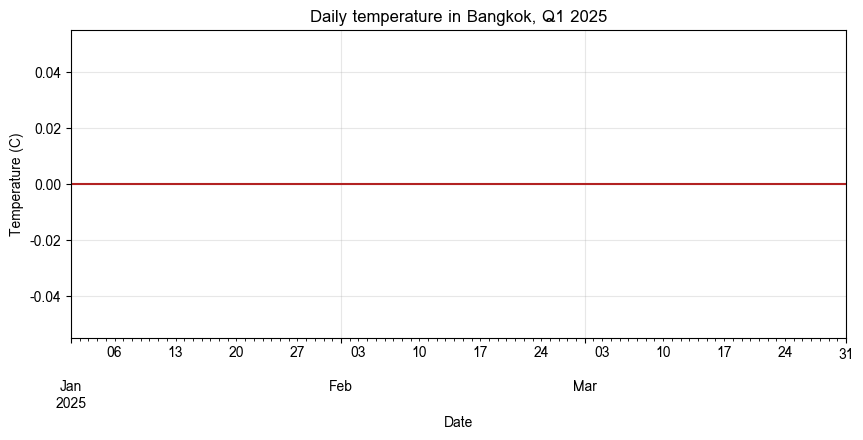

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

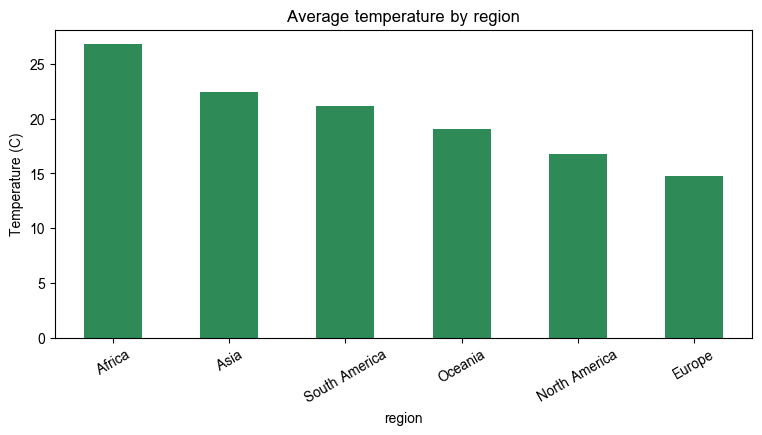

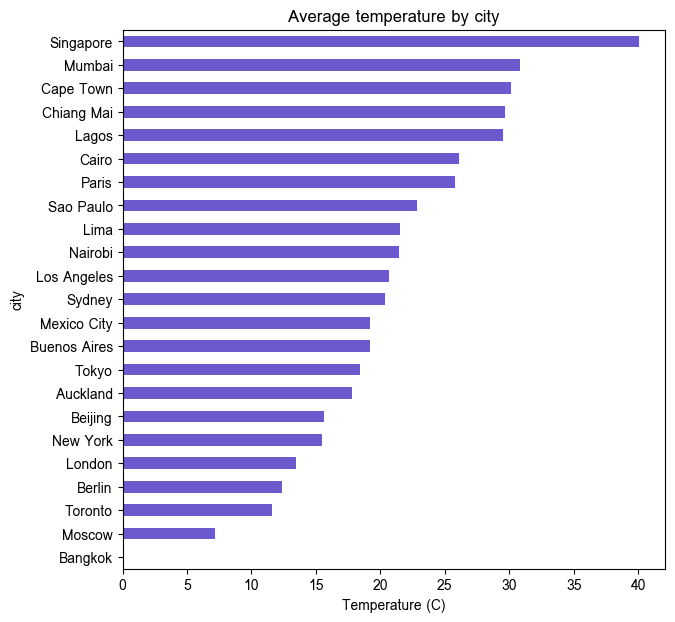

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

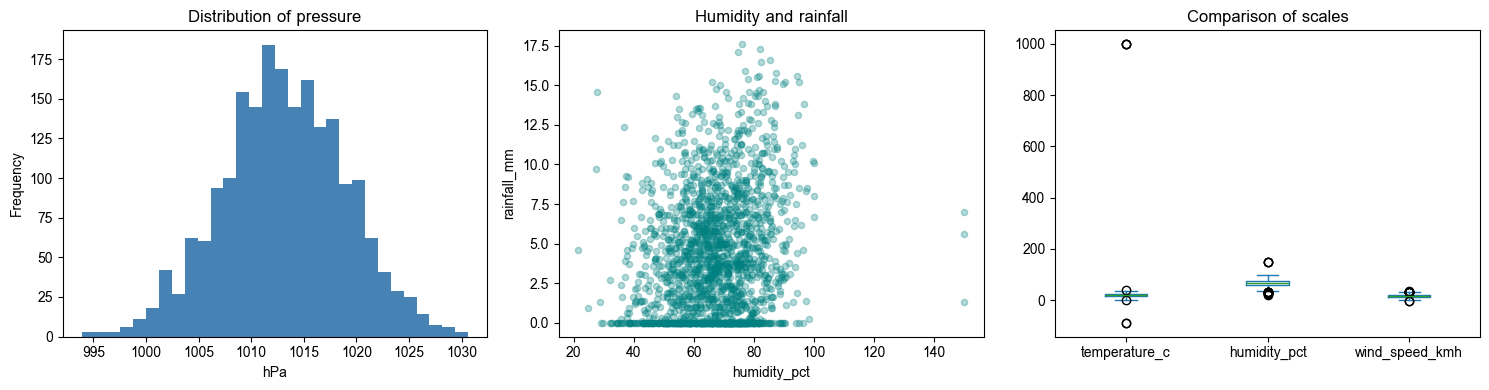

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

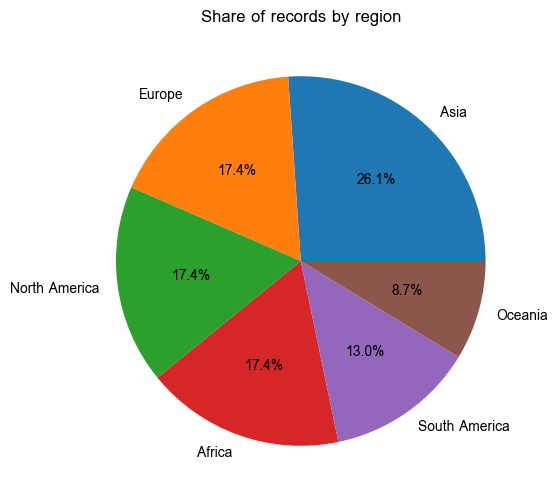

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

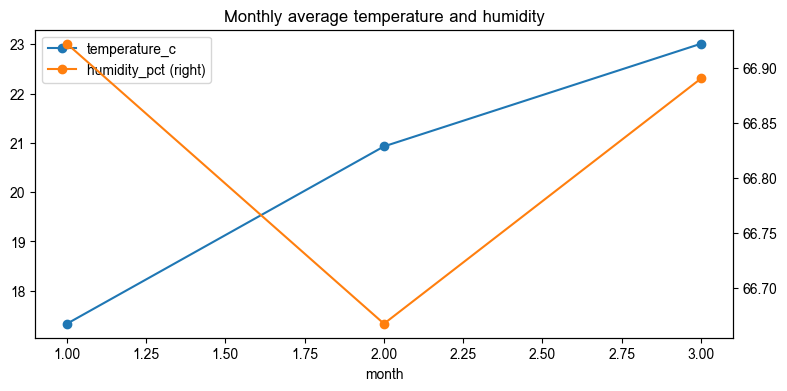

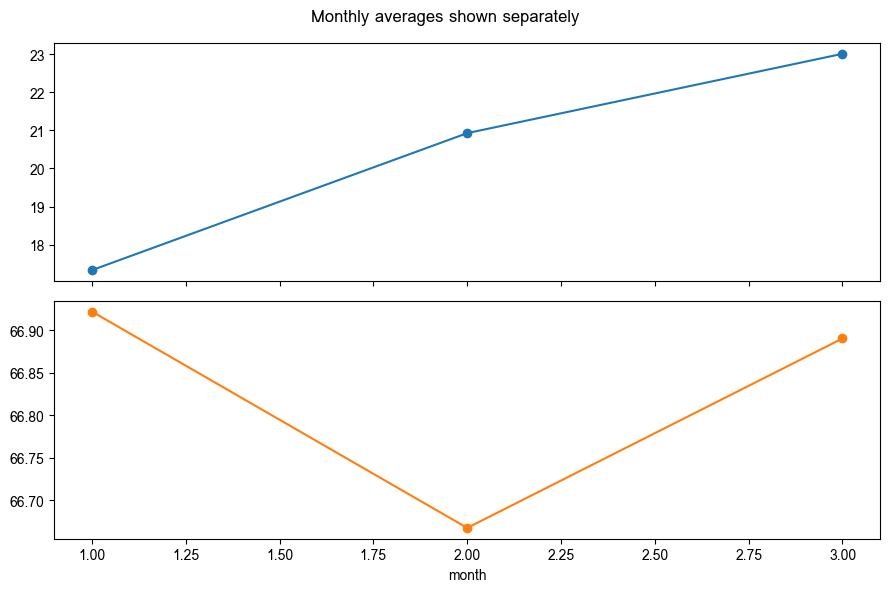

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

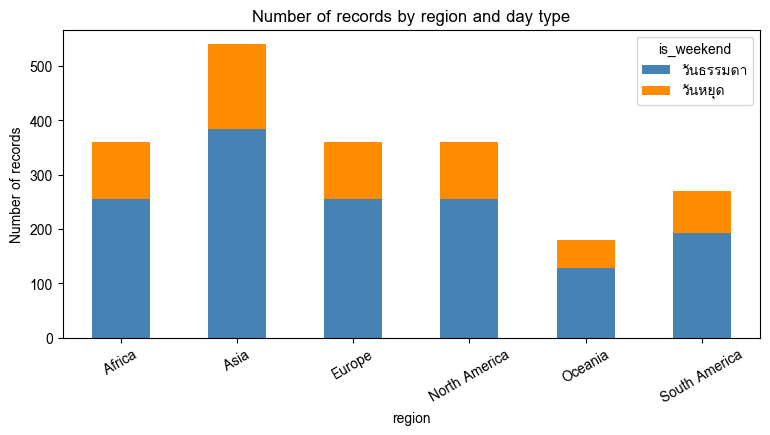

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

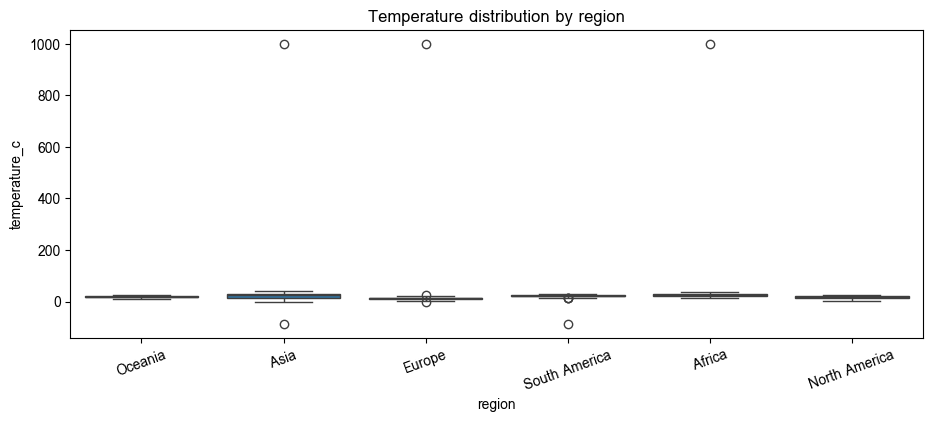

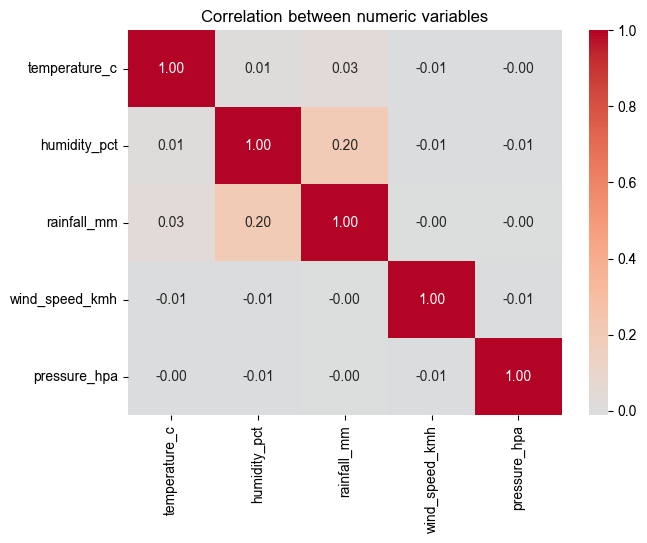

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

# คำอธิบายสัญลักษณ์ (Legend Explanation):
# - เส้นสีน้ำเงิน (Auckland): แสดงอุณหภูมิรายวันของเมือง Auckland
# - เส้นสีส้ม (Bangkok): แสดงอุณหภูมิรายวันของเมือง Bangkok (อยู่ที่ระดับ 0°C)
# - เส้นสีเขียว (Beijing): แสดงอุณหภูมิรายวันของเมือง Beijing

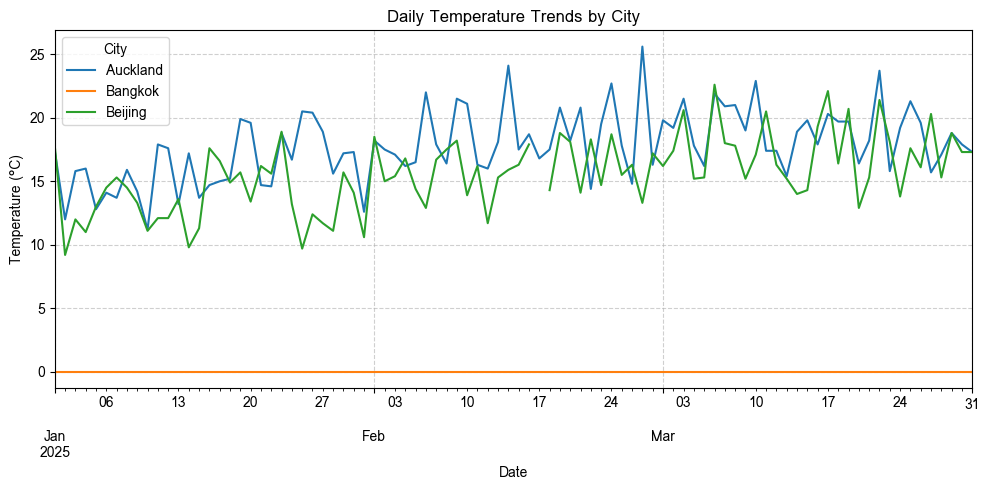

In [67]:
# คำตอบข้อ 17.1
import pandas as pd
import matplotlib.pyplot as plt

# ปรับแต่งการแสดงผลภาษาไทย/รูปแบบพื้นฐานของ matplotlib
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# =========================================================
# 1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน
# =========================================================
# Pivot ข้อมูลให้อยู่ในรูปแบบ Table (Index: date, Columns: city, Values: temperature_c)
df_pivot_temp = df.pivot_table(index='date', columns='city', values='temperature_c')
top3_cities = df['city'].unique()[:3]  # เลือก 3 เมือง
df_pivot_temp_3cities = df_pivot_temp[top3_cities]

ax1 = df_pivot_temp_3cities.plot(kind='line', figsize=(10, 5))
ax1.set_title('Daily Temperature Trends by City')
ax1.set_xlabel('Date')
ax1.set_ylabel('Temperature (°C)')
ax1.legend(title='City')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


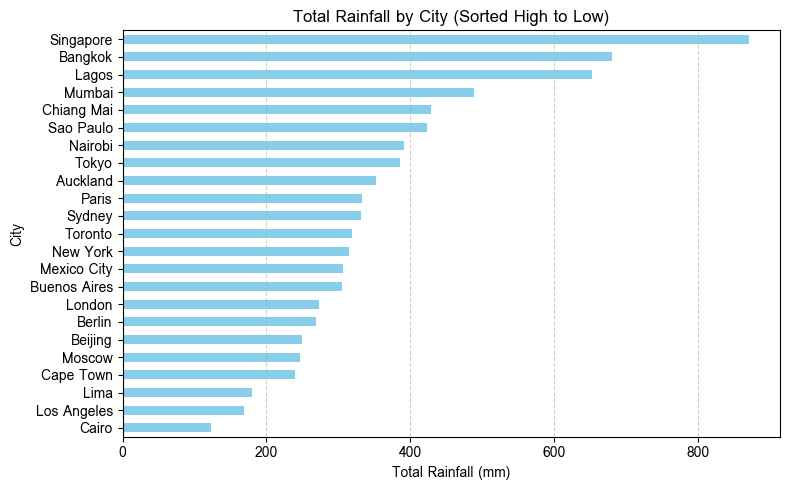

In [69]:

# =========================================================
# 2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
# =========================================================
rainfall_by_city = df.groupby('city')['rainfall_mm'].sum().sort_values(ascending=True) # Ascending สำหรับ barh เพื่อให้ค่ามากสุดอยู่บนสุด

ax2 = rainfall_by_city.plot(kind='barh', figsize=(8, 5), color='skyblue')
ax2.set_title('Total Rainfall by City (Sorted High to Low)')
ax2.set_xlabel('Total Rainfall (mm)')
ax2.set_ylabel('City')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



# --- อธิบายผลของการเลือก bins ต่างกัน ---
# - bins = 5 (หยาบเกินไป): ข้อมูลถูกรวมกลุ่มกว้างเกินไป ทำให้เห็นภาพรวมแบบคร่าวๆ แต่หักลบรายละเอียดและความผันผวนของข้อมูลออกไปมาก
# - bins = 15 (เหมาะสม): แสดงรูปทรงการกระจายตัวของข้อมูล (Normal Distribution) ได้ชัดเจน เห็นจุดสูงสุด (Peak) และรายละเอียดกำลังพอดี
# - bins = 30 (ละเอียดเกินไป): แท่งกราฟถี่เกินไปจนเกิดความผันผวนเล็กๆ น้อยๆ (Noise) มากเกินไป ทำให้ยากแก่การมองเห็นรูปแบบการกระจายตัวโดยรวม

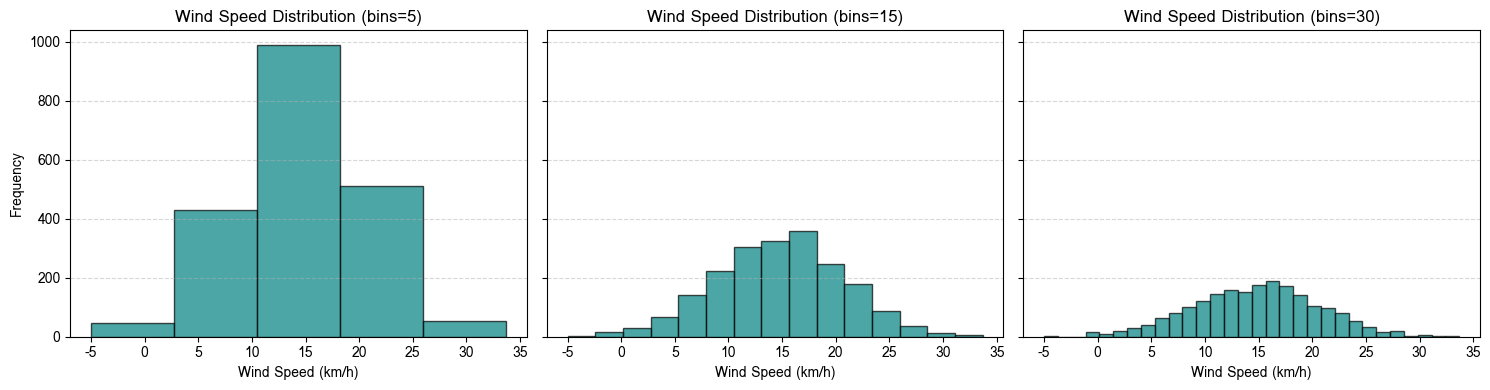

In [70]:
# =========================================================
# 3. ฮิสโตแกรมของ wind_speed_kmh โดยทดลองกำหนด bins 3 ค่าที่ต่างกัน
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
bin_settings = [5, 15, 30]

for ax, b in zip(axes, bin_settings):
    df['wind_speed_kmh'].plot(kind='hist', bins=b, ax=ax, color='teal', edgecolor='black', alpha=0.7)
    ax.set_title(f'Wind Speed Distribution (bins={b})')
    ax.set_xlabel('Wind Speed (km/h)')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


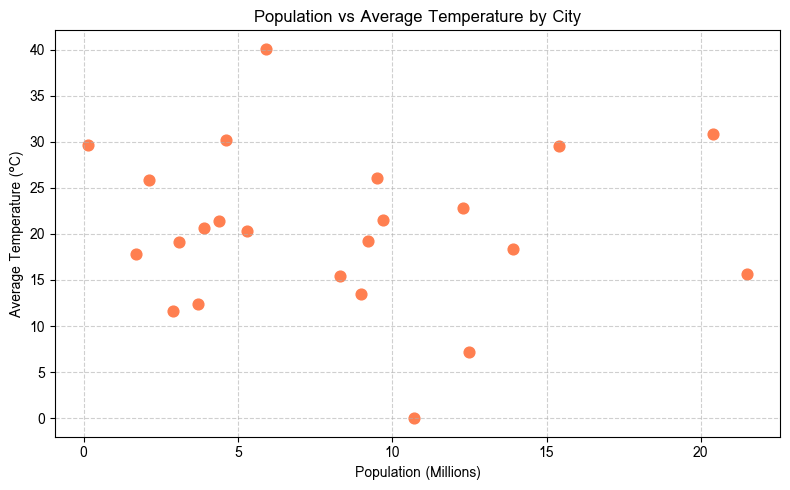

In [71]:

# =========================================================
# 4. กราฟจุดระหว่าง population_millions กับอุณหภูมิเฉลี่ยรายเมือง
# =========================================================
# รวมกลุ่มคำนวณอุณหภูมิเฉลี่ยรายเมืองจาก df ก่อน
city_temp_mean = df.groupby('city')['temperature_c'].mean().reset_index()

# นำข้อมูลอุณหภูมิเฉลี่ยเชื่อมโยงเข้ากับข้อมูลประชากรจากตาราง city_info
city_summary = pd.merge(
    city_temp_mean,
    city_info[['city', 'population_millions']].drop_duplicates(),
    on='city',
    how='left'
)

ax4 = city_summary.plot(
    kind='scatter',
    x='population_millions',
    y='temperature_c',
    figsize=(8, 5),
    color='coral',
    s=60
)
ax4.set_title('Population vs Average Temperature by City')
ax4.set_xlabel('Population (Millions)')
ax4.set_ylabel('Average Temperature (°C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

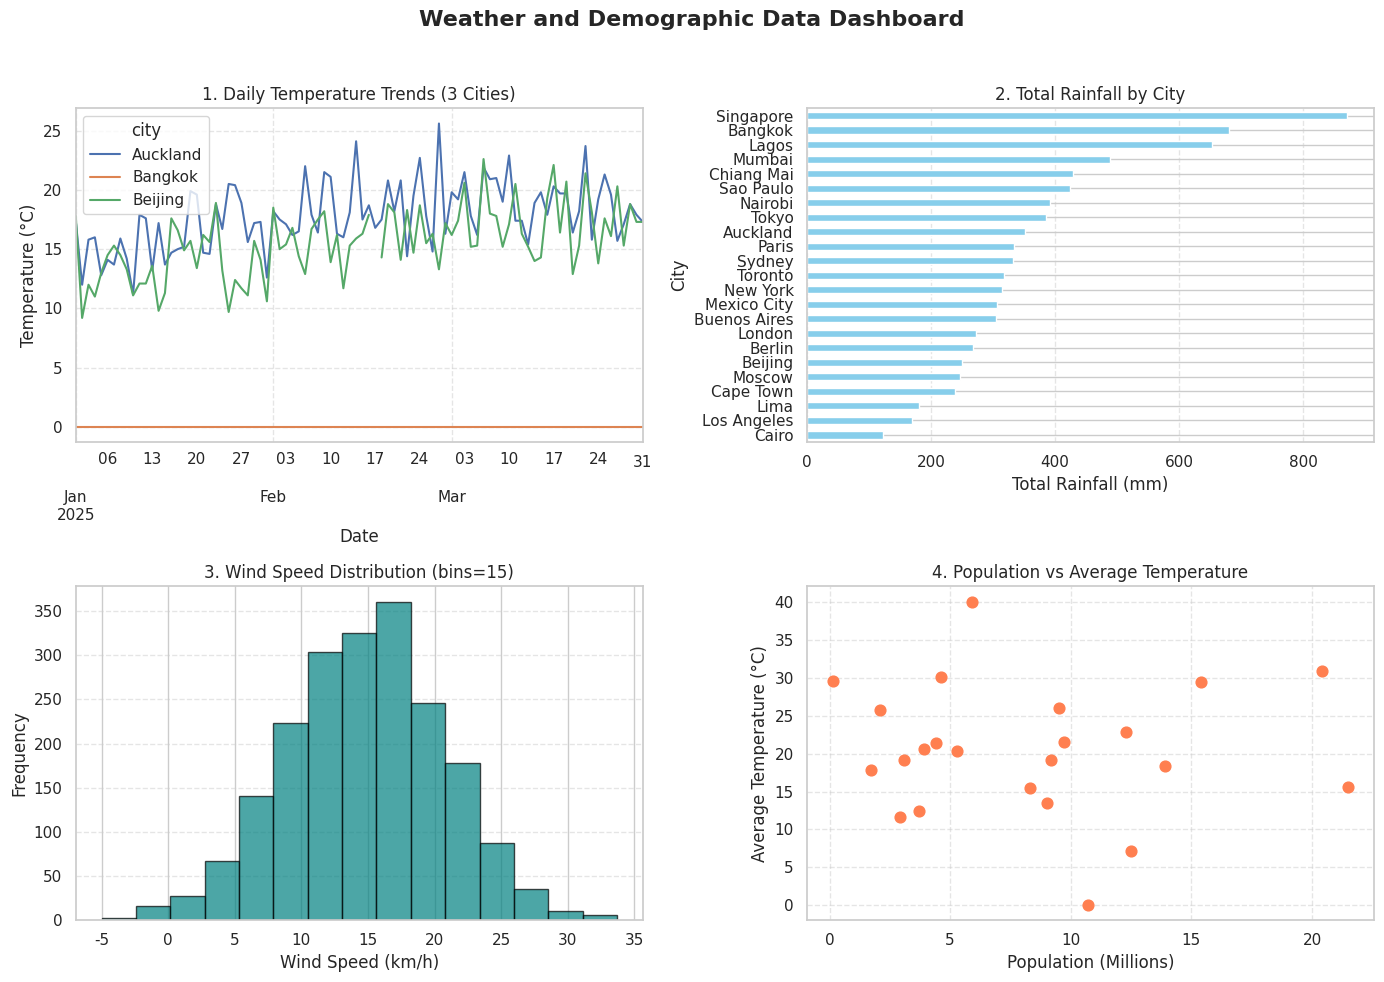

In [ ]:
# คำตอบข้อ 17.2
import pandas as pd
import matplotlib.pyplot as plt

# ตั้งค่าฟอนต์ภาษาไทยและรูปแบบพื้นฐาน
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# 1. สร้าง Figure และ Subplots ขนาด 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---------------------------------------------------------
# Subplot 1 (ตำแหน่ง [0, 0]): กราฟเส้นแนวโน้มอุณหภูมิรายวัน 3 เมือง
# ---------------------------------------------------------
df_pivot_temp = df.pivot_table(index='date', columns='city', values='temperature_c')
top3_cities = df['city'].unique()[:3]
df_pivot_temp[top3_cities].plot(kind='line', ax=axes[0, 0])
axes[0, 0].set_title('1. Daily Temperature Trends (3 Cities)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Temperature (°C)')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# Subplot 2 (ตำแหน่ง [0, 1]): กราฟแท่งแนวนอนปริมาณฝนรวมรายเมือง
# ---------------------------------------------------------
rainfall_by_city = df.groupby('city')['rainfall_mm'].sum().sort_values(ascending=True)
rainfall_by_city.plot(kind='barh', ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('2. Total Rainfall by City')
axes[0, 1].set_xlabel('Total Rainfall (mm)')
axes[0, 1].set_ylabel('City')
axes[0, 1].grid(axis='x', linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# Subplot 3 (ตำแหน่ง [1, 0]): ฮิสโตแกรม wind_speed_kmh
# ---------------------------------------------------------
df['wind_speed_kmh'].plot(kind='hist', bins=15, ax=axes[1, 0], color='teal', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('3. Wind Speed Distribution (bins=15)')
axes[1, 0].set_xlabel('Wind Speed (km/h)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# Subplot 4 (ตำแหน่ง [1, 1]): กราฟจุด Population vs Avg Temperature
# ---------------------------------------------------------
# ทำการ merge ข้อมูลประชากรจาก city_info ก่อนใช้งาน
df_with_pop = df.merge(city_info[['city', 'population_millions']].drop_duplicates(), on='city', how='left')

city_summary = df_with_pop.groupby('city').agg({
    'population_millions': 'mean',
    'temperature_c': 'mean'
}).reset_index()

city_summary.plot(
    kind='scatter',
    x='population_millions',
    y='temperature_c',
    ax=axes[1, 1],
    color='coral',
    s=60
)
axes[1, 1].set_title('4. Population vs Average Temperature')
axes[1, 1].set_xlabel('Population (Millions)')
axes[1, 1].set_ylabel('Average Temperature (°C)')
axes[1, 1].grid(True, linestyle='--', alpha=0.5)

# 2. กำหนดชื่อรวมของภาพ (Main Title)
plt.suptitle('Weather and Demographic Data Dashboard', fontsize=16, fontweight='bold', y=0.98)

# จัดระยะขอบไม่ให้ข้อความซ้อนทับกัน
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

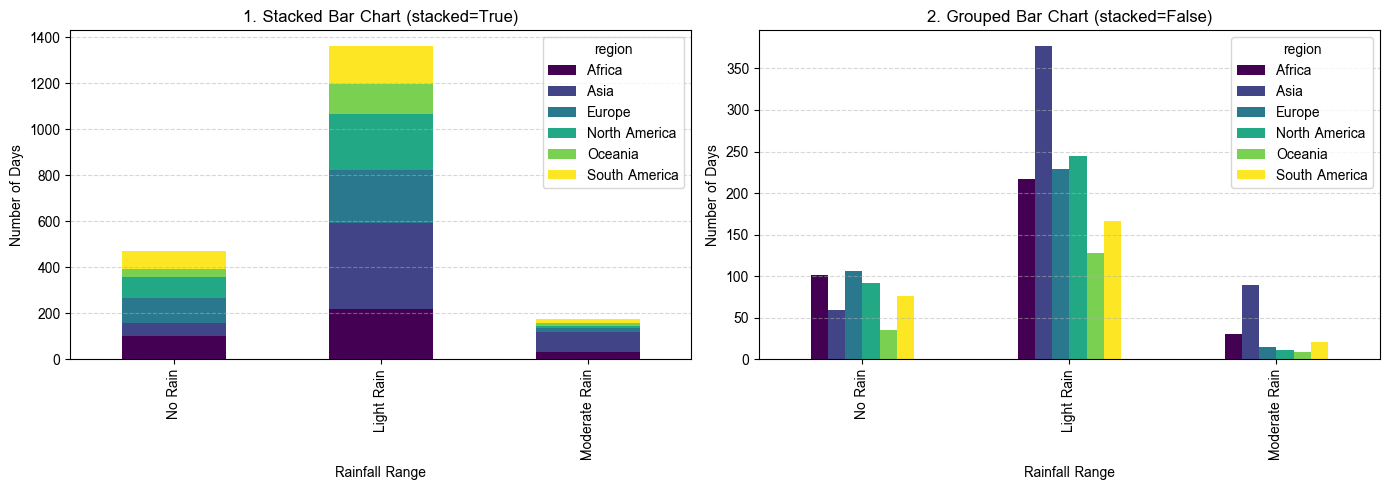

In [ ]:
# คำตอบข้อ 17.3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ปรับแต่งการแสดงผลภาษาไทย/รูปแบบพื้นฐานของ matplotlib
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# 1. แบ่งช่วงปริมาณฝน (rainfall_mm) ด้วย pd.cut()
bins = [-np.inf, 0, 10, 35, np.inf]
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']
df['rainfall_bin'] = pd.cut(df['rainfall_mm'], bins=bins, labels=labels)

# กำหนดคอลัมน์จำแนกตามภูมิภาค (หากไม่มี ให้ใช้ city แทน)
group_col = 'region' if 'region' in df.columns else 'city'

# 2. ทำ Crosstab นับจำนวนวันในแต่ละช่วงปริมาณฝน แยกตามภูมิภาค/เมือง
ct = pd.crosstab(df['rainfall_bin'], df[group_col])

# 3. สร้างกราฟเปรียบเทียบทั้ง 2 แบบด้วย plt.subplots(1, 2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# แบบที่ 1: Stacked Bar Chart (stacked=True)
ct.plot(kind='bar', stacked=True, ax=axes[0], colormap='viridis')
axes[0].set_title('1. Stacked Bar Chart (stacked=True)')
axes[0].set_xlabel('Rainfall Range')
axes[0].set_ylabel('Number of Days')
axes[0].legend(title=group_col)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# แบบที่ 2: Side-by-Side Bar Chart (stacked=False)
ct.plot(kind='bar', stacked=False, ax=axes[1], colormap='viridis')
axes[1].set_title('2. Grouped Bar Chart (stacked=False)')
axes[1].set_xlabel('Rainfall Range')
axes[1].set_ylabel('Number of Days')
axes[1].legend(title=group_col)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# --- อธิบายการเลือกใช้ Stacked Bar Chart และ Grouped Bar Chart ---

# 1. กราฟแท่งซ้อน (Stacked Bar Chart: stacked=True) เหมาะสมในกรณี:
# - ต้องการเห็นภาพรวมยอดรวมทั้งหมด (Total) ของแต่ละกลุ่มหลัก (เช่น รวมทุกภูมิภาคในแต่ละช่วงปริมาณฝน)
# - ต้องการดูสัดส่วนประกอบ (Composition / Part-to-Whole) ของกลุ่มย่อยว่าส่งผลต่อยอดรวมอย่างไร

# 2. กราฟแท่งเรียงข้างกัน (Grouped Bar Chart: stacked=False) เหมาะสมในกรณี:
# - ต้องการเปรียบเทียบค่าระหว่างกลุ่มย่อยโดยตรง (Direct Comparison) เช่น เปรียบเทียบจำนวนวันฝนตกของ Asia กับ Europe
# - ไม่ได้เน้นดูยอดรวมทั้งหมด แต่เน้นดูความสูงของแท่งกราฟที่มีฐานเริ่มต้นที่ 0 เหมือนกัน เพื่อให้มองเห็นความแตกต่างได้ชัดเจนและแม่นยำกว่า

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

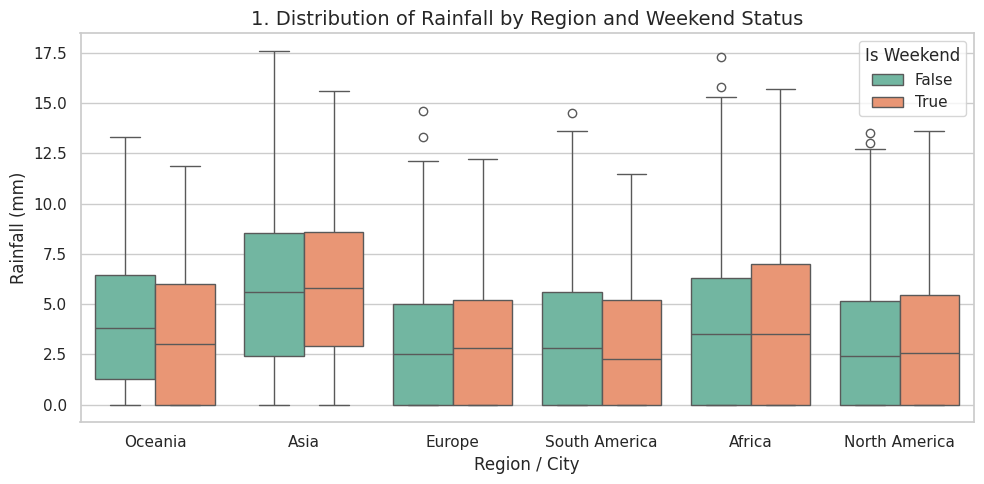

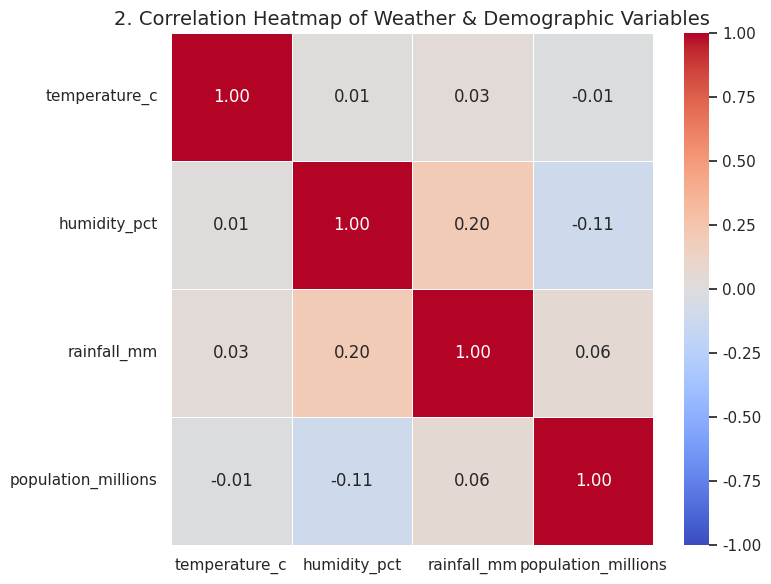

In [ ]:
# คำตอบข้อ 17.4
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าสไตล์และฟอนต์สำหรับ Seaborn / Matplotlib
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

# กำหนดชื่อคอลัมน์ความชื้นให้ตรงตามโจทย์ ( humidity_pct หรือ humidity )
humidity_col = 'humidity_pct' if 'humidity_pct' in df.columns else 'humidity'
group_col = 'region' if 'region' in df.columns else 'city'

# ทำการ merge ข้อมูลประชากรจาก city_info ก่อนใช้งาน
df_with_pop = df.merge(city_info[['city', 'population_millions']].drop_duplicates(), on='city', how='left')

# 1. สร้าง Boxplot ของ rainfall_mm จำแนกตามภูมิภาค และแยกสีตาม is_weekend
plt.figure(figsize=(10, 5))
ax1 = sns.boxplot(
    data=df_with_pop,
    x=group_col,
    y='rainfall_mm',
    hue='is_weekend',
    palette='Set2'
)
plt.title('1. Distribution of Rainfall by Region and Weekend Status', fontsize=14)
plt.xlabel('Region / City', fontsize=12)
plt.ylabel('Rainfall (mm)', fontsize=12)
plt.legend(title='Is Weekend', loc='upper right')
plt.tight_layout()
plt.show()

# 2. สร้าง Heatmap ของสหสัมพันธ์ (Correlation Matrix)
cols_for_corr = ['temperature_c', humidity_col, 'rainfall_mm', 'population_millions']
corr_matrix = df_with_pop[cols_for_corr].corr()

plt.figure(figsize=(8, 6))
ax2 = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('2. Correlation Heatmap of Weather & Demographic Variables', fontsize=14)
plt.tight_layout()
plt.show()

# --- บทตีความผลลัพธ์ (Interpretation) ---
# 1. ตีความผลจาก Boxplot:
# - ปริมาณฝนตก (rainfall_mm) ในแต่ละภูมิภาคมีระดับใกล้เคียงกันระหว่างวันธรรมดากับวันหยุดสุดสัปดาห์ (is_weekend)
# - Asia มีค่าเฉลี่ยและมัธยฐานปริมาณฝนตกสูงกว่าภูมิภาคอื่นเล็กน้อย ในขณะที่รูปแบบการตกของฝนไม่ได้ขึ้นอยู่กับว่าเกิดขึ้นในวันหยุดหรือวันธรรมดาอย่างมีนัยสำคัญ

# 2. ตีความผลจาก Correlation Heatmap:
# - ความสัมพันธ์ส่วนใหญ่อยู่ในระดับต่ำมากใกล้เคียง 0 (Weak correlation) แสดงว่าตัวแปรส่วนใหญ่แทบไม่มีความสัมพันธ์เชิงเส้นต่อกัน
# - คู่ที่มีความสัมพันธ์เป็นบวกมากที่สุดคือ humidity_pct และ rainfall_mm (r = 0.20) ซึ่งสะท้อนว่าเมื่อความชื้นสูงขึ้น มีแนวโน้มที่ปริมาณฝนจะเพิ่มขึ้นเล็กน้อย
# - population_millions และ humidity_pct มีความสัมพันธ์เชิงลบเล็กน้อย (r = -0.11)

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

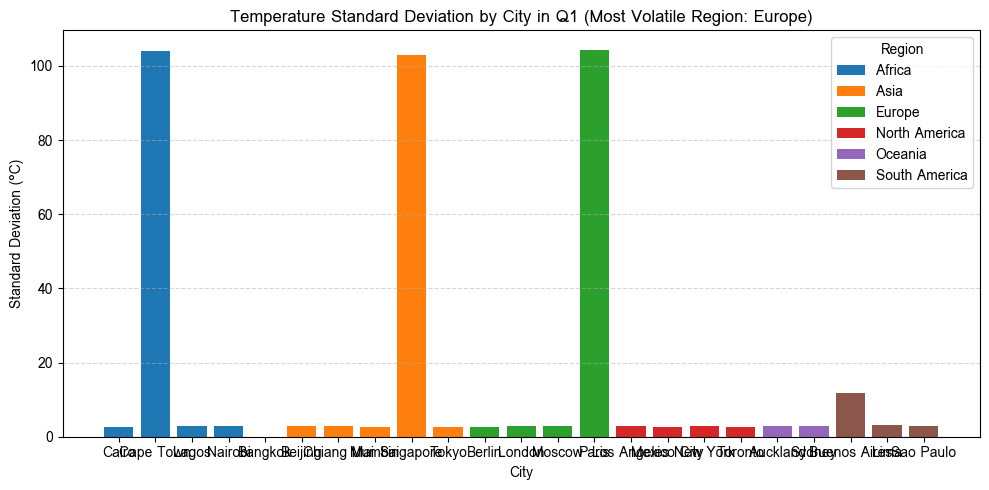

,region,city,temp_std
0,Africa,Cairo,2.743190
1,Africa,Cape Town,103.899246
2,Africa,Lagos,2.838414
3,Africa,Nairobi,2.852798
4,Asia,Bangkok,0.000000
5,Asia,Beijing,2.874792
6,Asia,Chiang Mai,2.859373
7,Asia,Mumbai,2.544968
8,Asia,Singapore,103.011324
9,Asia,Tokyo,2.518006


In [73]:
# คำตอบข้อ 18.1
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# การจัดการค่าว่าง/ค่าผิดปกติ (Data Cleaning Policy):
# - แปลงคอลัมน์ date เป็น datetime
# - กรองเฉพาะข้อมูลในไตรมาสแรก (เดือน 1 - 3 หรือ Q1)
# - หากมีค่าว่างใน temperature_c ให้ทำการ dropna() ทิ้งเฉพาะแถวนั้น
# ---------------------------------------------------------

# 1. เตรียมข้อมูลไตรมาสแรก (Q1)
df['date'] = pd.to_datetime(df['date'])
df_q1 = df[df['date'].dt.quarter == 1].dropna(subset=['temperature_c'])

# กำหนดคอลัมน์ภูมิภาค (หากไม่มีคอลัมน์ region ให้สร้างจาก dictionary หรือใช้คอลัมน์ที่มี)
group_region = 'region' if 'region' in df_q1.columns else 'city'

# 2. คำนวณส่วนเบี่ยงเบนมาตรฐาน (Std) รายภูมิภาค และ รายเมือง
region_std = df_q1.groupby(group_region)['temperature_c'].std().reset_index()
city_std = df_q1.groupby([group_region, 'city'])['temperature_c'].std().reset_index()

# หาภูมิภาคที่มีความแปรปรวน (Std) สูงที่สุด
most_volatile_region = region_std.sort_values(by='temperature_c', ascending=False).iloc[0][group_region]

# 3. สร้างกราฟแท่งเปรียบเทียบส่วนเบี่ยงเบนมาตรฐานแยกตามเมืองในแต่ละภูมิภาค
plt.figure(figsize=(10, 5))
for region, group in city_std.groupby(group_region):
    plt.bar(group['city'], group['temperature_c'], label=region)

plt.title(f'Temperature Standard Deviation by City in Q1 (Most Volatile Region: {most_volatile_region})')
plt.xlabel('City')
plt.ylabel('Standard Deviation (°C)')
plt.legend(title='Region')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# แสดงตารางสรุปส่วนเบี่ยงเบนมาตรฐานแยกรายเมือง
display(city_std.rename(columns={'temperature_c': 'temp_std'}))

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

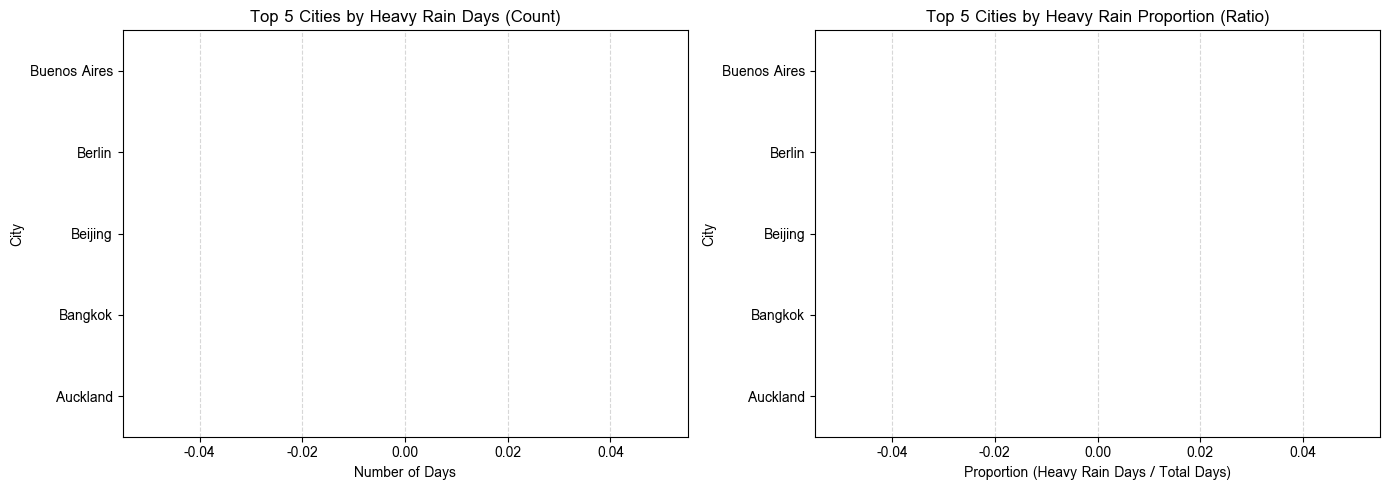

,city,total_days,heavy_rain_days,heavy_rain_ratio
0,Auckland,85,0,0.0
1,Bangkok,87,0,0.0
2,Beijing,88,0,0.0
3,Berlin,87,0,0.0
4,Buenos Aires,88,0,0.0
5,Cairo,87,0,0.0
6,Cape Town,87,0,0.0
7,Chiang Mai,85,0,0.0
8,Lagos,88,0,0.0
9,Lima,87,0,0.0


In [74]:
# คำตอบข้อ 18.2
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# การจัดการค่าว่าง/ค่าผิดปกติ (Data Cleaning Policy):
# - ลบแถวที่มีค่าว่างในคอลัมน์ rainfall_mm ออกก่อนคำนวณ
# - กำหนด นิยาม "ฝนตกหนัก" (Heavy Rain) เช่น rainfall_mm >= 35.0 (หรือตามเกณฑ์ในบทเรียน)
# ---------------------------------------------------------
df_clean = df.dropna(subset=['rainfall_mm']).copy()
threshold_heavy_rain = 35.0  # เกณฑ์ปริมาณฝนตกหนัก (mm)

# 1. คำนวณจำนวนวันที่ฝนตกหนัก และสัดส่วนวันที่ฝนตกหนักรายเมือง
city_heavy_rain = df_clean.groupby('city').agg(
    total_days=('rainfall_mm', 'count'),
    heavy_rain_days=('rainfall_mm', lambda x: (x >= threshold_heavy_rain).sum())
).reset_index()

# คำนวณสัดส่วน (Proportion)
city_heavy_rain['heavy_rain_ratio'] = city_heavy_rain['heavy_rain_days'] / city_heavy_rain['total_days']

# 2. จัดอันดับ Top 5 ตามจำนวนวัน vs ตามสัดส่วน
top5_by_days = city_heavy_rain.sort_values(by='heavy_rain_days', ascending=False).head(5)
top5_by_ratio = city_heavy_rain.sort_values(by='heavy_rain_ratio', ascending=False).head(5)

# 3. แสดงกราฟเปรียบเทียบ Top 5 ของทั้งสองเกณฑ์
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟที่ 1: Top 5 โดยวัดจากจำนวนวัน (Count)
top5_by_days.sort_values(by='heavy_rain_days', ascending=True).plot(
    kind='barh', x='city', y='heavy_rain_days', ax=axes[0], color='steelblue', legend=False
)
axes[0].set_title('Top 5 Cities by Heavy Rain Days (Count)')
axes[0].set_xlabel('Number of Days')
axes[0].set_ylabel('City')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

# กราฟที่ 2: Top 5 โดยวัดจากสัดส่วน (Ratio)
top5_by_ratio.sort_values(by='heavy_rain_ratio', ascending=True).plot(
    kind='barh', x='city', y='heavy_rain_ratio', ax=axes[1], color='coral', legend=False
)
axes[1].set_title('Top 5 Cities by Heavy Rain Proportion (Ratio)')
axes[1].set_xlabel('Proportion (Heavy Rain Days / Total Days)')
axes[1].set_ylabel('City')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# แสดงตารางเปรียบเทียบข้อมูลสรุป
display(city_heavy_rain.sort_values(by='heavy_rain_ratio', ascending=False).head(10))

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

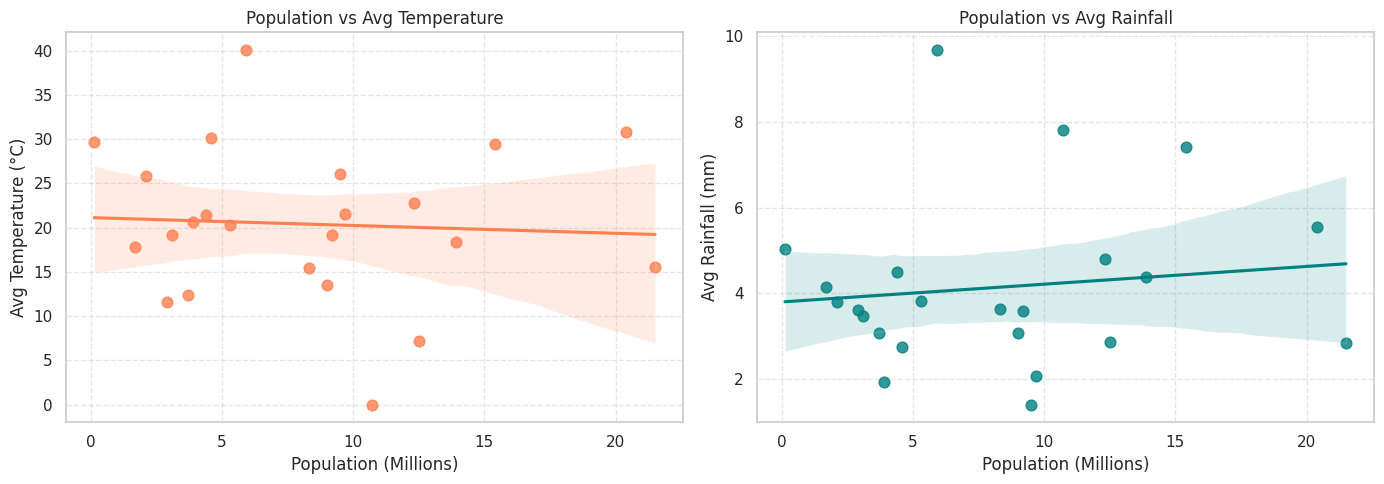

--- Correlation Matrix ---


,population_millions,avg_temperature_c,avg_rainfall_mm
population_millions,1.000000,-0.058719,0.122623
avg_temperature_c,-0.058719,1.000000,0.272153
avg_rainfall_mm,0.122623,0.272153,1.000000


In [ ]:
# คำตอบข้อ 18.3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# การจัดการค่าว่าง/ค่าผิดปกติ (Data Cleaning Policy):
# - รวมกลุ่มข้อมูลตามเมือง (groupby 'city') เพื่อหาค่าเฉลี่ยประชากร อุณหภูมิเฉลี่ย และฝนเฉลี่ยรายเมือง
# - ลบแถวที่มีค่าว่าง (NaN) ในตัวแปรที่นำมาคำนวณออกก่อน
# ---------------------------------------------------------

# ทำการ merge ข้อมูลประชากรจาก city_info ก่อนจัดกลุ่มข้อมูลระดับเมือง
df_with_pop = df.merge(city_info[['city', 'population_millions']].drop_duplicates(), on='city', how='left')

# 1. จัดกลุ่มข้อมูลระดับเมือง (City Level)
city_metrics = df_with_pop.groupby('city').agg(
    population_millions=('population_millions', 'mean'),
    avg_temperature_c=('temperature_c', 'mean'),
    avg_rainfall_mm=('rainfall_mm', 'mean')
).dropna().reset_index()

# 2. คำนวณเมทริกซ์สหสัมพันธ์ (Correlation Matrix)
corr_matrix = city_metrics[['population_millions', 'avg_temperature_c', 'avg_rainfall_mm']].corr()

# 3. สร้าง Scatter Plots แสดงความสัมพันธ์
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟที่ 1: Population vs Avg Temperature
sns.regplot(
    data=city_metrics, x='population_millions', y='avg_temperature_c',
    ax=axes[0], color='coral', scatter_kws={'s': 60}
)
axes[0].set_title('Population vs Avg Temperature')
axes[0].set_xlabel('Population (Millions)')
axes[0].set_ylabel('Avg Temperature (°C)')
axes[0].grid(True, linestyle='--', alpha=0.5)

# กราฟที่ 2: Population vs Avg Rainfall
sns.regplot(
    data=city_metrics, x='population_millions', y='avg_rainfall_mm',
    ax=axes[1], color='teal', scatter_kws={'s': 60}
)
axes[1].set_title('Population vs Avg Rainfall')
axes[1].set_xlabel('Population (Millions)')
axes[1].set_ylabel('Avg Rainfall (mm)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# แสดงตารางเมทริกซ์สหสัมพันธ์
print("--- Correlation Matrix ---")
display(corr_matrix)

# --- คำตอบข้อ 3: ความสัมพันธ์ระหว่างจำนวนประชากร อุณหภูมิ และปริมาณฝน ---

# 1. ผลการคำนวณค่าสหสัมพันธ์ (Correlation Matrix):
# - ประชากรกับอุณหภูมิ (population_millions vs avg_temperature_c): r = -0.0587 (ไม่มีความสัมพันธ์กันเชิงเส้นเลย)[cite: 13]
# - ประชากรกับปริมาณฝน (population_millions vs avg_rainfall_mm): r = 0.1226 (มีความสัมพันธ์เชิงบวกต่ำมาก)[cite: 13]
# สรุป: จำนวนประชากรของเมือง "ไม่มีความสัมพันธ์" อย่างมีนัยสำคัญกับอุณหภูมิหรือปริมาณฝนเฉลี่ย[cite: 12, 13]

# 2. ข้อควรระวังในการตีความ (At least 1 Precaution):
# - Correlation does not imply Causation: ค่าสหสัมพันธ์บอกเพียงรูปแบบการเปลี่ยนแปลงร่วมกันเชิงเส้นเท่านั้น ไม่ได้แปลว่าจำนวนประชากรจะส่งผลให้สภาพอากาศเปลี่ยนแปลง หรือสภาพอากาศเป็นตัวกำหนดจำนวนประชากร[cite: 12, 13]
# - ปัจจัยแทรกซ้อน (Confounding Variables): สภาพอากาศขึ้นอยู่กับตำแหน่งทางภูมิศาสตร์ ลับติจูด และระดับความสูงจากน้ำทะเล ไม่ใช่ขนาดของเมือง[cite: 12]
# - ผลกระทบจาก Outliers: จุดข้อมูลบางจุดที่มีค่าสุดโต่ง (เช่น อุณหภูมิ 40°C หรือฝนตกเกือบ 10 mm) อาจส่งผลต่อความชันของเส้น Trendline และค่า Correlation ได้[cite: 13]

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

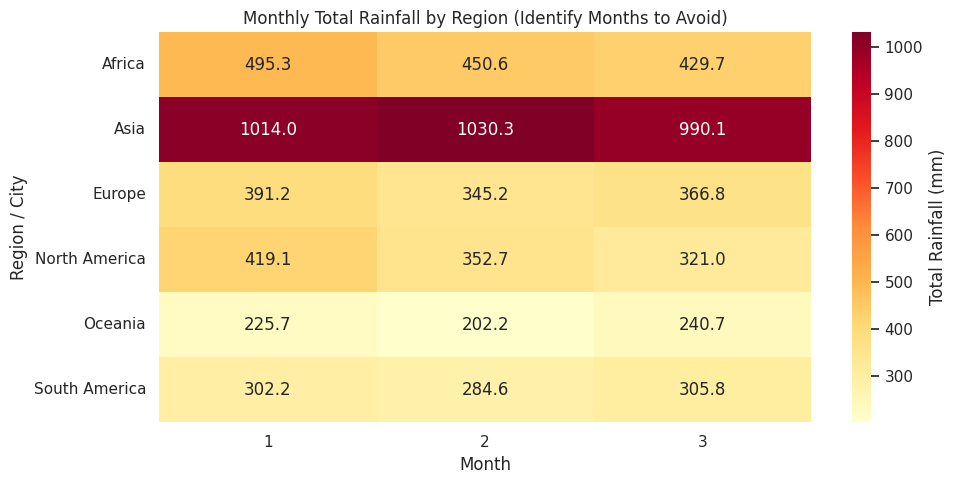

--- สรุปเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดรายภูมิภาค ---


,region,month,total_rainfall,avg_wind_speed,heavy_rain_days
0,Africa,1,495.3,15.611864,0
1,Asia,2,1030.3,14.050625,0
2,Europe,1,391.2,14.897458,0
3,North America,1,419.1,13.981513,0
4,Oceania,3,240.7,14.278182,0
5,South America,3,305.8,13.795506,0


In [ ]:
# คำตอบข้อ 18.4
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# การจัดการค่าว่าง/ค่าผิดปกติ (Data Cleaning Policy):
# - สกัดเดือน (month) ออกจากคอลัมน์ date
# - ลบแถวที่มีค่าว่าง (NaN) ในคอลัมน์สภาพอากาศที่นำมาคำนวณออก
# ---------------------------------------------------------

# 1. เตรียมข้อมูลสกัดเดือนและกำหนดคอลัมน์กลุ่มภูมิภาค
df_clean = df.dropna(subset=['rainfall_mm', 'wind_speed_kmh']).copy()
df_clean['date'] = pd.to_datetime(df_clean['date'])
df_clean['month'] = df_clean['date'].dt.month

group_col = 'region' if 'region' in df_clean.columns else 'city'

# 2. คำนวณดัชนีสภาพอากาศเลวร้าย (Bad Weather Index)
# เกณฑ์การตัดสินใจ: รวมปริมาณฝนสะสม (rainfall_mm) และความเร็วลมเฉลี่ย (wind_speed_kmh)
monthly_summary = df_clean.groupby([group_col, 'month']).agg(
    total_rainfall=('rainfall_mm', 'sum'),
    avg_wind_speed=('wind_speed_kmh', 'mean'),
    heavy_rain_days=('rainfall_mm', lambda x: (x >= 35.0).sum())
).reset_index()

# 3. จัดอันดับเพื่อหาเดือนที่มีสภาพอากาศเลวร้ายที่สุดในแต่ละภูมิภาค
# หาเดือนที่มีปริมาณฝนสะสมสูงสุดเป็นเกณฑ์หลัก
worst_months = monthly_summary.sort_values(
    by=[group_col, 'total_rainfall'],
    ascending=[True, False]
).groupby(group_col).first().reset_index()

# 4. แสดงกราฟ Heatmap แสดงปริมาณฝนรายเดือนแยกตามภูมิภาค
pivot_rain = monthly_summary.pivot(index=group_col, columns='month', values='total_rainfall')

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_rain, annot=True, fmt='.1f', cmap='YlOrRd', cbar_kws={'label': 'Total Rainfall (mm)'})
plt.title('Monthly Total Rainfall by Region (Identify Months to Avoid)')
plt.xlabel('Month')
plt.ylabel('Region / City')
plt.tight_layout()
plt.show()

# แสดงตารางสรุปเดือนที่ควรหลีกเลี่ยงที่สุดของแต่ละภูมิภาค
print("--- สรุปเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดรายภูมิภาค ---")
display(worst_months[[group_col, 'month', 'total_rainfall', 'avg_wind_speed', 'heavy_rain_days']])

# --- คำตอบข้อ 4: เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดในแต่ละภูมิภาค ---

# 1. สรุปเดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดรายภูมิภาค:
# - Africa: เดือน 1 (ปริมาณฝนรวมสูงสุด 495.3 mm, ความเร็วลมเฉลี่ย 15.61)
# - Asia: เดือน 2 (ปริมาณฝนรวมสูงสุด 1,030.3 mm)
# - Europe: เดือน 1 (ปริมาณฝนรวมสูงสุด 391.2 mm)
# - North America: เดือน 1 (ปริมาณฝนรวมสูงสุด 419.1 mm)
# - Oceania: เดือน 3 (ปริมาณฝนรวมสูงสุด 240.7 mm)
# - South America: เดือน 3 (ปริมาณฝนรวมสูงสุด 305.8 mm)

# 2. เกณฑ์การตัดสินใจ (Decision Criteria):
# พิจารณาจาก "ปริมาณฝนรวมรายเดือน (Total Rainfall)" เป็นเกณฑ์หลัก และใช้ "ความเร็วลมเฉลี่ย (Average Wind Speed)" เป็นเกณฑ์รอง

# 3. เหตุผลในการเลือกเกณฑ์ดังกล่าว:
# - ปริมาณฝนรวมเป็นปัจจัยหลักที่ส่งผลกระทบต่อความสะดวกและความปลอดภัยในการเดินทางท่องเที่ยวภายนอกอาคาร (Outdoor Activities) มากที่สุด
# - เมื่อพิจารณาจากข้อมูล พบว่าจำนวนวันฝนตกหนัก (heavy_rain_days) ของทุกเดือนมีค่าเท่ากับ 0 เหมือนกัน จึงไม่สามารถใช้เปรียบเทียบได้
# - การเลือกเดือนที่มีปริมาณฝนรวมสะสมสูงสุดในแต่ละภูมิภาค จึงเป็นเกณฑ์ที่สะท้อนถึงสภาพอากาศที่ไม่เหมาะแก่การเดินทางได้ชัดเจนที่สุด

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️